# M04 - Scar Analysis

This notebook is organized around two major blocks after anatomical assignment:

1. **Analysis**: build the analysis tables and test whether scar descriptors relate meaningfully to clinical or anatomical questions, such as age associations, sex differences, AHA/territory non-uniformity, and method agreement.
2. **Characterization**: describe the scar phenotype itself, including population atlases, spatial variability, archetypes, PCA pattern maps, area-weighted descriptors, transmurality, onset, elongation, and fragment morphology.

The geometric projection logic stays centralized in `src/lv_geometry.py`. The reusable descriptor code lives in `src/scar_characterization.py`, while inferential/statistical helpers live in `src/scar_analysis.py`.


## 0 - Test Reference

The main inferential choices are deliberately non-parametric or permutation/bootstrap based because scar burden is bounded between 0 and 1, sparse, zero-inflated, and often non-normal. The table below states both what each test is used for and why it is appropriate here.

| Step | Analysis | Test / method | Why this test | Output |
|---|---|---|---|---|
| 5 | Normality diagnostics | Shapiro-Wilk, QQ plots, chi-square QQ of Mahalanobis distances | Checks whether parametric assumptions are plausible before relying on t-tests/Pearson-style summaries. | Normality tables and diagnostic plots |
| 5 | AHA-17 segment differences | Friedman test | Each patient contributes paired values across 17 segments; Friedman is the non-parametric repeated-measures alternative to ANOVA. | Spatial non-uniformity across AHA segments |
| 5 | Pairwise AHA segment differences | Wilcoxon signed-rank + Bonferroni | Segment pairs are paired within patient; Bonferroni controls the large family of pairwise tests. | Post-hoc segment comparisons |
| 5 | LAD/RCA/LCX territory differences | Friedman test | Territory burdens are paired within the same patient and not assumed normal. | Territory-level spatial preference |
| 5 | Age associations | Spearman correlation | Age is continuous and scar burden is non-normal; Spearman tests monotonic association without requiring linear-normal residuals. | Age-scar association tables/plots |
| 5 | Sex comparisons | Mann-Whitney / permutation-style summaries where used | Sex groups are small and imbalanced, especially female labels, so rank/permutation evidence is safer than normal-theory tests. | Sex-difference summaries |
| 4 / 7 | Population uncertainty | Patient-level bootstrap CI | Resamples patients to estimate uncertainty around cohort means without assuming a Gaussian scar distribution. | 95% confidence intervals |
| 6 / 7 | PCA | Standardized PCA | Descriptive dimensionality reduction of the 17-segment scar vector; not used as a hypothesis test by itself. | Spatial pattern scores/loadings |
| 9 | Transmurality summaries | Descriptive ring/territory summaries and Spearman age correlations | Transmurality asks anatomical depth/location questions; age links remain non-parametric. | Onset, elongation, depth maps |


## Section 1 - Load Data, Clinical Labels, and Polar Representations


### 1.1 Setup and Shared Plot Style


In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import (
    ttest_ind, spearmanr, pearsonr, f_oneway, friedmanchisquare, levene,
    mannwhitneyu, probplot, shapiro, chi2, kruskal, wilcoxon, f as f_dist,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / 'lv-scar-segmentation'):
            if (candidate / 'src' / 'data_loading.py').exists():
                return candidate.resolve()
    raise FileNotFoundError('Could not locate lv-scar-segmentation.')


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for mod in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[mod]

from src.data_loading import scan
from src.mesh_utils import best_shell, get_cz_mesh, best_rv_mesh
from src.lv_geometry import (
    long_axis,
    rv_reference_pca,
    rv_reference_from_rv_mesh,
    prepare_polar_geometry,
    project_points_to_polar,
    polar_mask,
)
from src import scar_characterization as scar_char
from src import scar_analysis

HD_ROOT      = r'F:/RM_TEKNON_DEVELOP'
CLINICAL_CSV = Path(r'C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv')
RESULTS      = ROOT / 'results'
SPLIT_JSON   = RESULTS / 'split.json'
OUT          = RESULTS / 'M04_scar_analysis'
OUT.mkdir(parents=True, exist_ok=True)

N_R     = 64
N_THETA = 128

AHA_DISPLAY_DEG = 0.0    # no roll: septal/RV vector stays at West (9 o'clock)

RING_ZONES = {
    'Apex':   (0.00, 0.25),
    'Apical': (0.25, 0.50),
    'Mid':    (0.50, 0.75),
    'Basal':  (0.75, 1.00),
}
TERRITORY = ['LAD', 'RCA', 'LCX']

# Threshold: fraction of a coronary territory occupied to call that territory involved.
SCAR_THRESH = 0.02

NOTEBOOK_PALETTE = {
    'primary': '#256D85',
    'secondary': '#D9822B',
    'accent': '#2E8B57',
    'neutral': '#263238',
    'light_grid': '#B8C0C8',
    'missing': '#C44E52',
    'lad': '#C83E4D',
    'rca': '#2F6B9A',
    'lcx': '#3F8F5F',
}
TERR_COLORS = {
    'LAD': NOTEBOOK_PALETTE['lad'],
    'RCA': NOTEBOOK_PALETTE['rca'],
    'LCX': NOTEBOOK_PALETTE['lcx'],
}
SCAR_CMAP = 'YlOrRd'
AREA_CMAP = 'YlOrRd'
COVERAGE_CMAP = 'YlOrRd'
VAR_CMAP = 'YlOrRd'

plt.rcParams.update({
    'figure.dpi': 125,
    'savefig.dpi': 300,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.18,
    'grid.linewidth': 0.7,
    'font.size': 11,
    'axes.titleweight': 'semibold',
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.frameon': False,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})


def _format_axes(ax, grid_axis='y'):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, axis=grid_axis, alpha=0.18, linewidth=0.7)
    return ax


def _savefig(name):
    plt.savefig(OUT / name, bbox_inches='tight', dpi=300)

print(f'Project root: {ROOT}')
print('Config done.')


Project root: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation
Config done.


### 1.2 Scan Cases


In [2]:
all_cases = scan(HD_ROOT)

with open(SPLIT_JSON) as f:
    split = json.load(f)
known_keys = set(split['known'])

case_by_key = {f'{c.year}/{c.patient_id}': c for c in all_cases}
known = [
    case_by_key[k] for k in known_keys
    if k in case_by_key
    and case_by_key[k].tissue_surfaces.get('core') is not None
    and best_shell(case_by_key[k]) is not None
]

print(f'Known cases with shell + core zone: {len(known)}')


Known cases with shell + core zone: 84


### 1.3 Clinical Labels and Per-Patient Scar Summary

Clinical metadata is loaded here from the CSV. These labels are joined with scar-burden summaries later to build the main per-patient analysis dataframe `df`.

- **Sex**: coded 1->M, 2->F.
- **Age**: continuous, years at scan.
- **Core-zone metrics**: `core_pct` (core zone % LV mass), `bz_core_pct` (core + border zone % LV mass), `core_g` (core zone grams) from the LGE clinical report.

Only patients with matching polar representations appear in the final analysis dataframe.


In [3]:
sex_map  = {}   # patient_id -> 'M' or 'F'
age_map  = {}   # patient_id -> float
core_pct_map   = {}  # patient_id -> float (core zone % of LV mass)
bz_core_pct_map = {} # patient_id -> float (core+BZ % of LV mass)
core_g_map = {}      # patient_id -> float (core zone grams)

if CLINICAL_CSV is not None and CLINICAL_CSV.exists():
    try:
        from src.clinical_data import load as _load_clinical
        _clin = _load_clinical(CLINICAL_CSV)

        for col, d in [('sex', sex_map), ('age', age_map),
                        ('core_pct', core_pct_map),
                        ('bz_core_pct', bz_core_pct_map),
                        ('core_g', core_g_map)]:
            if col in _clin.columns and 'patient_id' in _clin.columns:
                for _, row in _clin[['patient_id', col]].dropna().iterrows():
                    pid = str(row['patient_id']).strip().rstrip('.0')
                    d[pid] = row[col]

        # Recode sex to M/F
        sex_map = {pid: ('M' if int(v) == 1 else 'F')
                   for pid, v in sex_map.items() if int(v) in (1, 2)}

        teknon_pids = {str(c.patient_id).strip().rstrip('.0') for c in all_cases}
        known_pids = {str(c.patient_id).strip().rstrip('.0') for c in known}
        sex_pids = set(sex_map)
        age_pids = set(age_map)

        clinical_label_summary = pd.DataFrame([
            {'cohort': 'clinical CSV', 'label': 'sex', 'n_patients_with_label': len(sex_pids)},
            {'cohort': 'clinical CSV', 'label': 'age', 'n_patients_with_label': len(age_pids)},
            {'cohort': 'clinical CSV', 'label': 'both_sex_and_age', 'n_patients_with_label': len(sex_pids & age_pids)},
            {'cohort': 'clinical CSV', 'label': 'sex_or_age', 'n_patients_with_label': len(sex_pids | age_pids)},
            {'cohort': 'Teknon folders found', 'label': 'sex', 'n_patients_with_label': len(sex_pids & teknon_pids)},
            {'cohort': 'Teknon folders found', 'label': 'age', 'n_patients_with_label': len(age_pids & teknon_pids)},
            {'cohort': 'Teknon folders found', 'label': 'both_sex_and_age', 'n_patients_with_label': len(sex_pids & age_pids & teknon_pids)},
            {'cohort': 'Teknon folders found', 'label': 'sex_or_age', 'n_patients_with_label': len((sex_pids | age_pids) & teknon_pids)},
            {'cohort': 'known shell + core subset', 'label': 'sex', 'n_patients_with_label': len(sex_pids & known_pids)},
            {'cohort': 'known shell + core subset', 'label': 'age', 'n_patients_with_label': len(age_pids & known_pids)},
            {'cohort': 'known shell + core subset', 'label': 'both_sex_and_age', 'n_patients_with_label': len(sex_pids & age_pids & known_pids)},
            {'cohort': 'known shell + core subset', 'label': 'sex_or_age', 'n_patients_with_label': len((sex_pids | age_pids) & known_pids)},
        ])

        print('Clinical label availability from CSV:')
        print(f'  Sex labels: {len(sex_map)} patients  '
              f'(M={sum(v=="M" for v in sex_map.values())}, '
              f'F={sum(v=="F" for v in sex_map.values())})')
        print(f'  Age labels: {len(age_map)} patients')
        print(f'  Both sex and age labels: {len(set(sex_map) & set(age_map))} patients')
        print(f'  Sex or age label: {len(sex_pids | age_pids)} patients')
        print('Clinical labels matched to Teknon folders:')
        print(f'  Teknon patient folders scanned: {len(teknon_pids)}')
        print(f'  Sex labels among Teknon folders: {len(sex_pids & teknon_pids)} patients')
        print(f'  Age labels among Teknon folders: {len(age_pids & teknon_pids)} patients')
        print(f'  Both sex and age among Teknon folders: {len(sex_pids & age_pids & teknon_pids)} patients')
        print('Clinical labels matched to known shell + core subset:')
        print(f'  Known shell + core patients: {len(known_pids)}')
        print(f'  Sex labels among known subset: {len(sex_pids & known_pids)} patients')
        print(f'  Age labels among known subset: {len(age_pids & known_pids)} patients')
        print(f'  Both sex and age among known subset: {len(sex_pids & age_pids & known_pids)} patients')
        display(clinical_label_summary)
        clinical_label_summary.to_csv(OUT / 'clinical_label_availability.csv', index=False)
        print('Saved clinical_label_availability.csv')

        print(f'core_pct    : {len(core_pct_map)}')
        print(f'bz_core_pct : {len(bz_core_pct_map)}')
    except Exception as exc:
        print(f'Clinical loading failed: {exc}')
else:
    print(f'Clinical CSV not found: {CLINICAL_CSV}')


Clinical label availability from CSV:
  Sex labels: 94 patients  (M=79, F=15)
  Age labels: 94 patients
  Both sex and age labels: 94 patients
  Sex or age label: 94 patients
Clinical labels matched to Teknon folders:
  Teknon patient folders scanned: 165
  Sex labels among Teknon folders: 53 patients
  Age labels among Teknon folders: 53 patients
  Both sex and age among Teknon folders: 53 patients
Clinical labels matched to known shell + core subset:
  Known shell + core patients: 84
  Sex labels among known subset: 37 patients
  Age labels among known subset: 37 patients
  Both sex and age among known subset: 37 patients


,cohort,label,n_patients_with_label
0,clinical CSV,sex,94
1,clinical CSV,age,94
2,clinical CSV,both_sex_and_age,94
3,clinical CSV,sex_or_age,94
4,Teknon folders found,sex,53
5,Teknon folders found,age,53
6,Teknon folders found,both_sex_and_age,53
7,Teknon folders found,sex_or_age,53
8,known shell + core subset,sex,37
9,known shell + core subset,age,37


Saved clinical_label_availability.csv
core_pct    : 165
bz_core_pct : 165


### 1.4 Held-Out Set Sex Labels


In [4]:
held_out_keys = split.get('held_out', [])
held_out_rows = []
for key in held_out_keys:
    pid = str(key).split('/')[-1].strip().rstrip('.0')
    held_out_rows.append({
        'key': key,
        'pid': pid,
        'sex': sex_map.get(pid, np.nan),
    })

held_out_sex_df = pd.DataFrame(held_out_rows)
held_out_sex_counts = (
    held_out_sex_df['sex']
    .fillna('missing')
    .value_counts()
    .rename_axis('sex')
    .reset_index(name='n')
)
held_out_sex_counts['percent'] = 100 * held_out_sex_counts['n'] / max(len(held_out_sex_df), 1)

n_held_out = len(held_out_sex_df)
n_female_held_out = int((held_out_sex_df['sex'] == 'F').sum()) if n_held_out else 0
n_male_held_out = int((held_out_sex_df['sex'] == 'M').sum()) if n_held_out else 0
n_missing_held_out = int(held_out_sex_df['sex'].isna().sum()) if n_held_out else 0

print(f'Held-out cases in split: {n_held_out}')
print(f'  Female: {n_female_held_out} / {n_held_out} ({100*n_female_held_out/max(n_held_out,1):.1f}%)')
print(f'  Male: {n_male_held_out} / {n_held_out} ({100*n_male_held_out/max(n_held_out,1):.1f}%)')
print(f'  Missing sex label: {n_missing_held_out} / {n_held_out} ({100*n_missing_held_out/max(n_held_out,1):.1f}%)')

print('\nHeld-out sex distribution:')
display(held_out_sex_counts)

print('Held-out female cases:')
display(held_out_sex_df[held_out_sex_df['sex'] == 'F'][['key', 'pid', 'sex']])

held_out_sex_df.to_csv(OUT / 'held_out_sex_labels.csv', index=False)
held_out_sex_counts.to_csv(OUT / 'held_out_sex_counts.csv', index=False)
print('Saved held_out_sex_labels.csv and held_out_sex_counts.csv')


Held-out cases in split: 21
  Female: 3 / 21 (14.3%)
  Male: 8 / 21 (38.1%)
  Missing sex label: 10 / 21 (47.6%)

Held-out sex distribution:


,sex,n,percent
0,missing,10,47.619048
1,M,8,38.095238
2,F,3,14.285714


Held-out female cases:


,key,pid,sex
8,2021/96014917,96014917,F
12,2024/17017195,17017195,F
15,2023/50082698,50082698,F


Saved held_out_sex_labels.csv and held_out_sex_counts.csv


### 1.5 Load Polar Representations via `lv_geometry.py`

The geometric projection itself lives in `src/lv_geometry.py`: long-axis detection, septal/RV reference, point projection, and polar binning. In M04 we only call those helpers to obtain reusable core-zone and border-zone polar representations; the scientific pipeline starts after this, when bins are assigned to anatomical regions.


In [5]:
import pyvista as pv


def _build_polar_map(lv_shell, scar_mesh, rv_mesh=None, n_r=N_R, n_theta=N_THETA):
    """
    Project scar_mesh vertices onto the LV polar grid.

    Returns (n_r, n_theta) bool array: True = scar vertex in that bin.
    Orientation: s=0 apex (centre), s=1 base (outer ring).
    theta=0 septum, increasing CW (ANT at top in bullseye display).
    """
    if rv_mesh is not None:
        ref_fn = lambda mesh, ax, ap: rv_reference_from_rv_mesh(mesh, rv_mesh, ax, ap)
        geom   = prepare_polar_geometry(lv_shell, ref_fn=ref_fn, rv_mesh=rv_mesh)
    else:
        geom = prepare_polar_geometry(lv_shell, rv_mesh=None)
    theta, s = project_points_to_polar(scar_mesh.points, geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)   # CW flip
    ri = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    return polar_mask(theta, s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG)

def _polar_map_for_case(case, use_rv=True):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    if shell is None or cz is None:
        return None
    rv = best_rv_mesh(case) if use_rv else None
    return _build_polar_map(shell, cz, rv_mesh=rv)


# Compute core zone polar maps (main analysis)
pmaps = {}
for case in tqdm(known, desc='Core zone polar maps'):
    key = f'{case.year}/{case.patient_id}'
    try:
        m = _polar_map_for_case(case, use_rv=True)
        if m is not None:
            pmaps[key] = m.astype(float)
    except Exception as e:
        print(f'  skip {key}: {e}')

print(f'Core zone polar maps : {len(pmaps)}')


Core zone polar maps: 100%|██████████| 84/84 [00:31<00:00,  2.70it/s]

Core zone polar maps : 84


In [6]:

# --- Bullseye display helpers (same convention as M03) ---

_AHA_SEG_LABELS_M04 = (
    (1, 90, 0.875), (2, 30, 0.875), (3, 330, 0.875),
    (4, 270, 0.875), (5, 210, 0.875), (6, 150, 0.875),
    (7, 90, 0.625), (8, 30, 0.625), (9, 330, 0.625),
    (10, 270, 0.625), (11, 210, 0.625), (12, 150, 0.625),
    (13, 90, 0.375), (14, 0, 0.375), (15, 270, 0.375),
    (16, 180, 0.375), (17, 90, 0.125),
)


def _mark_septal_point_m04(ax, theta=np.deg2rad(60), radius=1.04):
    ax.scatter([theta], [radius], s=26, color='dodgerblue', edgecolor='white',
               linewidth=0.7, zorder=10, clip_on=False)


def _draw_bullseye_grid_m04(ax):
    t = np.linspace(0, 2 * np.pi, 361)
    for r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t, np.full_like(t, r), color='#555', lw=0.6, alpha=0.6)
    for deg in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#555', lw=0.6, alpha=0.6)
    for deg in (45, 135, 225, 315):
        ax.plot([np.deg2rad(deg)] * 2, [0.0, 0.5], color='#555', lw=0.6, alpha=0.6)
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])
    _mark_septal_point_m04(ax)


def draw_bullseye_m04(data, ax, title=None, cmap='hot_r', vmax=None, label_segs=False):
    # Render (n_r x n_theta) array as AHA bullseye on a polar axis.
    arr = np.asarray(data, dtype=float)
    if vmax is None:
        vmax = max(float(np.nanmax(arr)), 1e-12)
    T, R = np.meshgrid(
        np.linspace(0, 2 * np.pi, arr.shape[1] + 1),
        np.linspace(0, 1.0,       arr.shape[0] + 1),
    )
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    mesh = ax.pcolormesh(T, R, arr, cmap=cmap, vmin=0, vmax=vmax, shading='flat')
    _draw_bullseye_grid_m04(ax)
    if label_segs:
        for seg, deg, r in _AHA_SEG_LABELS_M04:
            ax.text(np.deg2rad(deg % 360), r, str(seg), fontsize=6,
                    ha='center', va='center', color='black',
                    bbox=dict(boxstyle='circle,pad=0.12', facecolor='white',
                              edgecolor='none', alpha=0.7))
    if title:
        ax.set_title(title, fontsize=9, pad=6)
    return mesh


def add_colorbar_m04(mappable, ax, label=None, fraction=0.046, pad=0.10):
    """Attach a compact colorbar to one polar bullseye axis."""
    cbar = ax.figure.colorbar(mappable, ax=ax, fraction=fraction, pad=pad)
    if label:
        cbar.set_label(label, fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    return cbar


print('Bullseye helpers ready.')


Bullseye helpers ready.


### 1.6 Example Polar Maps


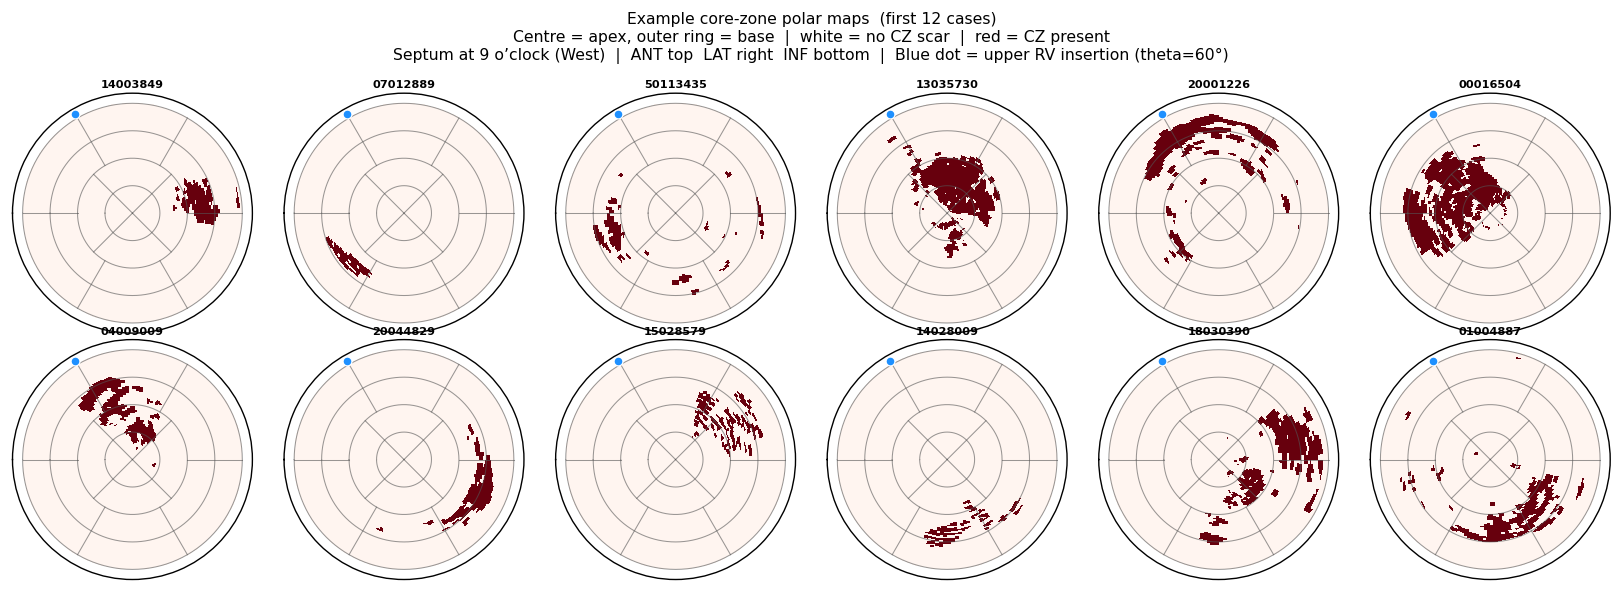

Saved example_polar_maps.png


In [7]:

# Show first N cases with available polar maps as bullseye plots (M03 style)
_SHOW_N  = 12
_NCOLS   = 6
_pm_keys = list(pmaps.keys())[:_SHOW_N]
_nrows   = int(np.ceil(len(_pm_keys) / _NCOLS))

fig = plt.figure(figsize=(_NCOLS * 2.2, _nrows * 2.4))
fig.suptitle(
    f'Example core-zone polar maps  (first {len(_pm_keys)} cases)\n'
    'Centre = apex, outer ring = base  |  white = no CZ scar  |  red = CZ present\n'
    'Septum at 9 o’clock (West)  |  ANT top  LAT right  INF bottom  |  '
    'Blue dot = upper RV insertion (theta=60°)',
    fontsize=9,
)

for idx, key in enumerate(_pm_keys):
    ax = fig.add_subplot(_nrows, _NCOLS, idx + 1, projection='polar')
    draw_bullseye_m04(pmaps[key], ax, cmap='Reds', vmax=1.0)
    pid = key.split('/')[-1]
    ax.set_title(pid, fontsize=6.5, pad=3)

plt.tight_layout()
plt.savefig(OUT / 'example_polar_maps.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved example_polar_maps.png')


## Section 2 - Assign Anatomy

Each polar bin is assigned to one of the 17 AHA segments and then grouped into LAD, RCA, or LCX territory. This is the anatomical coordinate system used by the rest of the notebook.

Important: the territories do **not** occupy the same number of polar bins. LAD includes more/larger AHA segments, including the apex, so its denominator is larger. Territory burden is therefore reported as:

`scar-positive bins in territory / total bins assigned to that territory`

This makes LAD/RCA/LCX comparable as **fractions of each territory affected**, not raw bin counts.


### 2.1 AHA-17 Segments and Coronary Territory Grids


In [8]:
def _aha_segment_grid(n_r=N_R, n_theta=N_THETA):
    labels = np.zeros((n_r, n_theta), dtype=np.int64)
    rc = (np.arange(n_r) + 0.5) / n_r
    tc = (np.arange(n_theta) + 0.5) / n_theta * 360.0
    for ri, radius in enumerate(rc):
        for ti, theta_deg in enumerate(tc):
            if radius < 0.25:
                labels[ri, ti] = 17
            elif radius < 0.50:
                if   45  <= theta_deg < 135: labels[ri, ti] = 13
                elif 135 <= theta_deg < 225: labels[ri, ti] = 16
                elif 225 <= theta_deg < 315: labels[ri, ti] = 15
                else:                        labels[ri, ti] = 14
            elif radius < 0.75:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 8
                elif 60  <= theta_deg < 120: labels[ri, ti] = 7
                elif 120 <= theta_deg < 180: labels[ri, ti] = 12
                elif 180 <= theta_deg < 240: labels[ri, ti] = 11
                elif 240 <= theta_deg < 300: labels[ri, ti] = 10
                else:                        labels[ri, ti] = 9
            else:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 2
                elif 60  <= theta_deg < 120: labels[ri, ti] = 1
                elif 120 <= theta_deg < 180: labels[ri, ti] = 6
                elif 180 <= theta_deg < 240: labels[ri, ti] = 5
                elif 240 <= theta_deg < 300: labels[ri, ti] = 4
                else:                        labels[ri, ti] = 3
    return labels


AHA_GRID = _aha_segment_grid()

SEG_LABELS = {
    1:'bas ant',  2:'bas ant-sep', 3:'bas inf-sep', 4:'bas inf',
    5:'bas inf-lat', 6:'bas ant-lat',
    7:'mid ant',  8:'mid ant-sep', 9:'mid inf-sep', 10:'mid inf',
    11:'mid inf-lat', 12:'mid ant-lat',
    13:'api ant', 14:'api sep',   15:'api inf',    16:'api lat', 17:'apex',
}

TERRITORY = {
    'LAD': [1, 2, 7, 8, 13, 14, 17],
    'RCA': [3, 4, 9, 10, 15],
    'LCX': [5, 6, 11, 12, 16],
}

SEG_TERRITORY = {s: t for t, segs in TERRITORY.items() for s in segs}

TERRITORY_GRID = np.full((N_R, N_THETA), '', dtype=object)
for terr, segs in TERRITORY.items():
    for seg in segs:
        TERRITORY_GRID[AHA_GRID == seg] = terr

# Number of polar bins per territory (denominator for scar burden)
TERR_NBINS = {t: int((TERRITORY_GRID == t).sum()) for t in TERRITORY}

print('Polar-bin denominator per coronary territory:')
for t, n in TERR_NBINS.items():
    print(f'  {t}: {n} polar bins ({100*n/(N_R*N_THETA):.1f}% of the 64x128 grid)')
print('These denominators are used to report territory burden as a fraction of each territory, not as raw size.')


Polar-bin denominator per coronary territory:
  LAD: 4448 polar bins (54.3% of the 64x128 grid)
  RCA: 1888 polar bins (23.0% of the 64x128 grid)
  LCX: 1856 polar bins (22.7% of the 64x128 grid)
These denominators are used to report territory burden as a fraction of each territory, not as raw size.


## Section 3 - Analysis

Analysis asks whether derived scar descriptors relate meaningfully to clinical or anatomical questions. This section builds the analysis tables, runs spatial and clinical tests, and adds the supporting cross-feature analyses, then runs the normality checks, paired spatial tests, and age/clinical association analyses.


### 3.1 Territory Scar Burden


Patients in scar-analysis cohort: 84
  Patients with sex labels: 32 / 84 (38.1%)
  Patients with age labels: 32 / 84 (38.1%)
  Patients with both sex and age labels: 32 / 84 (38.1%)
  Patients with either sex or age label: 32 / 84 (38.1%)
  Patients with neither label: 52 / 84 (61.9%)
core_pct known: 63


,cohort,label,n_patients,percent_of_analysis_cohort
0,analysis patients with polar maps,sex,32,38.095238
1,analysis patients with polar maps,age,32,38.095238
2,analysis patients with polar maps,both_sex_and_age,32,38.095238
3,analysis patients with polar maps,sex_or_age,32,38.095238
4,analysis patients with polar maps,neither_sex_nor_age,52,61.904762


Saved analysis_label_availability.csv


,territory,mean_burden,median_burden,sd_burden,mean_scar_positive_bins,territory_bins,n_involved_at_threshold
0,LAD,0.053384,0.012702,0.083787,237.452381,4448,36
1,RCA,0.046635,0.035222,0.054334,88.047619,1888,49
2,LCX,0.050704,0.029364,0.061914,94.107143,1856,49


C:\Users\joan\AppData\Local\Temp\ipykernel_14064\3047040615.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_terr[0].boxplot(_box_data, labels=list(TERRITORY), showfliers=False, patch_artist=True,


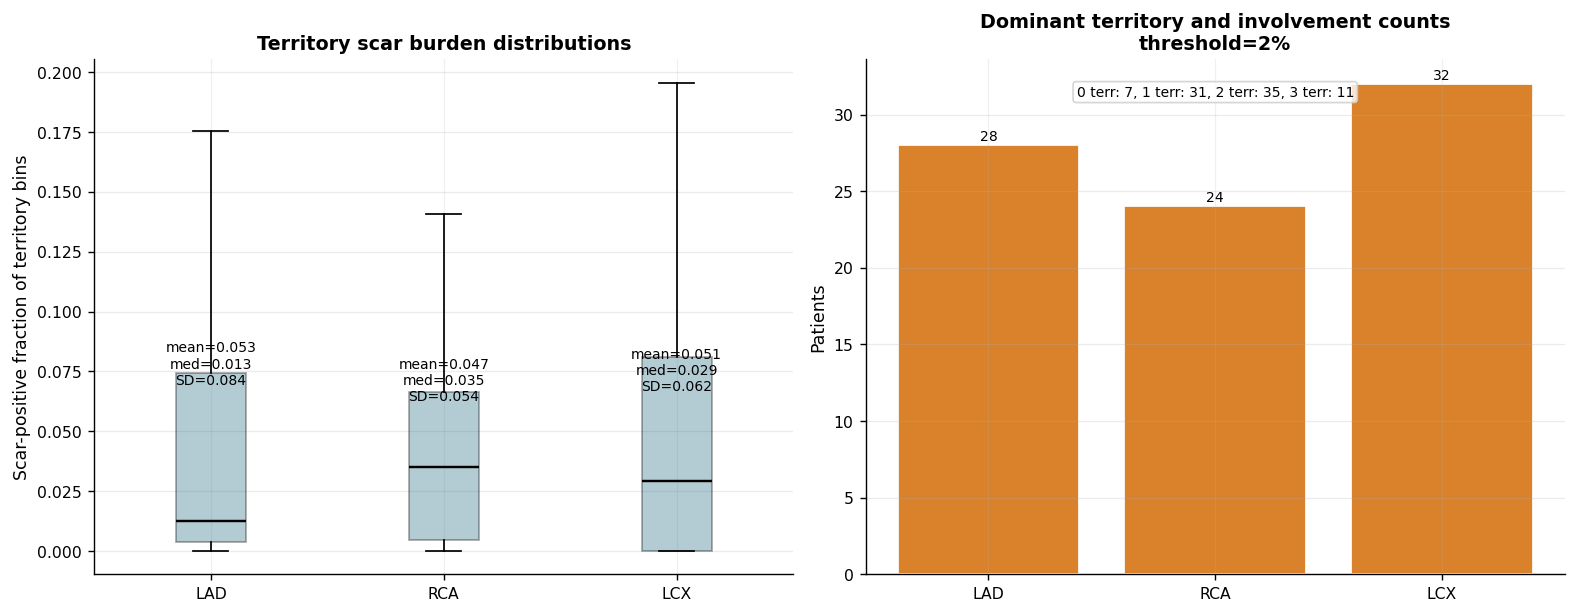

Saved territory_burden_distributions.png and territory_burden_summary.csv


,threshold,dominant_LAD_n,dominant_RCA_n,dominant_LCX_n,0_territories_involved_n,1_territories_involved_n,2_territories_involved_n,3_territories_involved_n,test,statistic,p_value
0,0.01,28,24,32,1,29,33,21,Friedman,2.88,0.236928
1,0.02,28,24,32,7,31,35,11,Friedman,2.88,0.236928
2,0.03,28,24,32,13,31,32,8,Friedman,2.88,0.236928
3,0.05,28,24,32,28,31,23,2,Friedman,2.88,0.236928
4,0.10,28,24,32,50,25,9,0,Friedman,2.88,0.236928


Saved territory_threshold_sensitivity.csv


In [9]:
# Recompute with raw columns for bin-count reporting.
terr_raw = scar_char.region_burden_table(
    pmaps,
    TERRITORY_GRID,
    TERRITORY,
    normalize_by_region_size=True,
    include_raw=True,
)
terr_raw['dominant'] = terr_raw[list(TERRITORY)].idxmax(axis=1)
terr_raw['n_involved'] = (terr_raw[list(TERRITORY)] >= SCAR_THRESH).sum(axis=1).astype(int)

for terr in TERRITORY:
    terr_raw[f'{terr}_cz_bins'] = terr_raw[f'{terr}_raw'].astype(int)

clinical_rows = []
for _, row in terr_raw.iterrows():
    pid = row['pid']
    clinical_rows.append({
        'key': row['key'],
        'pid': pid,
        'sex': sex_map.get(pid, np.nan),
        'age': float(age_map[pid]) if pid in age_map else np.nan,
        'core_pct': float(core_pct_map[pid]) if pid in core_pct_map else np.nan,
        'bz_core_pct': float(bz_core_pct_map[pid]) if pid in bz_core_pct_map else np.nan,
        'core_g': float(core_g_map[pid]) if pid in core_g_map else np.nan,
    })
clinical_df = pd.DataFrame(clinical_rows)

df = clinical_df.merge(
    terr_raw[['key', *TERRITORY, *(f'{t}_cz_bins' for t in TERRITORY), 'dominant', 'n_involved', 'total']],
    on='key',
    how='left',
).rename(columns={'total': 'total_scar'})

n_analysis = len(df)
n_sex_analysis = int(df['sex'].notna().sum())
n_age_analysis = int(df['age'].notna().sum())
n_both_analysis = int((df['sex'].notna() & df['age'].notna()).sum())
n_either_analysis = int((df['sex'].notna() | df['age'].notna()).sum())
n_neither_analysis = int((df['sex'].isna() & df['age'].isna()).sum())

analysis_label_summary = pd.DataFrame([
    {'cohort': 'analysis patients with polar maps', 'label': 'sex', 'n_patients': n_sex_analysis,
     'percent_of_analysis_cohort': 100 * n_sex_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'age', 'n_patients': n_age_analysis,
     'percent_of_analysis_cohort': 100 * n_age_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'both_sex_and_age', 'n_patients': n_both_analysis,
     'percent_of_analysis_cohort': 100 * n_both_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'sex_or_age', 'n_patients': n_either_analysis,
     'percent_of_analysis_cohort': 100 * n_either_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'neither_sex_nor_age', 'n_patients': n_neither_analysis,
     'percent_of_analysis_cohort': 100 * n_neither_analysis / max(n_analysis, 1)},
])

print(f'Patients in scar-analysis cohort: {n_analysis}')
print(f'  Patients with sex labels: {n_sex_analysis} / {n_analysis} ({100*n_sex_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with age labels: {n_age_analysis} / {n_analysis} ({100*n_age_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with both sex and age labels: {n_both_analysis} / {n_analysis} ({100*n_both_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with either sex or age label: {n_either_analysis} / {n_analysis} ({100*n_either_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with neither label: {n_neither_analysis} / {n_analysis} ({100*n_neither_analysis/max(n_analysis,1):.1f}%)')
print(f'core_pct known: {df["core_pct"].notna().sum()}')

analysis_label_summary.to_csv(OUT / 'analysis_label_availability.csv', index=False)
display(analysis_label_summary)
print('Saved analysis_label_availability.csv')

terr_stats = []
for terr in TERRITORY:
    vals = df[terr].dropna().astype(float)
    terr_stats.append({
        'territory': terr,
        'mean_burden': vals.mean(),
        'median_burden': vals.median(),
        'sd_burden': vals.std(),
        'mean_scar_positive_bins': df[f'{terr}_cz_bins'].mean(),
        'territory_bins': TERR_NBINS[terr],
        'n_involved_at_threshold': int((df[terr] >= SCAR_THRESH).sum()),
    })
terr_stats_df = pd.DataFrame(terr_stats)
display(terr_stats_df)
terr_stats_df.to_csv(OUT / 'territory_burden_summary.csv', index=False)

fig_terr, axes_terr = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
_box_data = [df[t].dropna().to_numpy(dtype=float) for t in TERRITORY]
axes_terr[0].boxplot(_box_data, labels=list(TERRITORY), showfliers=False, patch_artist=True,
                     medianprops=dict(color='black', lw=1.4),
                     boxprops=dict(facecolor=NOTEBOOK_PALETTE['primary'], alpha=0.35))
axes_terr[0].set_ylabel('Scar-positive fraction of territory bins')
axes_terr[0].set_title('Territory scar burden distributions')
axes_terr[0].grid(axis='y', alpha=0.25)
for i, row in enumerate(terr_stats, start=1):
    axes_terr[0].text(i, max(row['mean_burden'], 0) + 0.015,
                      f"mean={row['mean_burden']:.3f}\nmed={row['median_burden']:.3f}\nSD={row['sd_burden']:.3f}",
                      ha='center', va='bottom', fontsize=8)

_dom_counts = df['dominant'].value_counts().reindex(TERRITORY, fill_value=0)
axes_terr[1].bar(_dom_counts.index, _dom_counts.values, color=NOTEBOOK_PALETTE['secondary'], edgecolor='white')
axes_terr[1].set_ylabel('Patients')
axes_terr[1].set_title(f'Dominant territory and involvement counts\nthreshold={100*SCAR_THRESH:.0f}%')
axes_terr[1].grid(axis='y', alpha=0.25)
for x, val in enumerate(_dom_counts.values):
    axes_terr[1].text(x, val + 0.3, str(int(val)), ha='center', fontsize=8)
_inv_txt = ', '.join(f'{k} terr: {v}' for k, v in df['n_involved'].value_counts().sort_index().items())
axes_terr[1].text(0.5, 0.95, _inv_txt, ha='center', va='top', transform=axes_terr[1].transAxes, fontsize=8,
                  bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8, edgecolor='0.8'))
plt.savefig(OUT / 'territory_burden_distributions.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved territory_burden_distributions.png and territory_burden_summary.csv')

# Sensitivity of multi-territory involvement to the territory threshold.
_sens_rows = []
for _thr in [0.01, 0.02, 0.03, 0.05, 0.10]:
    _tmp = df.copy()
    _tmp['dominant_thr'] = _tmp[list(TERRITORY)].idxmax(axis=1)
    _tmp['n_involved_thr'] = (_tmp[list(TERRITORY)] >= _thr).sum(axis=1).astype(int)
    _dom_counts = _tmp['dominant_thr'].value_counts().reindex(TERRITORY, fill_value=0)
    _inv_counts = _tmp['n_involved_thr'].value_counts().reindex([0, 1, 2, 3], fill_value=0)
    _complete = _tmp.dropna(subset=list(TERRITORY))
    _test_name, _stat, _p = 'not_applicable', np.nan, np.nan
    if len(_complete) >= 3:
        try:
            _fr = scar_analysis.friedman_regions(_complete, list(TERRITORY))
            _test_name, _stat, _p = 'Friedman', _fr['statistic'], _fr['p_value']
        except Exception:
            _groups = [_complete.loc[_complete['dominant_thr'] == t, 'age'].dropna().to_numpy(float) for t in TERRITORY]
            if sum(len(g) > 1 for g in _groups) >= 2:
                _kw = kruskal(*[g for g in _groups if len(g) > 1])
                _test_name, _stat, _p = 'Kruskal-Wallis age by dominant territory', _kw.statistic, _kw.pvalue
    _sens_rows.append({
        'threshold': _thr,
        **{f'dominant_{t}_n': int(_dom_counts[t]) for t in TERRITORY},
        **{f'{i}_territories_involved_n': int(_inv_counts[i]) for i in [0, 1, 2, 3]},
        'test': _test_name,
        'statistic': _stat,
        'p_value': _p,
    })
threshold_sensitivity_df = pd.DataFrame(_sens_rows)
display(threshold_sensitivity_df)
threshold_sensitivity_df.to_csv(OUT / 'territory_threshold_sensitivity.csv', index=False)
print('Saved territory_threshold_sensitivity.csv')


### 3.2 Build Analysis Tables: AHA-17 Segment Burden


In [10]:
SEGMENTS = list(range(1, 18))
SEG_COLS = [f'seg_{s:02d}' for s in SEGMENTS]

seg_df = scar_char.region_burden_table(
    pmaps,
    AHA_GRID,
    SEGMENTS,
    prefix='seg_',
    normalize_by_region_size=True,
).rename(columns={'total': 'total_scar'})
seg_df['sex'] = seg_df['pid'].map(sex_map)
seg_df['age'] = seg_df['pid'].map(age_map).astype(float)
seg_matrix = seg_df[SEG_COLS].to_numpy(dtype=float) if len(seg_df) else np.empty((0, len(SEG_COLS)))

# Add segment columns to df for convenient downstream joins without changing existing territory logic.
if len(df) and len(seg_df):
    df = df.merge(seg_df[['key', *SEG_COLS]], on='key', how='left', suffixes=('', '_aha'))

age_desc = seg_df['age'].dropna()
sex_counts = seg_df['sex'].value_counts(dropna=True).rename_axis('sex').reset_index(name='n')
sex_counts['percent'] = 100 * sex_counts['n'] / max(int(sex_counts['n'].sum()), 1)

seg_summary = scar_char.region_summary(
    seg_df,
    SEG_COLS,
    labels=SEGMENTS,
    label_names=SEG_LABELS,
    value_name='extent',
).rename(columns={'region': 'segment'})
seg_summary['median_extent_positive'] = [
    float(seg_df[col][seg_df[col] > 0].median()) if (seg_df[col] > 0).any() else 0.0
    for col in SEG_COLS
]

print(f'Cohort with AHA segment vectors: n={len(seg_df)}')
print(f'  Patients with sex labels: {int(seg_df["sex"].notna().sum())} / {len(seg_df)} '
      f'({100*seg_df["sex"].notna().sum()/max(len(seg_df),1):.1f}%)')
print(f'  Patients with age labels: {int(seg_df["age"].notna().sum())} / {len(seg_df)} '
      f'({100*seg_df["age"].notna().sum()/max(len(seg_df),1):.1f}%)')
print(f'  Patients with both sex and age labels: '
      f'{int((seg_df["sex"].notna() & seg_df["age"].notna()).sum())} / {len(seg_df)} '
      f'({100*(seg_df["sex"].notna() & seg_df["age"].notna()).sum()/max(len(seg_df),1):.1f}%)')
if len(age_desc):
    print(f'Age: mean={age_desc.mean():.1f} +/- {age_desc.std(ddof=1):.1f} years  '
          f'(median={age_desc.median():.1f}, n={len(age_desc)})')
else:
    print('Age: no available values')
print('\nSex distribution:')
print(sex_counts.to_string(index=False) if len(sex_counts) else 'No sex labels available')
print('\nPer-segment scar summary:')
display(seg_summary)

seg_summary.to_csv(OUT / 'aha17_segment_summary.csv', index=False)
print('Saved aha17_segment_summary.csv')


Cohort with AHA segment vectors: n=84
  Patients with sex labels: 32 / 84 (38.1%)
  Patients with age labels: 32 / 84 (38.1%)
  Patients with both sex and age labels: 32 / 84 (38.1%)
Age: mean=64.6 +/- 9.5 years  (median=64.0, n=32)

Sex distribution:
sex  n  percent
  M 27   84.375
  F  5   15.625

Per-segment scar summary:


,segment,label,n_patients,n_with_scar,pct_with_scar,mean_extent_all,sd_extent_all,median_extent_all,mean_extent_positive,median_extent_positive
0,1,bas ant,84,22,26.190476,0.019683,0.061134,0.000000,0.075155,0.035511
1,2,bas ant-sep,84,33,39.285714,0.020833,0.044558,0.000000,0.053030,0.029762
2,3,bas inf-sep,84,21,25.000000,0.015873,0.056909,0.000000,0.063492,0.032738
3,4,bas inf,84,26,30.952381,0.013427,0.036744,0.000000,0.043378,0.024148
4,5,bas inf-lat,84,38,45.238095,0.028097,0.051199,0.000000,0.062108,0.029762
5,6,bas ant-lat,84,29,34.523810,0.029585,0.062519,0.000000,0.085694,0.065476
6,7,mid ant,84,29,34.523810,0.044237,0.116281,0.000000,0.128135,0.048295
7,8,mid ant-sep,84,43,51.190476,0.067177,0.135003,0.002976,0.131229,0.083333
8,9,mid inf-sep,84,47,55.952381,0.062571,0.107858,0.011905,0.111829,0.065476
9,10,mid inf,84,50,59.523810,0.079444,0.136945,0.019886,0.133466,0.076705


Saved aha17_segment_summary.csv


INSIHGT: RIGHT SKEWED DISTRIBUITON MEAN MEDIAN


### 3.3 Normality Diagnostics

These diagnostics document whether parametric assumptions are plausible. They are not the main evidence; they justify why most downstream tests use non-parametric statistics.


QQ plots are univariate diagnostics: use them to inspect whether each individual AHA segment or territory burden follows a normal distribution. The chi-square Mahalanobis QQ plot is multivariate: use it to inspect whether a whole vector, such as all 17 AHA segments together, behaves like a multivariate normal sample. In this notebook the univariate QQ plots justify non-parametric summaries for each feature, while the chi-square QQ plot documents that the full feature vector is also not well described by multivariate normality.


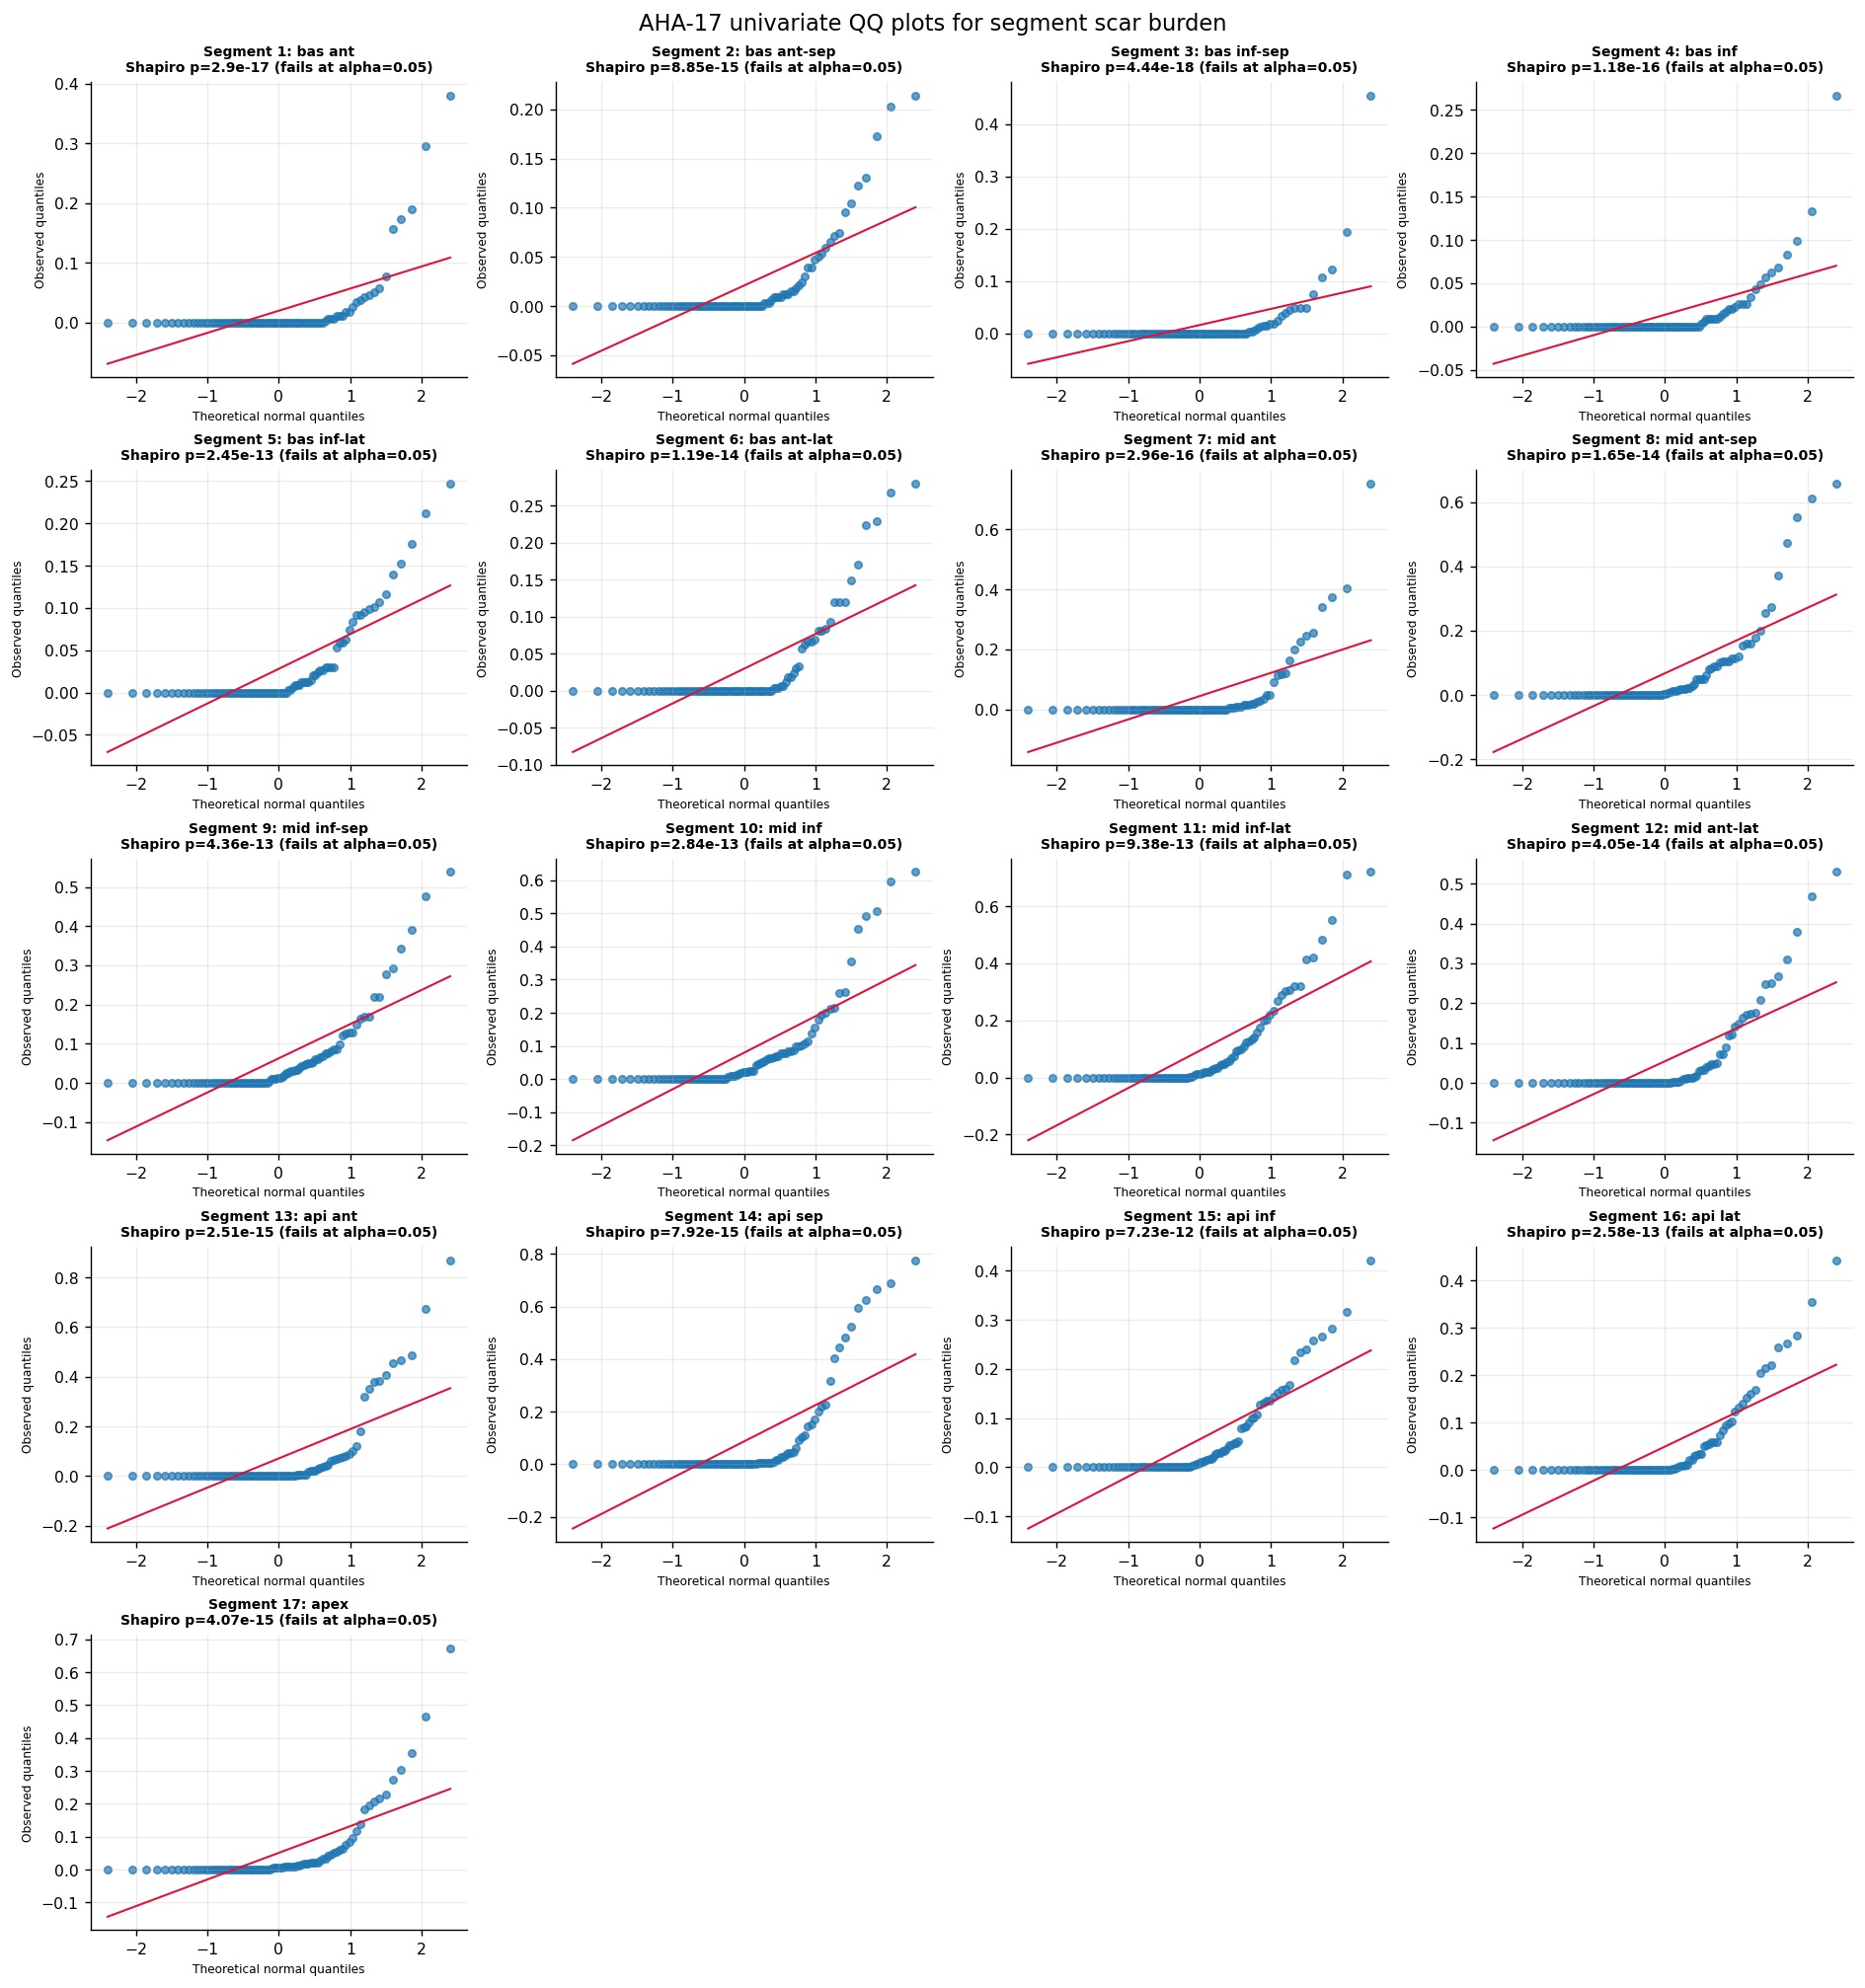

Saved normality_qq_aha17_segments.png


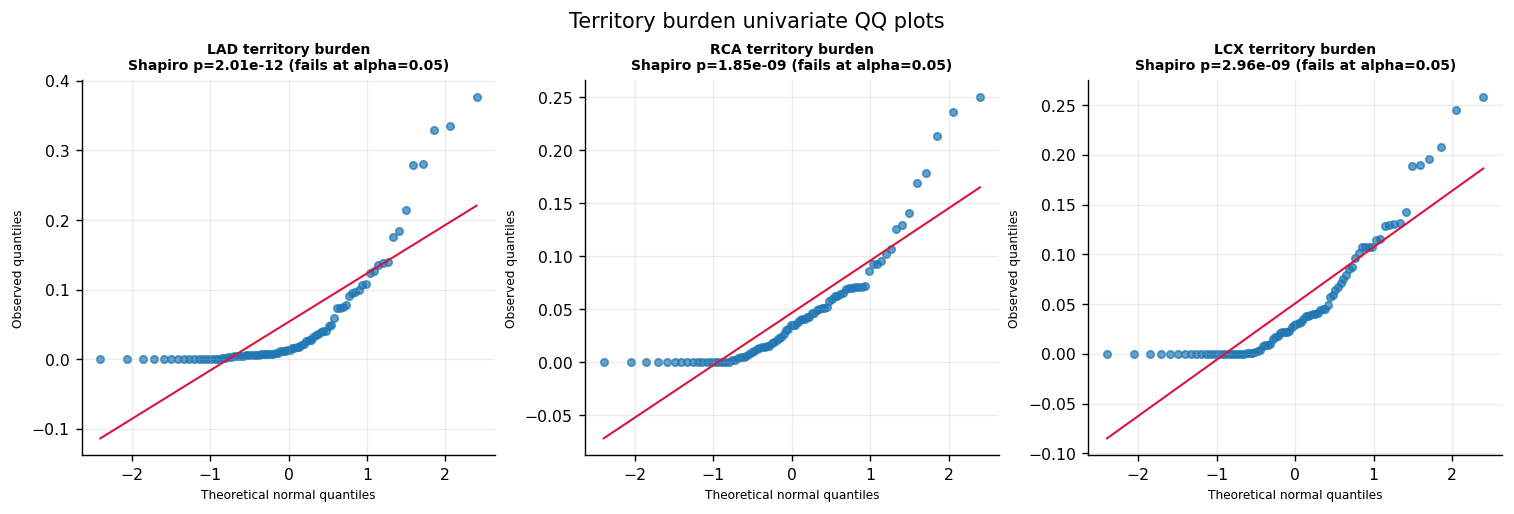

Saved normality_qq_territory_burdens.png


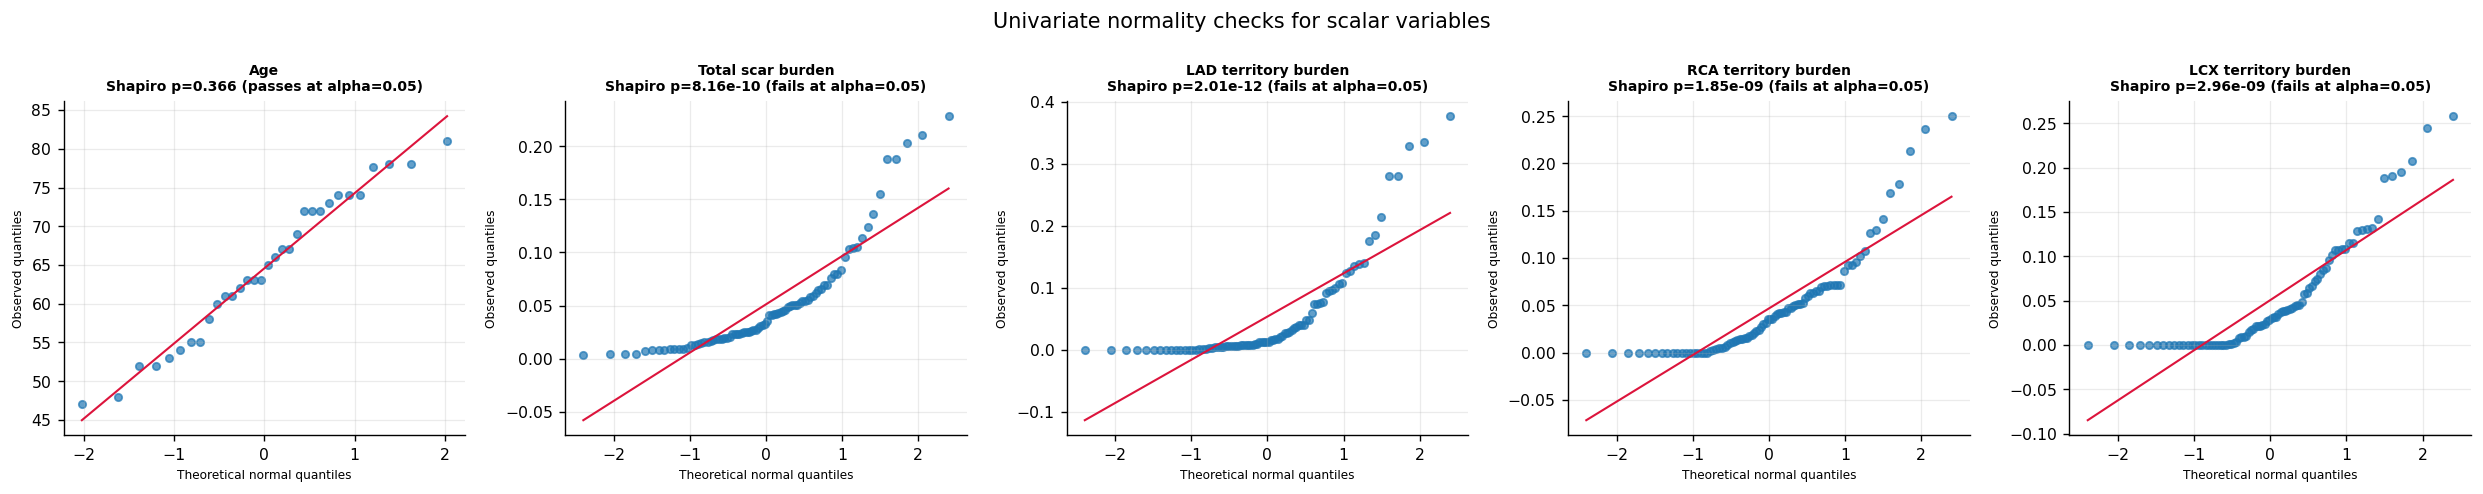

Saved normality_qq_scalar_variables.png
Normality summary (scalar variables + AHA-17 table):


,variable,group,n,shapiro_p,passes_0_05,segment,label
0,age,all,32,3.660392e-01,True,NaN,NaN
1,total_scar,all,84,8.163205e-10,False,NaN,NaN
2,LAD,all,84,2.005276e-12,False,NaN,NaN
3,RCA,all,84,1.853320e-09,False,NaN,NaN
4,LCX,all,84,2.956117e-09,False,NaN,NaN
5,seg_01,all,84,2.897333e-17,False,1.0,bas ant
6,seg_02,all,84,8.847204e-15,False,2.0,bas ant-sep
7,seg_03,all,84,4.444092e-18,False,3.0,bas inf-sep
8,seg_04,all,84,1.177742e-16,False,4.0,bas inf
9,seg_05,all,84,2.449489e-13,False,5.0,bas inf-lat


AHA-17 segments passing Shapiro alpha=0.05: 0 / 17
Saved normality_shapiro_scalar_aha17_summary.csv


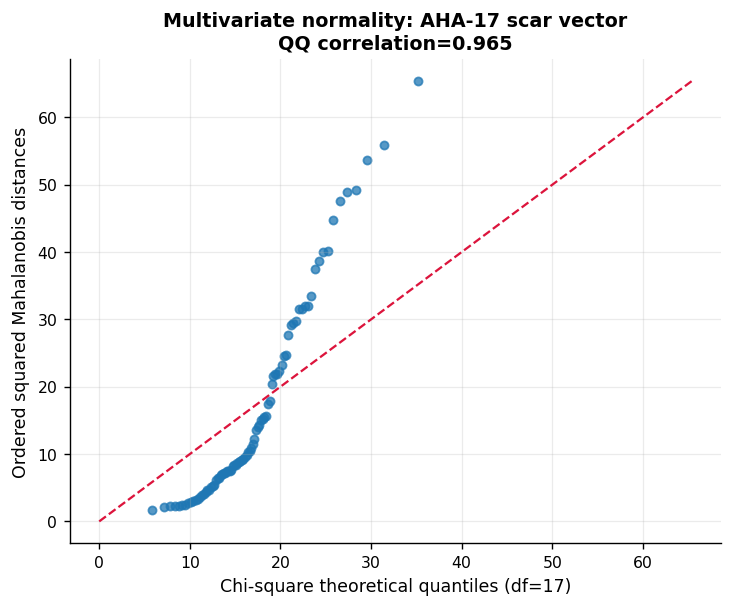

Saved normality_chisquare_aha17.png


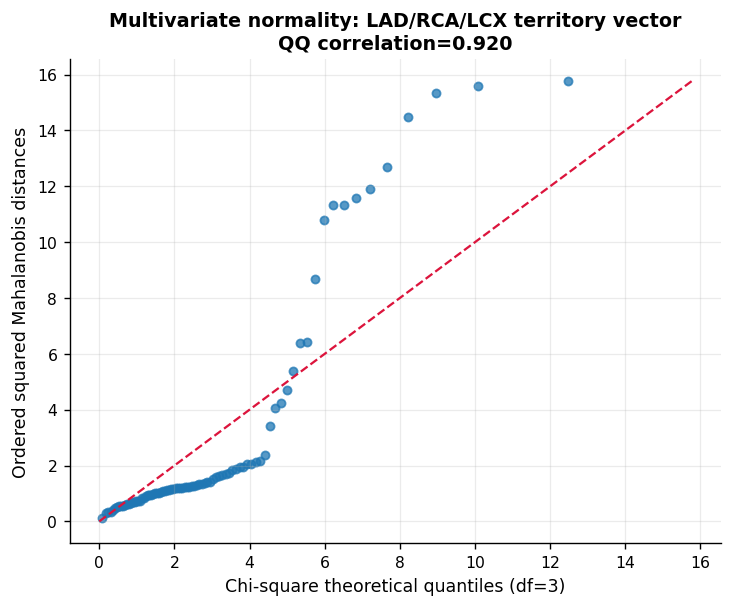

Saved normality_chisquare_territories.png


,analysis,n,p_variables,qq_correlation,status
0,Multivariate normality: AHA-17 scar vector,84,17,0.965362,computed
1,Multivariate normality: LAD/RCA/LCX territory ...,84,3,0.920359,computed


Saved normality_multivariate_summary.csv
Sex-stratified scalar normality checks:


,group,variable,n,shapiro_p,passes_0_05
0,M,total_scar,27,0.000446,False
1,M,LAD,27,0.000079,False
2,M,RCA,27,0.000084,False
3,M,LCX,27,0.001750,False
4,F,total_scar,5,0.000675,False
5,F,LAD,5,0.000187,False
6,F,RCA,5,0.353341,True
7,F,LCX,5,0.342452,True


Saved normality_by_sex_scalar_summary.csv
Descriptive covariance diagnostics for sex-group multivariate tests:


,analysis,n_male,n_female,p_variables,trace_cov_male,trace_cov_female,trace_ratio_larger_over_smaller,regularized_det_male,regularized_det_female,relative_frobenius_cov_difference,status
0,AHA-17 scar vector by sex,27,5,17,0.208783,0.172097,1.213167,1.946630e-44,1.104891e-112,0.903147,descriptive_only
1,LAD/RCA/LCX territory vector by sex,27,5,3,0.012234,0.030195,2.468113,5.345834e-08,3.699366e-09,0.816084,descriptive_only


Saved normality_covariance_diagnostics_by_sex.csv

Decision note: if Shapiro/QQ and covariance diagnostics look poor, use permutation p-values and non-parametric tests as the main results; keep parametric F tests as exploratory summaries.


In [11]:
_NORMALITY_ALPHA = 0.05


def _shapiro_result(values, alpha=_NORMALITY_ALPHA):
    values = pd.Series(values).dropna().astype(float).to_numpy()
    if len(values) < 3:
        return np.nan, len(values), False
    p_val = shapiro(values).pvalue if len(values) <= 5000 else np.nan
    return p_val, len(values), bool(np.isfinite(p_val) and p_val >= alpha)


def _qq_on_axis(ax, values, title, alpha=_NORMALITY_ALPHA):
    values = pd.Series(values).dropna().astype(float).to_numpy()
    if len(values) < 3:
        ax.text(0.5, 0.5, 'n < 3', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return np.nan
    osm, osr = probplot(values, dist='norm', fit=False)
    slope, intercept = np.polyfit(osm, osr, 1)
    ax.scatter(osm, osr, s=18, alpha=0.70)
    ax.plot(osm, slope * np.asarray(osm) + intercept, color='crimson', lw=1.2)
    p_val, _, passes = _shapiro_result(values, alpha=alpha)
    status = 'passes' if passes else 'fails'
    ax.set_title(f'{title}\nShapiro p={p_val:.3g} ({status} at alpha={alpha})', fontsize=8)
    ax.set_xlabel('Theoretical normal quantiles', fontsize=7)
    ax.set_ylabel('Observed quantiles', fontsize=7)
    ax.grid(alpha=0.25)
    return p_val


def _mahalanobis_chisquare_qq(X, title, out_name, variable_names=None, ridge=1e-8):
    X = np.asarray(X, dtype=float)
    X = X[np.isfinite(X).all(axis=1)]
    if X.shape[0] <= X.shape[1] or X.shape[0] < 5:
        print(f'Skipping {title}: n={X.shape[0]} <= p={X.shape[1]} or too few rows')
        return {'analysis': title, 'n': X.shape[0], 'p_variables': X.shape[1], 'status': 'skipped'}

    Xc = X - X.mean(axis=0, keepdims=True)
    cov = np.cov(Xc, rowvar=False)
    scale = np.trace(cov) / max(cov.shape[0], 1)
    cov_reg = cov + np.eye(cov.shape[0]) * ridge * max(scale, 1.0)
    inv_cov = np.linalg.pinv(cov_reg)
    d2 = np.einsum('ij,jk,ik->i', Xc, inv_cov, Xc)
    d2_sorted = np.sort(d2)
    probs = (np.arange(1, len(d2_sorted) + 1) - 0.5) / len(d2_sorted)
    chi_q = chi2.ppf(probs, df=X.shape[1])

    corr = float(np.corrcoef(chi_q, d2_sorted)[0, 1]) if len(d2_sorted) > 2 else np.nan
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(chi_q, d2_sorted, s=22, alpha=0.75)
    lim = max(float(np.nanmax(chi_q)), float(np.nanmax(d2_sorted)))
    ax.plot([0, lim], [0, lim], color='crimson', lw=1.3, ls='--')
    ax.set_xlabel(f'Chi-square theoretical quantiles (df={X.shape[1]})')
    ax.set_ylabel('Ordered squared Mahalanobis distances')
    ax.set_title(f'{title}\nQQ correlation={corr:.3f}')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / out_name, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {out_name}')
    return {'analysis': title, 'n': X.shape[0], 'p_variables': X.shape[1],
            'qq_correlation': corr, 'status': 'computed'}


def _covariance_diagnostic(X, labels, label_name):
    labels = np.asarray(labels)
    X = np.asarray(X, dtype=float)
    mask = np.isfinite(X).all(axis=1) & pd.Series(labels).isin(['M', 'F']).to_numpy()
    X = X[mask]
    labels = labels[mask]
    Xm = X[labels == 'M']
    Xf = X[labels == 'F']
    if len(Xm) < 2 or len(Xf) < 2:
        return {'analysis': label_name, 'status': 'skipped', 'reason': 'group n < 2'}
    cov_m = np.atleast_2d(np.cov(Xm, rowvar=False))
    cov_f = np.atleast_2d(np.cov(Xf, rowvar=False))
    trace_m = float(np.trace(cov_m))
    trace_f = float(np.trace(cov_f))
    det_m = float(np.linalg.det(cov_m + np.eye(cov_m.shape[0]) * 1e-8))
    det_f = float(np.linalg.det(cov_f + np.eye(cov_f.shape[0]) * 1e-8))
    frob_diff = float(np.linalg.norm(cov_m - cov_f, ord='fro'))
    frob_rel = frob_diff / max(float(np.linalg.norm(cov_m, ord='fro')), float(np.linalg.norm(cov_f, ord='fro')), 1e-12)
    return {
        'analysis': label_name,
        'n_male': len(Xm),
        'n_female': len(Xf),
        'p_variables': X.shape[1],
        'trace_cov_male': trace_m,
        'trace_cov_female': trace_f,
        'trace_ratio_larger_over_smaller': max(trace_m, trace_f) / max(min(trace_m, trace_f), 1e-12),
        'regularized_det_male': det_m,
        'regularized_det_female': det_f,
        'relative_frobenius_cov_difference': frob_rel,
        'status': 'descriptive_only',
    }



# Univariate QQ plots for every AHA segment and each coronary territory.
fig_segqq, axes_segqq = plt.subplots(5, 4, figsize=(15, 16), constrained_layout=True)
fig_segqq.suptitle('AHA-17 univariate QQ plots for segment scar burden', fontsize=13)
for ax, seg, col in zip(axes_segqq.ravel(), SEGMENTS, SEG_COLS):
    _qq_on_axis(ax, seg_df[col], f'Segment {seg}: {SEG_LABELS[seg]}')
for ax in axes_segqq.ravel()[len(SEGMENTS):]:
    ax.axis('off')
plt.savefig(OUT / 'normality_qq_aha17_segments.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved normality_qq_aha17_segments.png')

fig_terrqq, axes_terrqq = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
fig_terrqq.suptitle('Territory burden univariate QQ plots', fontsize=12)
for ax, terr in zip(axes_terrqq, TERRITORY):
    _qq_on_axis(ax, df[terr], f'{terr} territory burden')
plt.savefig(OUT / 'normality_qq_territory_burdens.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved normality_qq_territory_burdens.png')

# 4.1a: scalar QQ-plots and Shapiro-Wilk.
scalar_specs = [
    ('age', 'Age', seg_df['age']),
    ('total_scar', 'Total scar burden', seg_df['total_scar']),
    ('LAD', 'LAD territory burden', df['LAD']),
    ('RCA', 'RCA territory burden', df['RCA']),
    ('LCX', 'LCX territory burden', df['LCX']),
]
fig_qq, axes_qq = plt.subplots(1, len(scalar_specs), figsize=(4 * len(scalar_specs), 4))
fig_qq.suptitle('Univariate normality checks for scalar variables', fontsize=12)
normality_rows = []
for ax, (var, title, values) in zip(np.atleast_1d(axes_qq), scalar_specs):
    p_val = _qq_on_axis(ax, values, title)
    _, n_var, passes = _shapiro_result(values)
    normality_rows.append({'variable': var, 'group': 'all', 'n': n_var,
                           'shapiro_p': p_val, 'passes_0_05': passes})
plt.tight_layout()
plt.savefig(OUT / 'normality_qq_scalar_variables.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved normality_qq_scalar_variables.png')

# 4.1b: AHA-17 Shapiro table only.
for seg, col in zip(SEGMENTS, SEG_COLS):
    p_val, n_var, passes = _shapiro_result(seg_df[col])
    normality_rows.append({'variable': col, 'segment': seg, 'label': SEG_LABELS[seg],
                           'group': 'all', 'n': n_var, 'shapiro_p': p_val,
                           'passes_0_05': passes})
normality_summary = pd.DataFrame(normality_rows)
print('Normality summary (scalar variables + AHA-17 table):')
display(normality_summary)
print('AHA-17 segments passing Shapiro alpha=0.05:',
      int(normality_summary[normality_summary['variable'].isin(SEG_COLS)]['passes_0_05'].sum()),
      '/', len(SEG_COLS))
normality_summary.to_csv(OUT / 'normality_shapiro_scalar_aha17_summary.csv', index=False)
print('Saved normality_shapiro_scalar_aha17_summary.csv')

# 4.1c: multivariate normality diagnostics.
mv_rows = []
mv_rows.append(_mahalanobis_chisquare_qq(seg_df[SEG_COLS].to_numpy(dtype=float),
                                         'Multivariate normality: AHA-17 scar vector',
                                         'normality_chisquare_aha17.png'))
mv_rows.append(_mahalanobis_chisquare_qq(df[['LAD', 'RCA', 'LCX']].to_numpy(dtype=float),
                                         'Multivariate normality: LAD/RCA/LCX territory vector',
                                         'normality_chisquare_territories.png'))
multivariate_normality_summary = pd.DataFrame(mv_rows)
display(multivariate_normality_summary)
multivariate_normality_summary.to_csv(OUT / 'normality_multivariate_summary.csv', index=False)
print('Saved normality_multivariate_summary.csv')

# 4.1d: sex-stratified scalar normality checks.
sex_norm_rows = []
if 'sex' in df.columns and df['sex'].notna().any():
    for group_label, group_df in [('M', df[df['sex'] == 'M']), ('F', df[df['sex'] == 'F'])]:
        for var in ['total_scar', 'LAD', 'RCA', 'LCX']:
            p_val, n_var, passes = _shapiro_result(group_df[var])
            sex_norm_rows.append({'group': group_label, 'variable': var, 'n': n_var,
                                  'shapiro_p': p_val, 'passes_0_05': passes})
sex_group_normality = pd.DataFrame(sex_norm_rows)
print('Sex-stratified scalar normality checks:')
display(sex_group_normality)
sex_group_normality.to_csv(OUT / 'normality_by_sex_scalar_summary.csv', index=False)
print('Saved normality_by_sex_scalar_summary.csv')

# 4.1e: covariance diagnostics for parametric Hotelling/MANOVA-style tests.
cov_rows = []
sex_seg_for_cov = seg_df.dropna(subset=['sex']).copy()
sex_seg_for_cov = sex_seg_for_cov[sex_seg_for_cov['sex'].isin(['M', 'F'])]
if len(sex_seg_for_cov):
    cov_rows.append(_covariance_diagnostic(sex_seg_for_cov[SEG_COLS].to_numpy(dtype=float),
                                           sex_seg_for_cov['sex'].to_numpy(),
                                           'AHA-17 scar vector by sex'))
sex_df_for_cov = df.dropna(subset=['sex']).copy()
sex_df_for_cov = sex_df_for_cov[sex_df_for_cov['sex'].isin(['M', 'F'])]
if len(sex_df_for_cov):
    cov_rows.append(_covariance_diagnostic(sex_df_for_cov[['LAD', 'RCA', 'LCX']].to_numpy(dtype=float),
                                           sex_df_for_cov['sex'].to_numpy(),
                                           'LAD/RCA/LCX territory vector by sex'))
covariance_diagnostics = pd.DataFrame(cov_rows)
print('Descriptive covariance diagnostics for sex-group multivariate tests:')
display(covariance_diagnostics)
covariance_diagnostics.to_csv(OUT / 'normality_covariance_diagnostics_by_sex.csv', index=False)
print('Saved normality_covariance_diagnostics_by_sex.csv')

print('\nDecision note: if Shapiro/QQ and covariance diagnostics look poor, use permutation p-values and non-parametric tests as the main results; keep parametric F tests as exploratory summaries.')


### 3.4 AHA-17 Within-Patient Segment Comparison

This tests whether scar is uniformly distributed across the 17 AHA segments. Each patient contributes 17 paired values, so the global test is the **Friedman test**, a non-parametric repeated-measures alternative to ANOVA.

Null hypothesis: the 17 AHA segments have the same scar-burden distribution. A small p-value means scar burden is spatially non-uniform. Pairwise post-hoc tests use **Wilcoxon signed-rank** because segment pairs are still paired within patient, with **Bonferroni correction** for the many segment pairs.


AHA-17 within-patient Friedman test: chi2=98.98, p=5.371e-14, n=84
Null hypothesis: all 17 AHA segments have the same scar-burden distribution.
Interpretation: small p-value => scar burden is spatially non-uniform across AHA segments.


,segment,label,mean_extent_all,sd_extent_all,median_extent_all,pct_with_scar
10,11,mid inf-lat,0.093537,0.158894,0.011905,55.952381
13,14,api sep,0.086891,0.185619,0.000000,44.047619
9,10,mid inf,0.079444,0.136945,0.019886,59.523810
12,13,api ant,0.071498,0.163602,0.000000,41.666667
7,8,mid ant-sep,0.067177,0.135003,0.002976,51.190476
8,9,mid inf-sep,0.062571,0.107858,0.011905,55.952381
14,15,api inf,0.056641,0.089096,0.009766,54.761905
11,12,mid ant-lat,0.053890,0.107102,0.000000,46.428571
16,17,apex,0.050921,0.111588,0.006592,57.142857
15,16,api lat,0.049200,0.089899,0.000000,46.428571


C:\Users\joan\AppData\Local\Temp\ipykernel_14064\1405886929.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


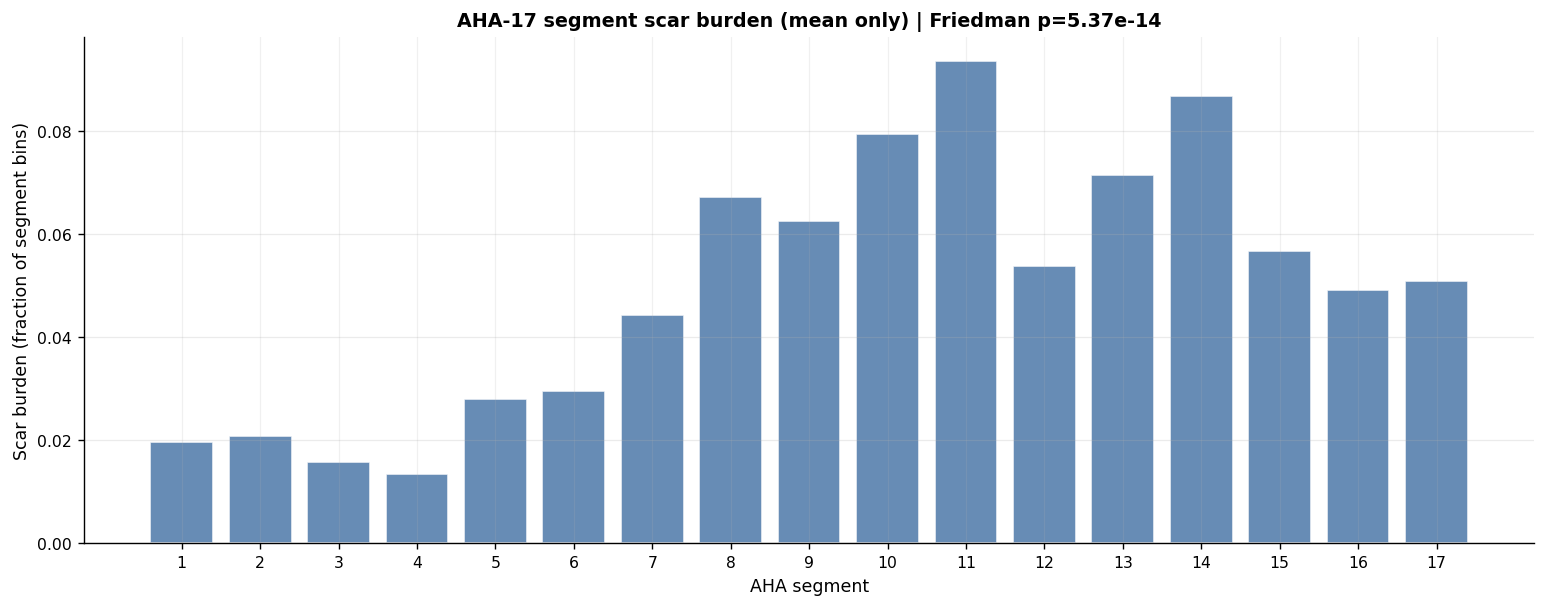

Saved aha17_within_patient_friedman.png
Saved aha17_segment_comparison_ranked.csv and aha17_pairwise_wilcoxon_bonferroni.csv


In [12]:
aha_complete = seg_df.dropna(subset=SEG_COLS).copy()
if len(aha_complete) >= 3:
    aha_friedman = scar_analysis.friedman_regions(aha_complete, SEG_COLS)
    aha_fr_stat = aha_friedman['statistic']
    aha_fr_p = aha_friedman['p_value']

    aha_segment_comparison = seg_summary[['segment', 'label', 'mean_extent_all', 'sd_extent_all',
                                           'median_extent_all', 'pct_with_scar']].copy()
    aha_segment_comparison = aha_segment_comparison.sort_values('mean_extent_all', ascending=False)

    print(f'AHA-17 within-patient Friedman test: chi2={aha_fr_stat:.2f}, p={aha_fr_p:.4g}, n={aha_friedman["n"]}')
    print('Null hypothesis: all 17 AHA segments have the same scar-burden distribution.')
    print('Interpretation: small p-value => scar burden is spatially non-uniform across AHA segments.')
    display(aha_segment_comparison)

    aha_pairwise = scar_analysis.pairwise_wilcoxon_regions(aha_complete, SEG_COLS, labels=SEGMENTS)
    aha_pairwise['label_a'] = aha_pairwise['region_a'].map(SEG_LABELS)
    aha_pairwise['label_b'] = aha_pairwise['region_b'].map(SEG_LABELS)
    aha_pairwise = aha_pairwise.rename(columns={'region_a': 'segment_a', 'region_b': 'segment_b'})

    fig_aha_cmp, ax_aha_cmp = plt.subplots(figsize=(12.5, 5.0), constrained_layout=True)
    plot_df = seg_summary.sort_values('segment')
    ax_aha_cmp.bar(plot_df['segment'], plot_df['mean_extent_all'],
                   color='#4c78a8', edgecolor='white', alpha=0.85)
    ax_aha_cmp.set_xticks(SEGMENTS)
    ax_aha_cmp.set_xlabel('AHA segment')
    ax_aha_cmp.set_ylabel('Scar burden (fraction of segment bins)')
    ax_aha_cmp.set_title(f'AHA-17 segment scar burden (mean only) | Friedman p={aha_fr_p:.3g}')
    ax_aha_cmp.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'aha17_within_patient_friedman.png', bbox_inches='tight', dpi=300)
    plt.show()

    aha_segment_comparison.to_csv(OUT / 'aha17_segment_comparison_ranked.csv', index=False)
    aha_pairwise.to_csv(OUT / 'aha17_pairwise_wilcoxon_bonferroni.csv', index=False)
    print('Saved aha17_within_patient_friedman.png')
    print('Saved aha17_segment_comparison_ranked.csv and aha17_pairwise_wilcoxon_bonferroni.csv')
else:
    print(f'Skipping AHA-17 Friedman test: only {len(aha_complete)} complete patient vectors available.')


INSIGHT: NON SIGNIFICATIVE


### 3.5 Age Effects Across Vertex-Based AHA-17 Segments

This uses the binary polar-map representation: each bin is counted as scar-positive or scar-negative. Age associations use **Spearman rho** because it tests monotonic association without assuming normally distributed scar burden or linear residuals.


,segment,label,n,spearman_rho,p_uncorrected,p_bonferroni,significant_bonf_0_05
0,1,bas ant,32,0.118870,0.516999,1.000000,False
1,2,bas ant-sep,32,0.094898,0.605410,1.000000,False
2,3,bas inf-sep,32,0.062261,0.734972,1.000000,False
3,4,bas inf,32,0.038882,0.832670,1.000000,False
4,5,bas inf-lat,32,0.365786,0.039510,0.671670,False
5,6,bas ant-lat,32,0.296382,0.099531,1.000000,False
6,7,mid ant,32,0.142769,0.435688,1.000000,False
7,8,mid ant-sep,32,0.133839,0.465219,1.000000,False
8,9,mid inf-sep,32,0.144337,0.430611,1.000000,False
9,10,mid inf,32,0.286885,0.111391,1.000000,False


Bonferroni alpha: 0.0029
Saved age_spearman_aha17.csv


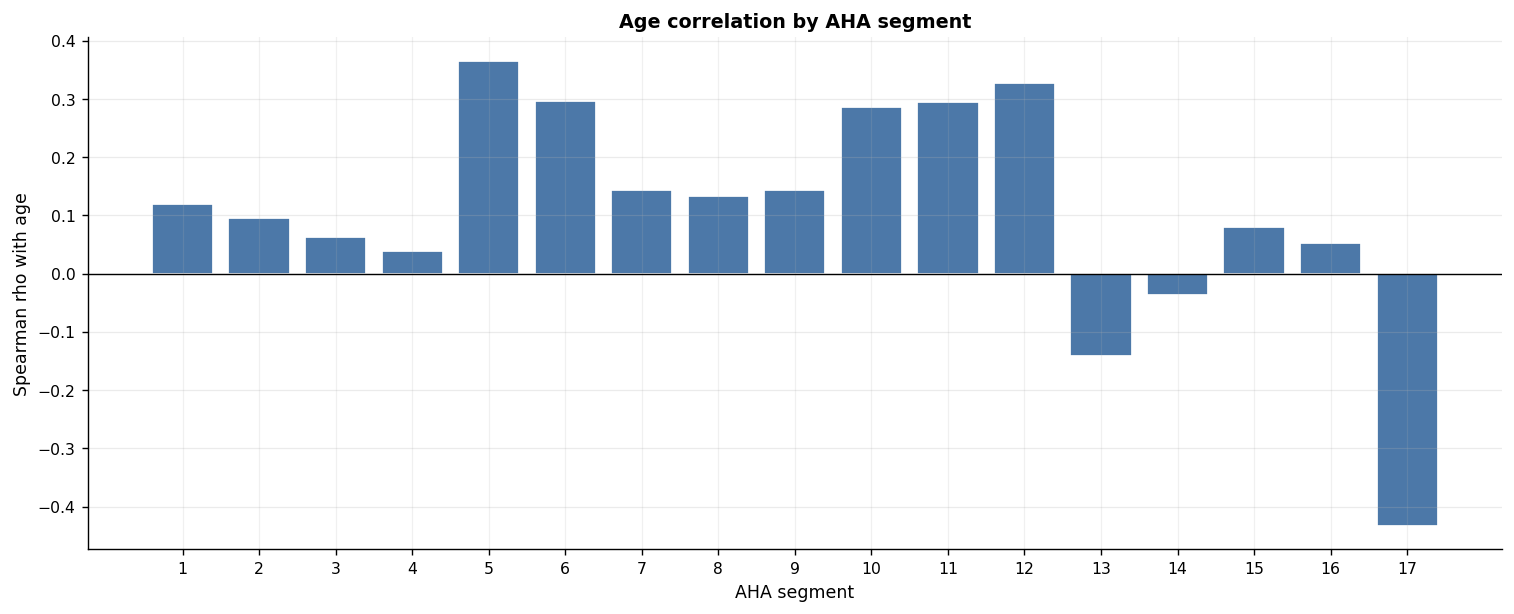

Saved age_spearman_aha17.png


,segment,label,median_age_cut,young_mean,old_mean,mannwhitney_p,p_bonferroni
0,1,bas ant,64.0,0.028232,0.026634,0.757378,1.00000
1,2,bas ant-sep,64.0,0.017485,0.024740,0.474490,1.00000
2,3,bas inf-sep,64.0,0.011161,0.023065,0.617807,1.00000
3,4,bas inf,64.0,0.009943,0.011896,0.908686,1.00000
4,5,bas inf-lat,64.0,0.011905,0.020089,0.089425,1.00000
5,6,bas ant-lat,64.0,0.010045,0.042783,0.024802,0.42163
6,7,mid ant,64.0,0.035866,0.014027,0.447964,1.00000
7,8,mid ant-sep,64.0,0.056920,0.113281,0.165859,1.00000
8,9,mid inf-sep,64.0,0.061570,0.127976,0.120996,1.00000
9,10,mid inf,64.0,0.037997,0.112749,0.215273,1.00000


Saved age_median_split_mannwhitney_aha17.csv


In [13]:
age_seg = seg_df.dropna(subset=['age']).copy()
age_results = scar_analysis.spearman_by_region(
    seg_df,
    SEG_COLS,
    'age',
    labels=SEGMENTS,
    bonferroni=True,
).rename(columns={'region': 'segment'})
age_results['label'] = age_results['segment'].map(SEG_LABELS)
age_results = age_results[['segment', 'label', 'n', 'spearman_rho', 'p_uncorrected', 'p_bonferroni', 'significant_bonf_0_05']]
alpha_age = 0.05 / len(SEG_COLS)
display(age_results)
age_results.to_csv(OUT / 'age_spearman_aha17.csv', index=False)
print(f'Bonferroni alpha: {alpha_age:.4f}')
print('Saved age_spearman_aha17.csv')

fig_age17, ax_age17 = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
ax_age17.bar(age_results['segment'], age_results['spearman_rho'], color='#4c78a8', edgecolor='white')
ax_age17.axhline(0, color='black', lw=0.8)
ax_age17.set_xticks(SEGMENTS)
ax_age17.set_xlabel('AHA segment')
ax_age17.set_ylabel('Spearman rho with age')
ax_age17.set_title('Age correlation by AHA segment')
ax_age17.grid(axis='y', alpha=0.25)
plt.savefig(OUT / 'age_spearman_aha17.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved age_spearman_aha17.png')

if len(age_seg) >= 6:
    median_age = age_seg['age'].median()
    age_seg['age_group_median'] = np.where(age_seg['age'] <= median_age, 'younger_or_equal_median', 'older_than_median')
    age_split_rows = []
    for seg, col in zip(SEGMENTS, SEG_COLS):
        young = age_seg.loc[age_seg['age_group_median'] == 'younger_or_equal_median', col].dropna().to_numpy(dtype=float)
        old = age_seg.loc[age_seg['age_group_median'] == 'older_than_median', col].dropna().to_numpy(dtype=float)
        if len(young) and len(old):
            u, p_u = mannwhitneyu(young, old, alternative='two-sided')
        else:
            u, p_u = np.nan, np.nan
        age_split_rows.append({
            'segment': seg,
            'label': SEG_LABELS[seg],
            'median_age_cut': median_age,
            'young_mean': np.nanmean(young) if len(young) else np.nan,
            'old_mean': np.nanmean(old) if len(old) else np.nan,
            'mannwhitney_p': p_u,
            'p_bonferroni': min(p_u * len(SEG_COLS), 1.0) if np.isfinite(p_u) else np.nan,
        })
    age_split_results = pd.DataFrame(age_split_rows)
    display(age_split_results)
    age_split_results.to_csv(OUT / 'age_median_split_mannwhitney_aha17.csv', index=False)
    print('Saved age_median_split_mannwhitney_aha17.csv')


INSIGHT: NON SIGNIFICANT


### 3.6 Vertex-Based Territory Comparison

Each patient has three paired territory values: LAD, RCA, and LCX burden. The **Friedman test** asks whether those three within-patient territory distributions are equal without assuming normality.


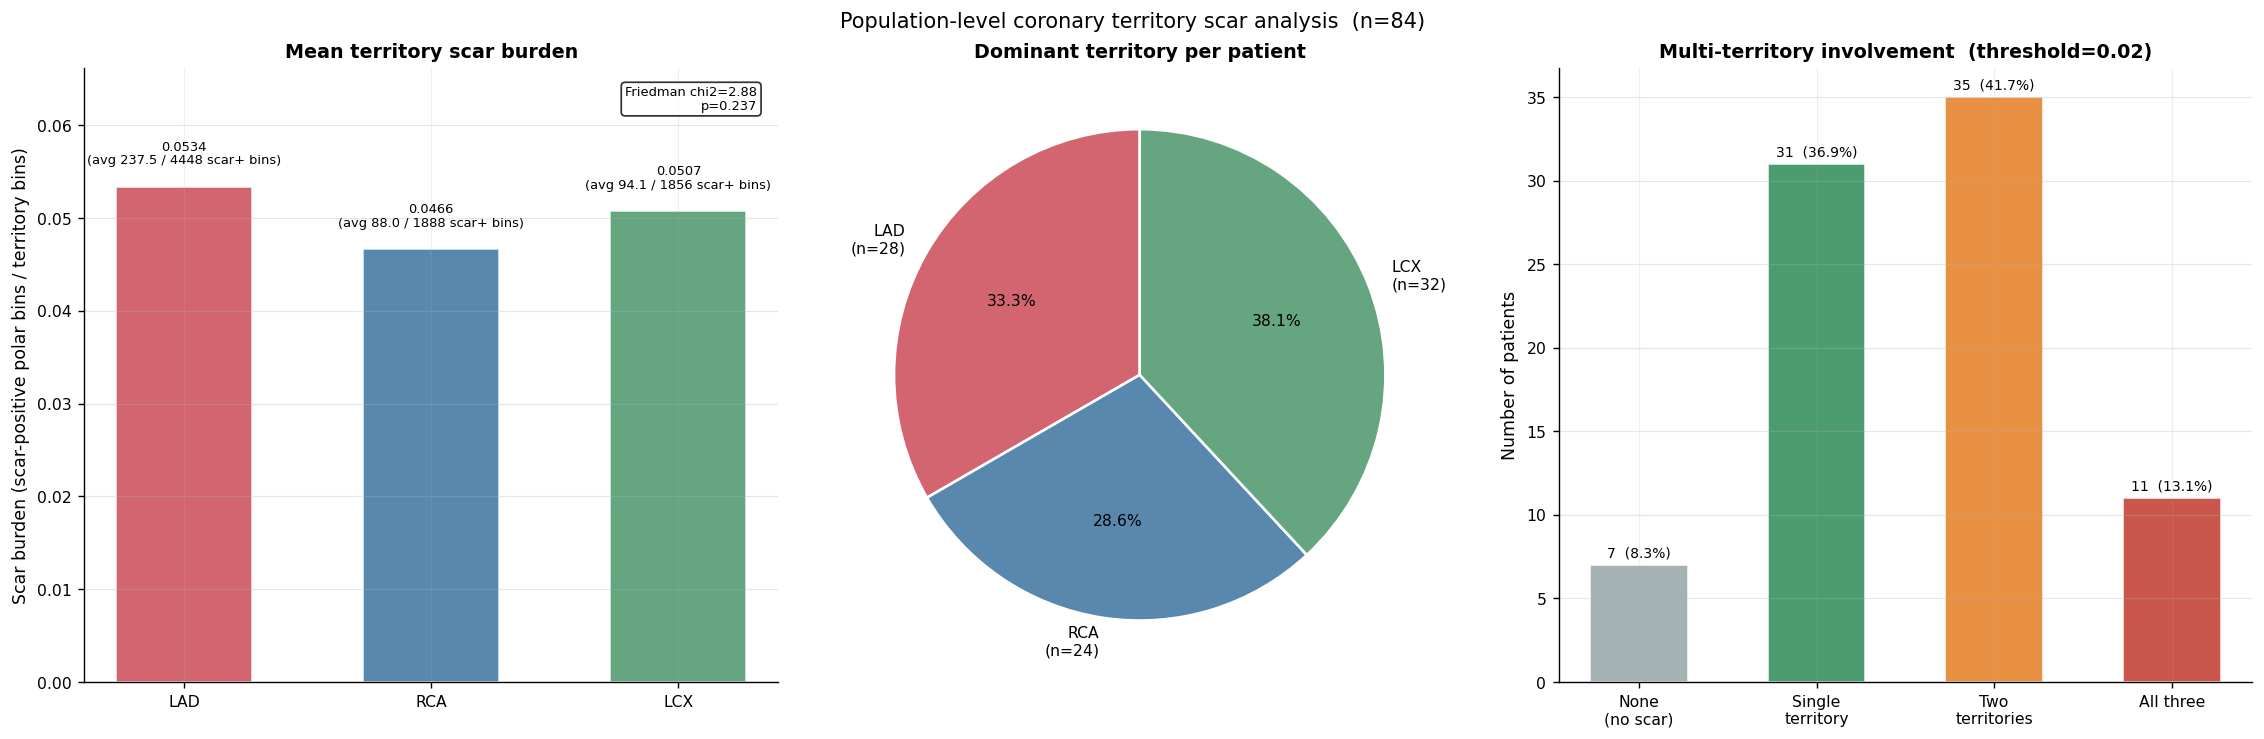

Saved territory_population.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), constrained_layout=True)
fig.suptitle(f'Population-level coronary territory scar analysis  (n={len(df)})',
             fontsize=12)

# --- Plot 1: Mean territory burden with numerator/denominator annotations ---
ax = axes[0]
terr_list   = ['LAD', 'RCA', 'LCX']
terr_means  = [df[t].mean()  for t in terr_list]
terr_cols   = [TERR_COLORS[t] for t in terr_list]
bars = ax.bar(terr_list, terr_means,
              color=terr_cols, alpha=0.80, edgecolor='white', width=0.55)
_ymax_mean = max(terr_means) if len(terr_means) else 0
for bar, t, mean in zip(bars, terr_list, terr_means):
    mean_cz_bins = df[f'{t}_cz_bins'].mean()
    denom        = TERR_NBINS[t]
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + max(_ymax_mean, 1e-9) * 0.04,
            f'{mean:.4f}\n(avg {mean_cz_bins:.1f} / {denom} scar+ bins)',
            ha='center', va='bottom', fontsize=7.5)

# Friedman test: repeated measures within patients across territories
_fr = scar_analysis.friedman_regions(df, ['LAD', 'RCA', 'LCX'])
stat_fr, p_fr = _fr['statistic'], _fr['p_value']
ax.text(0.97, 0.97,
        f'Friedman chi2={stat_fr:.2f}\np={p_fr:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_ylabel('Scar burden (scar-positive polar bins / territory bins)')
ax.set_title('Mean territory scar burden')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(_ymax_mean * 1.24, 0.01))

# --- Plot 2: Dominant territory pie ---
ax = axes[1]
dom_counts = df['dominant'].value_counts()
dom_order  = [t for t in ('LAD', 'RCA', 'LCX') if t in dom_counts.index]
dom_vals   = [dom_counts.get(t, 0) for t in dom_order]
dom_cols   = [mcolors.to_rgba(TERR_COLORS[t], alpha=0.80) for t in dom_order]
wedges, texts, autotexts = ax.pie(
    dom_vals,
    labels=[f'{t}\n(n={v})' for t, v in zip(dom_order, dom_vals)],
    colors=dom_cols,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Dominant territory per patient')

# --- Plot 3: Multi-territory involvement ---
ax = axes[2]
n_terr_counts = df['n_involved'].value_counts().sort_index()
labels_mt = {0: 'None\n(no scar)', 1: 'Single\nterritory',
             2: 'Two\nterritories', 3: 'All three'}
x_mt   = [labels_mt.get(int(k), str(k)) for k in n_terr_counts.index]
colors_mt = ['#95a5a6', NOTEBOOK_PALETTE['accent'], '#e67e22', '#c0392b']
bars_mt = ax.bar(x_mt, n_terr_counts.values,
                 color=colors_mt[:len(x_mt)], edgecolor='white', width=0.55, alpha=0.85)
for bar, val in zip(bars_mt, n_terr_counts.values):
    pct = 100 * val / len(df)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val}  ({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Number of patients')
ax.set_title(f'Multi-territory involvement  (threshold={SCAR_THRESH:.2f})')
ax.grid(axis='y', alpha=0.3)

plt.savefig(OUT / 'territory_population.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved territory_population.png')


### 3.7 Age Correlations with Vertex-Based Territory Burden

Spearman rho is the main statistic because age is continuous while scar summaries are bounded, sparse, and often non-normal. Pearson r is shown only as a secondary linear summary.


Patients with age data: 32


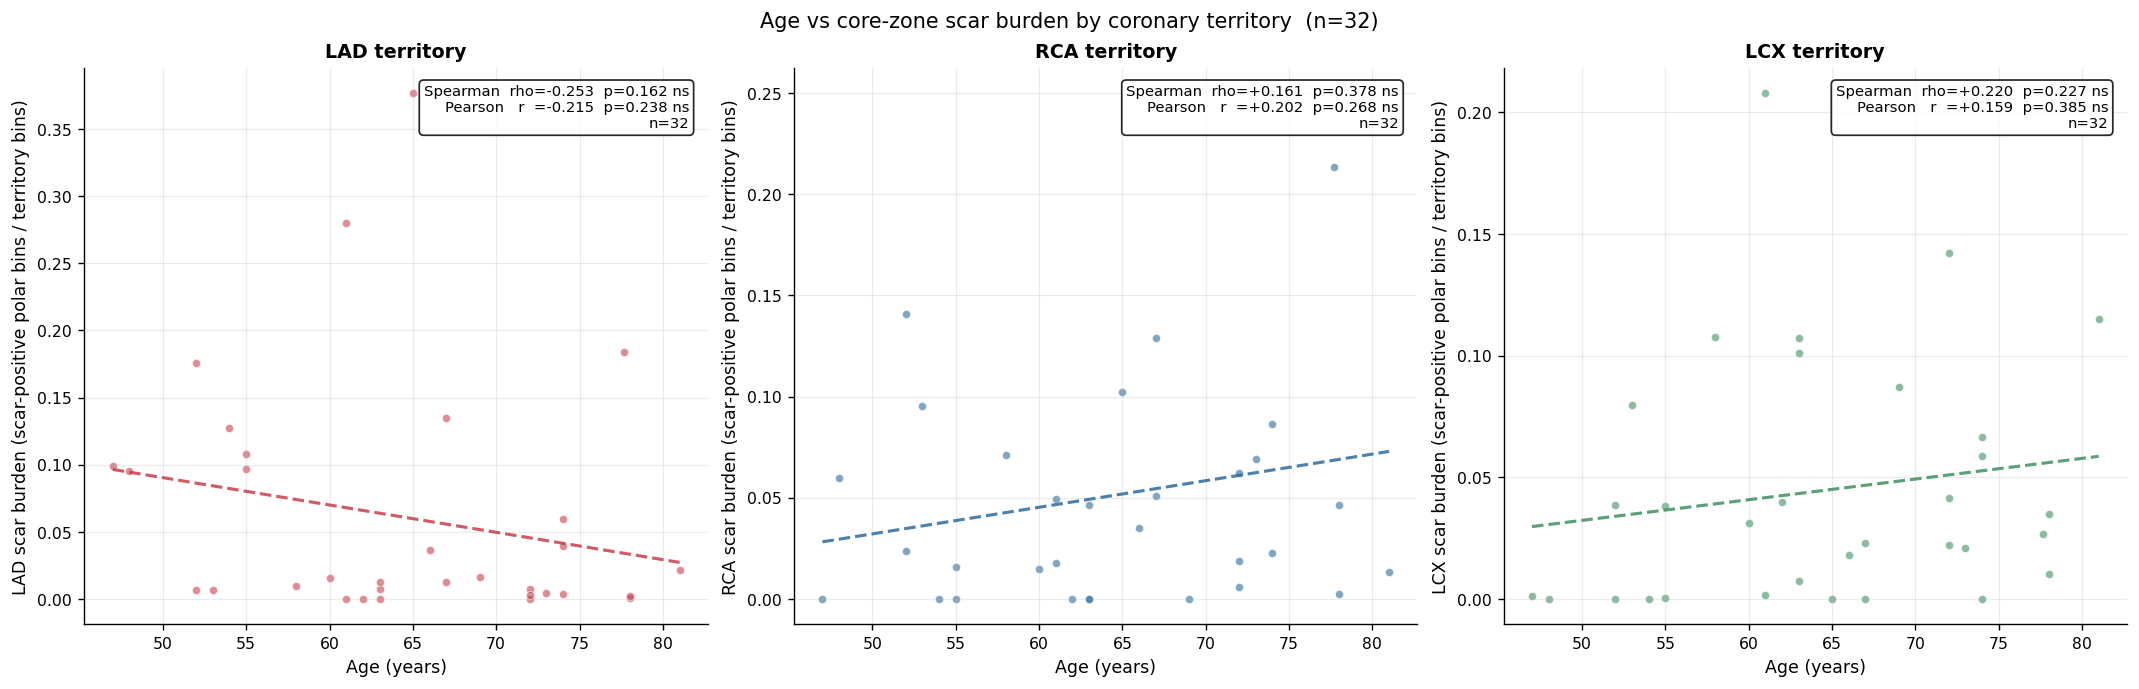

Saved age_territory_correlation.png


In [15]:
df_age = df.dropna(subset=['age'])
print(f'Patients with age data: {len(df_age)}')

fig, axes_age = plt.subplots(1, 3, figsize=(17, 5.4), constrained_layout=True)
fig.suptitle(
    f'Age vs core-zone scar burden by coronary territory  (n={len(df_age)})',
    fontsize=12,
)

for ax, terr in zip(axes_age, ('LAD', 'RCA', 'LCX')):
    sub = df_age[['age', terr]].dropna()
    rho_s, p_s  = spearmanr(sub['age'], sub[terr])
    rho_p, p_p  = pearsonr(sub['age'], sub[terr])
    color = TERR_COLORS[terr]

    ax.scatter(sub['age'], sub[terr], alpha=0.6, s=22, color=color,
               edgecolors='white', linewidth=0.5)

    m, b = np.polyfit(sub['age'], sub[terr], 1)
    x_l  = np.linspace(sub['age'].min(), sub['age'].max(), 100)
    ax.plot(x_l, m * x_l + b, color=color, lw=1.8, alpha=0.85, ls='--')

    ax.set_xlabel('Age (years)')
    ax.set_ylabel(f'{terr} scar burden (scar-positive polar bins / territory bins)')
    ax.set_title(f'{terr} territory')
    sig_s = '**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns')
    sig_p = '**' if p_p < 0.01 else ('*' if p_p < 0.05 else 'ns')
    ax.text(0.97, 0.97,
            f'Spearman  rho={rho_s:+.3f}  p={p_s:.3f} {sig_s}\n'
            f'Pearson   r  ={rho_p:+.3f}  p={p_p:.3f} {sig_p}\n'
            f'n={len(sub)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.grid(alpha=0.25)

plt.savefig(OUT / 'age_territory_correlation.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved age_territory_correlation.png')


INSIHGT: NON SIGNIFICANT


#### 3.7.1 Age vs Total Scar and Multi-Territory Involvement


C:\Users\joan\AppData\Local\Temp\ipykernel_14064\2016208811.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ninv.boxplot(data_grp,


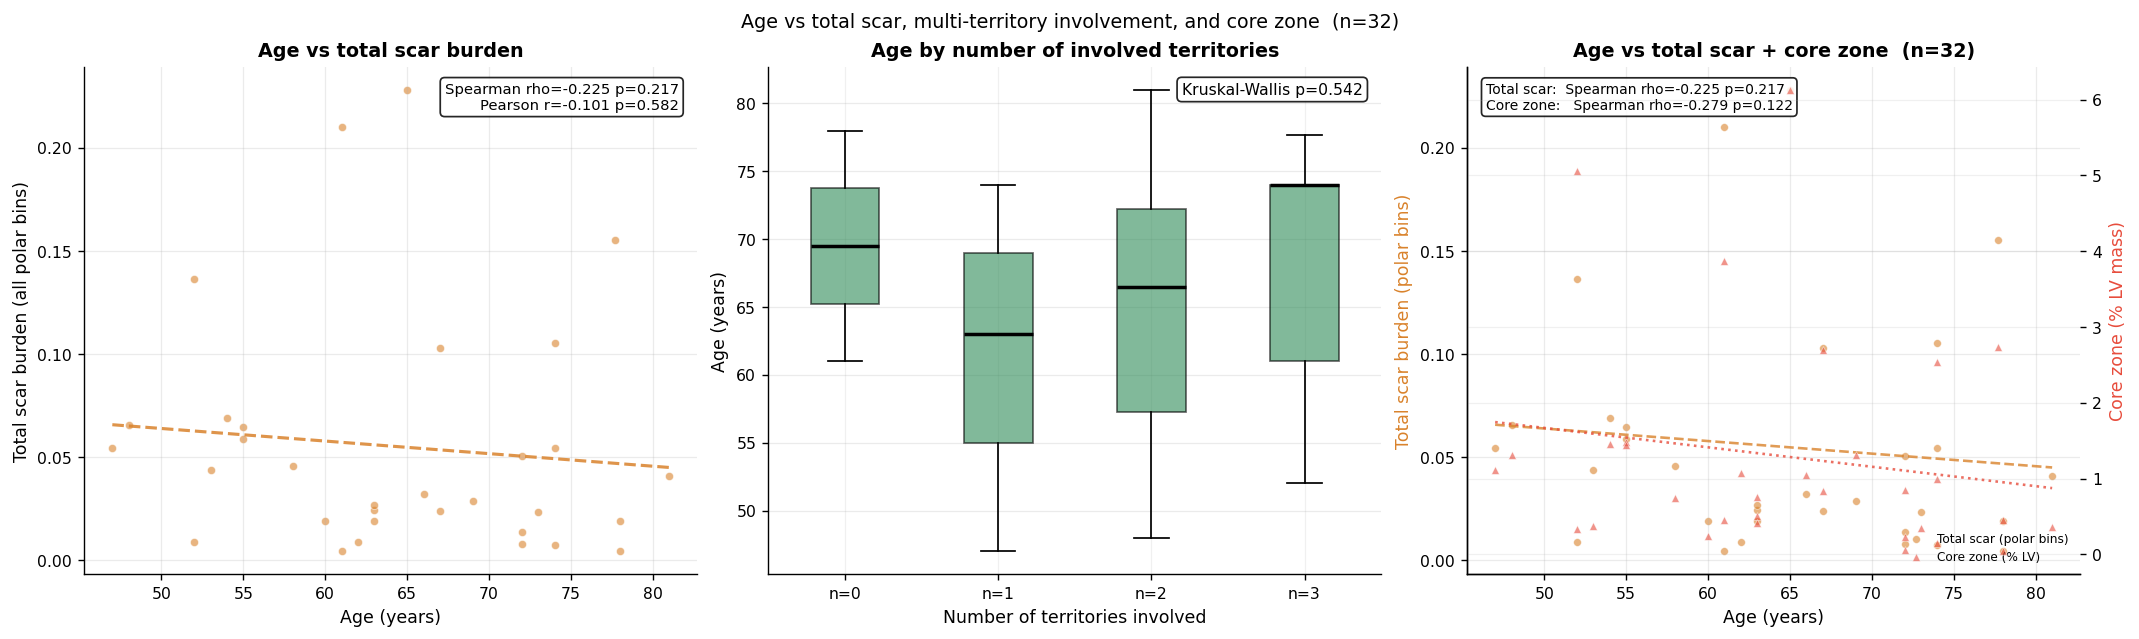

Saved age_total_scar.png


In [16]:
fig, axes_62 = plt.subplots(1, 3, figsize=(17, 5.0), constrained_layout=True)
fig.suptitle(f'Age vs total scar, multi-territory involvement, and core zone  (n={len(df_age)})',
             fontsize=11)

# Panel 1: age vs total scar
ax_tot = axes_62[0]
sub_tot = df_age[['age', 'total_scar']].dropna()
rho_t, p_t   = spearmanr(sub_tot['age'], sub_tot['total_scar'])
rho_tp, p_tp = pearsonr(sub_tot['age'], sub_tot['total_scar'])
ax_tot.scatter(sub_tot['age'], sub_tot['total_scar'], alpha=0.6, s=22,
               color=NOTEBOOK_PALETTE['secondary'], edgecolors='white', linewidth=0.5)
m, b = np.polyfit(sub_tot['age'], sub_tot['total_scar'], 1)
x_l  = np.linspace(sub_tot['age'].min(), sub_tot['age'].max(), 100)
ax_tot.plot(x_l, m * x_l + b, color=NOTEBOOK_PALETTE['secondary'], lw=1.8, ls='--', alpha=0.85)
ax_tot.set_xlabel('Age (years)')
ax_tot.set_ylabel('Total scar burden (all polar bins)')
ax_tot.set_title('Age vs total scar burden')
ax_tot.text(0.97, 0.97,
            f'Spearman rho={rho_t:+.3f} p={p_t:.3f}\nPearson r={rho_tp:+.3f} p={p_tp:.3f}',
            transform=ax_tot.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax_tot.grid(alpha=0.25)

# Panel 2: age by number of territories involved (boxplot + Kruskal-Wallis)
ax_ninv = axes_62[1]
sub_ninv = df_age[['age', 'n_involved']].dropna()
groups   = sorted(sub_ninv['n_involved'].unique())
data_grp = [sub_ninv.loc[sub_ninv['n_involved'] == g, 'age'].values for g in groups]
ax_ninv.boxplot(data_grp,
                labels=[f'n={int(g)}' for g in groups],
                patch_artist=True, medianprops=dict(color='black', lw=2),
                boxprops=dict(facecolor=NOTEBOOK_PALETTE['accent'], alpha=0.6))
if len(data_grp) >= 2:
    _, p_kw2 = kruskal(*data_grp)
    ax_ninv.text(0.97, 0.97, f'Kruskal-Wallis p={p_kw2:.3f}',
                 transform=ax_ninv.transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax_ninv.set_xlabel('Number of territories involved')
ax_ninv.set_ylabel('Age (years)')
ax_ninv.set_title('Age by number of involved territories')
ax_ninv.grid(axis='y', alpha=0.25)

# Panel 3: total scar (polar bins) + core zone (% LV) vs age – dual axis
ax_cz = axes_62[2]
sub_cz = df_age[['age', 'total_scar', 'core_pct']].dropna(subset=['age', 'core_pct'])
if len(sub_cz) >= 5:
    ax_cz2 = ax_cz.twinx()
    ln1 = ax_cz.scatter(sub_cz['age'], sub_cz['total_scar'], alpha=0.6, s=20,
                        color=NOTEBOOK_PALETTE['secondary'], edgecolors='white', linewidth=0.4,
                        label='Total scar (polar bins)')
    ln2 = ax_cz2.scatter(sub_cz['age'], sub_cz['core_pct'], alpha=0.6, s=20,
                         marker='^', color='#e74c3c', edgecolors='white', linewidth=0.4,
                         label='Core zone (% LV)')
    m1, b1 = np.polyfit(sub_cz['age'], sub_cz['total_scar'], 1)
    m2, b2 = np.polyfit(sub_cz['age'], sub_cz['core_pct'],   1)
    x_cz   = np.linspace(sub_cz['age'].min(), sub_cz['age'].max(), 100)
    ax_cz.plot(x_cz,  m1 * x_cz + b1, color=NOTEBOOK_PALETTE['secondary'], lw=1.5, ls='--', alpha=0.8)
    ax_cz2.plot(x_cz, m2 * x_cz + b2, color='#e74c3c', lw=1.5, ls=':',  alpha=0.8)
    rho_cz1, p_cz1 = spearmanr(sub_cz['age'], sub_cz['total_scar'])
    rho_cz2, p_cz2 = spearmanr(sub_cz['age'], sub_cz['core_pct'])
    ax_cz.set_xlabel('Age (years)')
    ax_cz.set_ylabel('Total scar burden (polar bins)', color=NOTEBOOK_PALETTE['secondary'])
    ax_cz2.set_ylabel('Core zone (% LV mass)', color='#e74c3c')
    ax_cz.set_title(f'Age vs total scar + core zone  (n={len(sub_cz)})')
    ax_cz.text(0.03, 0.97,
               f'Total scar:  Spearman rho={rho_cz1:+.3f} p={p_cz1:.3f}\n'
               f'Core zone:   Spearman rho={rho_cz2:+.3f} p={p_cz2:.3f}',
               transform=ax_cz.transAxes, ha='left', va='top', fontsize=8,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax_cz.legend([ln1, ln2], [ln1.get_label(), ln2.get_label()],
                 loc='lower right', fontsize=7)
    ax_cz.grid(alpha=0.25)
else:
    sub_fb = df_age[['age', 'total_scar']].dropna()
    rho_f, p_f = spearmanr(sub_fb['age'], sub_fb['total_scar'])
    ax_cz.scatter(sub_fb['age'], sub_fb['total_scar'], alpha=0.6, s=22, color=NOTEBOOK_PALETTE['secondary'])
    ax_cz.set_title('Age vs total scar (core_pct unavailable)')
    ax_cz.text(0.97, 0.97, f'Spearman rho={rho_f:+.3f} p={p_f:.3f}',
               transform=ax_cz.transAxes, ha='right', va='top', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax_cz.grid(alpha=0.25)

plt.savefig(OUT / 'age_total_scar.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved age_total_scar.png')


INSIGHT: NON SIGNIFICANT


#### 3.7.2 Age Correlations - Core Zone Clinical Scalars


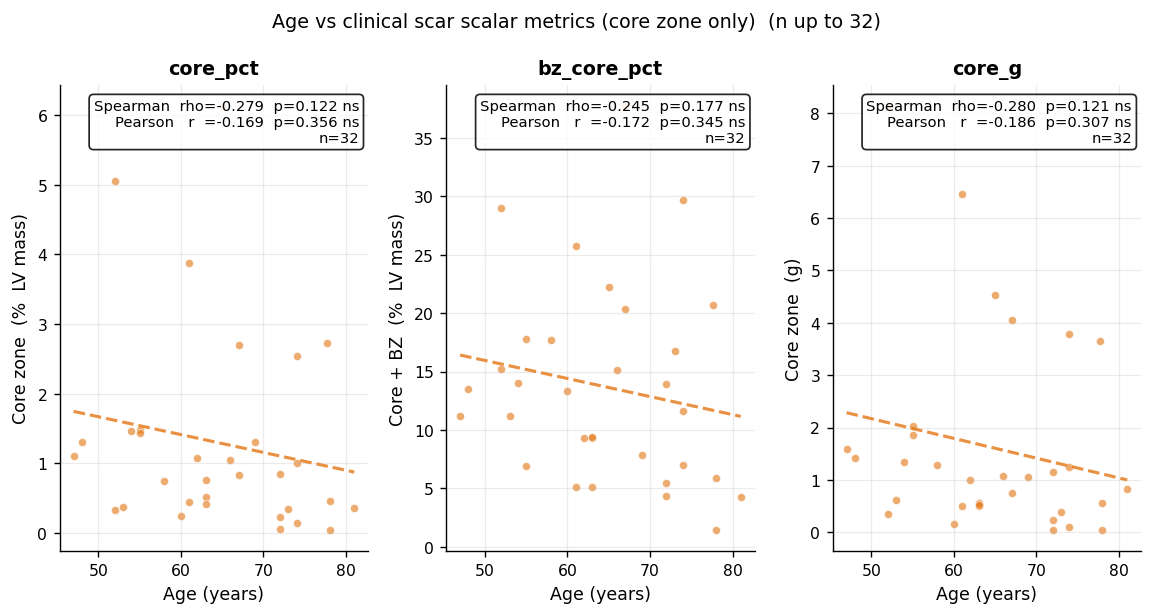

Saved age_core_zone_clinical.png


In [17]:
_scar_cols  = ['core_pct', 'bz_core_pct', 'core_g']
_scar_ylbls = [
    'Core zone  (%  LV mass)',
    'Core + BZ  (%  LV mass)',
    'Core zone  (g)',
]
_scar_cols_avail = [c for c in _scar_cols if df['age'].notna().any() and df[c].notna().any()]

if not _scar_cols_avail:
    print('No clinical scar scalar data available.')
else:
    fig, axes_cz = plt.subplots(1, len(_scar_cols_avail),
                                figsize=(3.12 * len(_scar_cols_avail), 5))
    if len(_scar_cols_avail) == 1:
        axes_cz = [axes_cz]
    fig.suptitle(
        f'Age vs clinical scar scalar metrics (core zone only)  (n up to {len(df_age)})',
        fontsize=11,
    )

    for ax, col, ylabel in zip(axes_cz, _scar_cols_avail,
                                [_scar_ylbls[_scar_cols.index(c)] for c in _scar_cols_avail]):
        sub_cz = df_age[['age', col]].dropna()
        if len(sub_cz) < 5:
            ax.set_title(f'{col}\n(insufficient data n={len(sub_cz)})')
            ax.axis('off')
            continue

        rho_s, p_s = spearmanr(sub_cz['age'], sub_cz[col])
        rho_p, p_p = pearsonr(sub_cz['age'], sub_cz[col])

        ax.scatter(sub_cz['age'], sub_cz[col], alpha=0.65, s=22,
                   color='#e67e22', edgecolors='white', linewidth=0.5)
        m, b = np.polyfit(sub_cz['age'], sub_cz[col], 1)
        x_l  = np.linspace(sub_cz['age'].min(), sub_cz['age'].max(), 100)
        ax.plot(x_l, m * x_l + b, color='#e67e22', lw=1.8, ls='--', alpha=0.85)

        ax.set_xlabel('Age (years)')
        ax.set_ylabel(ylabel)
        ax.set_title(col)
        sig_s = '**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns')
        sig_p = '**' if p_p < 0.01 else ('*' if p_p < 0.05 else 'ns')
        ax.text(0.97, 0.97,
                f'Spearman  rho={rho_s:+.3f}  p={p_s:.3f} {sig_s}\n'
                f'Pearson   r  ={rho_p:+.3f}  p={p_p:.3f} {sig_p}\n'
                f'n={len(sub_cz)}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(OUT / 'age_core_zone_clinical.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved age_core_zone_clinical.png')


INSIGHT: NON SIGNIFICANT


### 3.8 Inter-Segment Correlation Structure

Computes the 17×17 Spearman rank-correlation matrix across all 84 patients. High within-territory correlations reveal redundancy: neighbouring segments carry similar information for retrieval so may need fewer independent features. The block structure tests whether coronary anatomy (LAD/RCA/LCX) drives the dependency pattern.


Saved inter_segment_correlation_matrix.csv


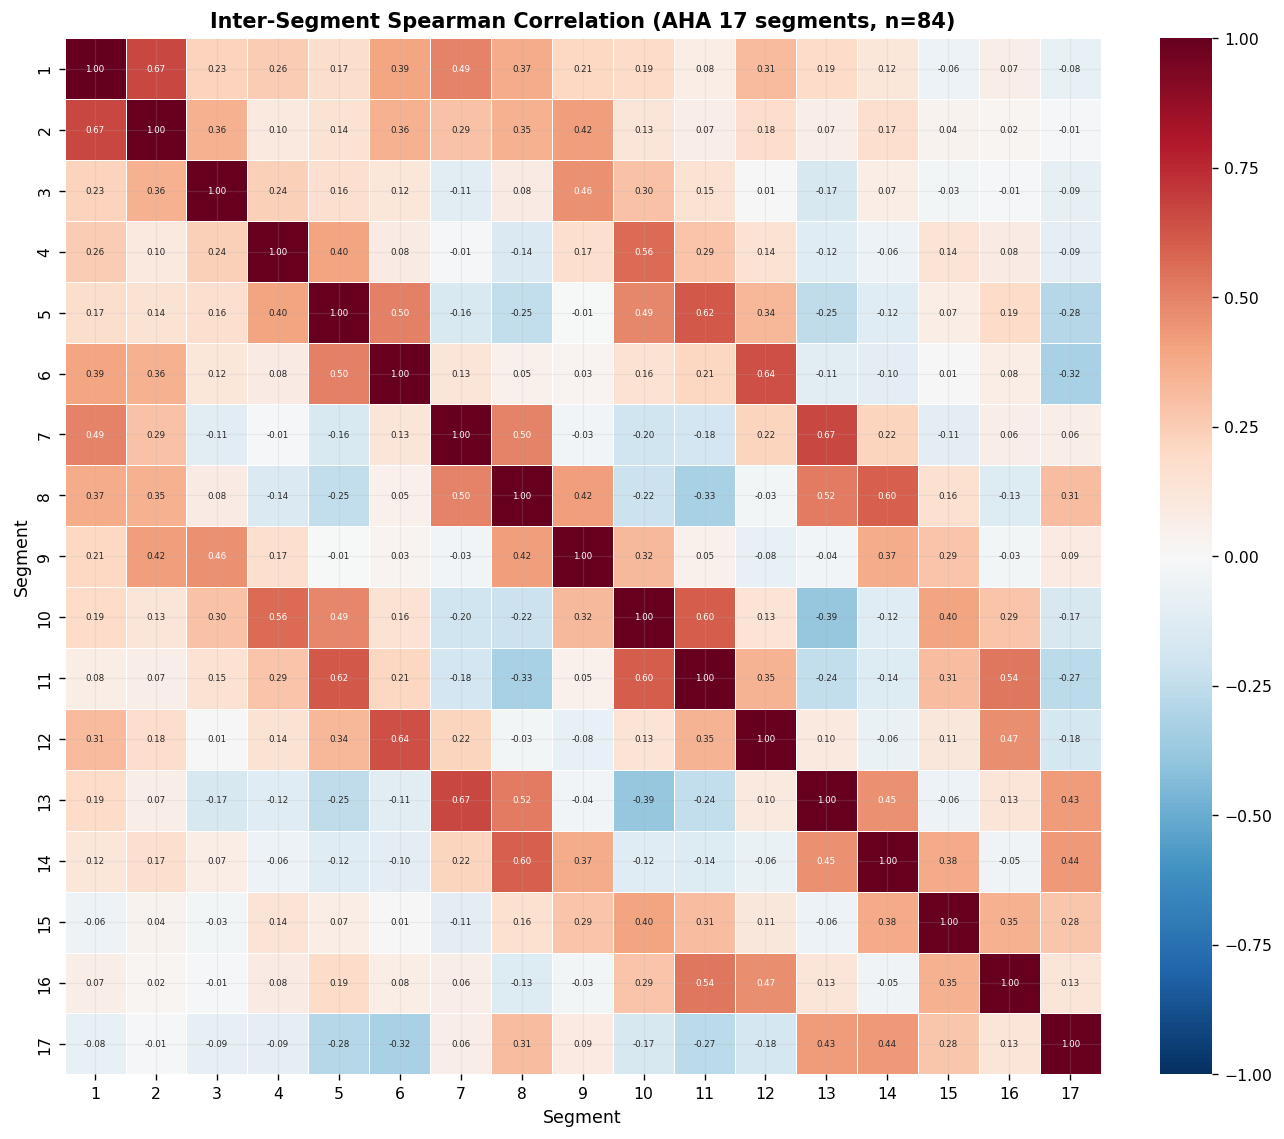

Saved inter_segment_correlation_heatmap.png

Mean within-block Spearman correlations:


T2,LAD,RCA,LCX
T1,,,
LAD,1.000,0.045,-0.017
RCA,0.045,1.000,0.156
LCX,-0.017,0.156,1.000


Saved territory_block_mean_correlations.csv


In [18]:
import seaborn as sns

# --- 17×17 Spearman correlation matrix ---
_corr_df = seg_df[SEG_COLS].corr(method='spearman')
_corr_df.index   = range(1, 18)
_corr_df.columns = range(1, 18)

_corr_df.to_csv(OUT / 'inter_segment_correlation_matrix.csv')
print('Saved inter_segment_correlation_matrix.csv')

fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
sns.heatmap(
    _corr_df, ax=ax,
    cmap='RdBu_r', vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'fontsize': 5},
    xticklabels=range(1, 18), yticklabels=range(1, 18),
    square=True, linewidths=0.3,
)
ax.set_title('Inter-Segment Spearman Correlation (AHA 17 segments, n=84)', fontsize=12)
ax.set_xlabel('Segment')
ax.set_ylabel('Segment')
plt.savefig(OUT / 'inter_segment_correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved inter_segment_correlation_heatmap.png')

# --- Mean within-block correlation per territory pair ---
_rho_mat = _corr_df.to_numpy()
_seg_idx  = {s: i for i, s in enumerate(SEGMENTS)}
_terr_keys = ['LAD', 'RCA', 'LCX']

_block_rows = []
for _t1 in _terr_keys:
    for _t2 in _terr_keys:
        _idx1 = [_seg_idx[s] for s in TERRITORY[_t1]]
        _idx2 = [_seg_idx[s] for s in TERRITORY[_t2]]
        _vals = [
            _rho_mat[_i, _j]
            for _i in _idx1 for _j in _idx2
            if not (_t1 == _t2 and _i == _j)
        ]
        _block_rows.append({
            'T1': _t1,
            'T2': _t2,
            'mean_rho': float(np.mean(_vals)) if _vals else np.nan,
        })

_block_df = pd.DataFrame(_block_rows).pivot(index='T1', columns='T2', values='mean_rho')
_block_df = _block_df.loc[_terr_keys, _terr_keys]

# Display as a correlation-style matrix: diagonal shown as 1.0.
_block_display = _block_df.copy()
for _terr in _terr_keys:
    _block_display.loc[_terr, _terr] = 1.0

print('\nMean within-block Spearman correlations:')
display(_block_display.round(3))

# Save the actual off-diagonal within-block means.
_block_df.to_csv(OUT / 'territory_block_mean_correlations.csv')
print('Saved territory_block_mean_correlations.csv')

In [19]:
# Initialise characterisation dataframe — features added in 6.1–6.4
char_df = df[['key', 'pid']].copy().reset_index(drop=True)
print(f'char_df initialised: {len(char_df)} patients')


char_df initialised: 84 patients


## Section 4 - Characterization

Characterization describes the scar phenotype itself: where scar is, how variable it is, what dominant spatial patterns exist, how vertex-based and area-based descriptors behave, and how scar extends through the wall.


### 4.1 Population Scar Atlas

The atlas maps the average scar burden per AHA segment across patients. Bootstrap confidence intervals are used because scar burden is bounded, sparse, and non-normal.

Patient-level bootstrap means: each resample has the same size as the cohort, but patients are sampled with replacement. After 2000 resamples, the 2.5th and 97.5th percentiles form the 95% confidence interval around the estimated population mean.


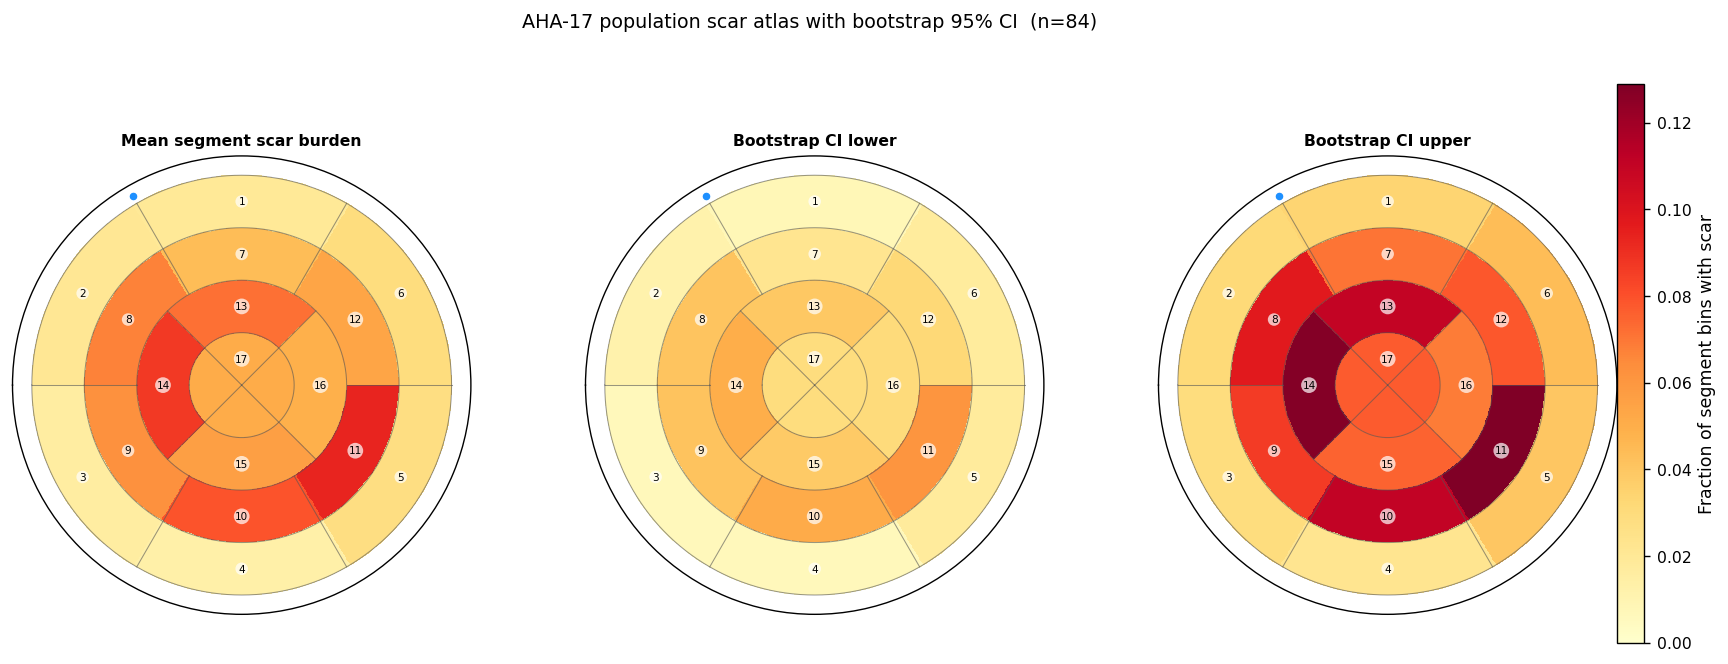

Saved aha17_population_scar_atlas_bootstrap_ci.png


,group_type,group,mean_scar_prevalence
0,ring,Apex,0.050921
1,ring,Apical,0.066057
2,ring,Mid,0.066732
3,ring,Basal,0.021176
4,territory,LAD,0.053384
5,territory,RCA,0.046635
6,territory,LCX,0.050704
7,overall,all_bins,0.051222
8,overall,scar_positive_bins_per_patient_mean,419.607143


Saved population_scar_atlas_numeric_summary.csv


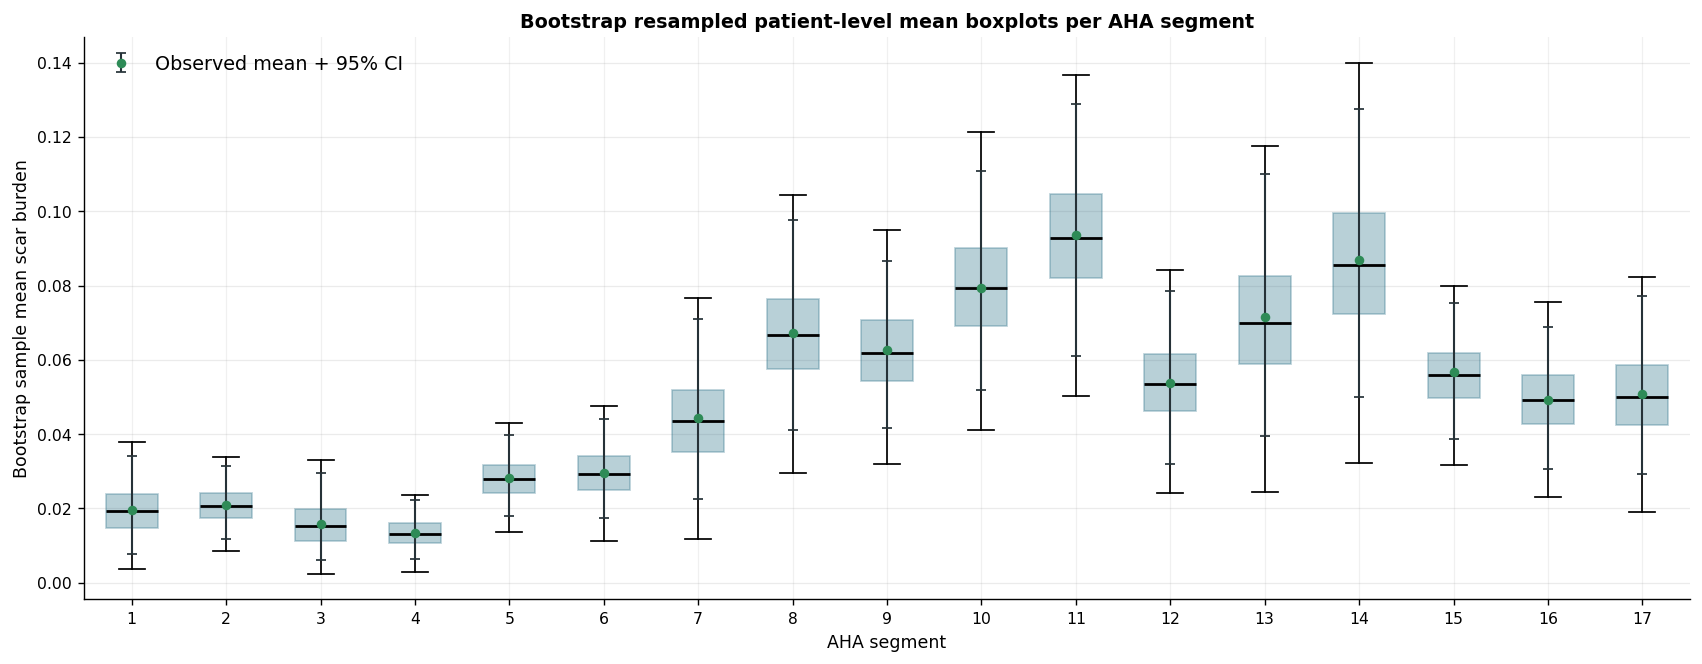

Saved aha17_bootstrap_sample_distributions.png and aha17_bootstrap_sample_means.csv


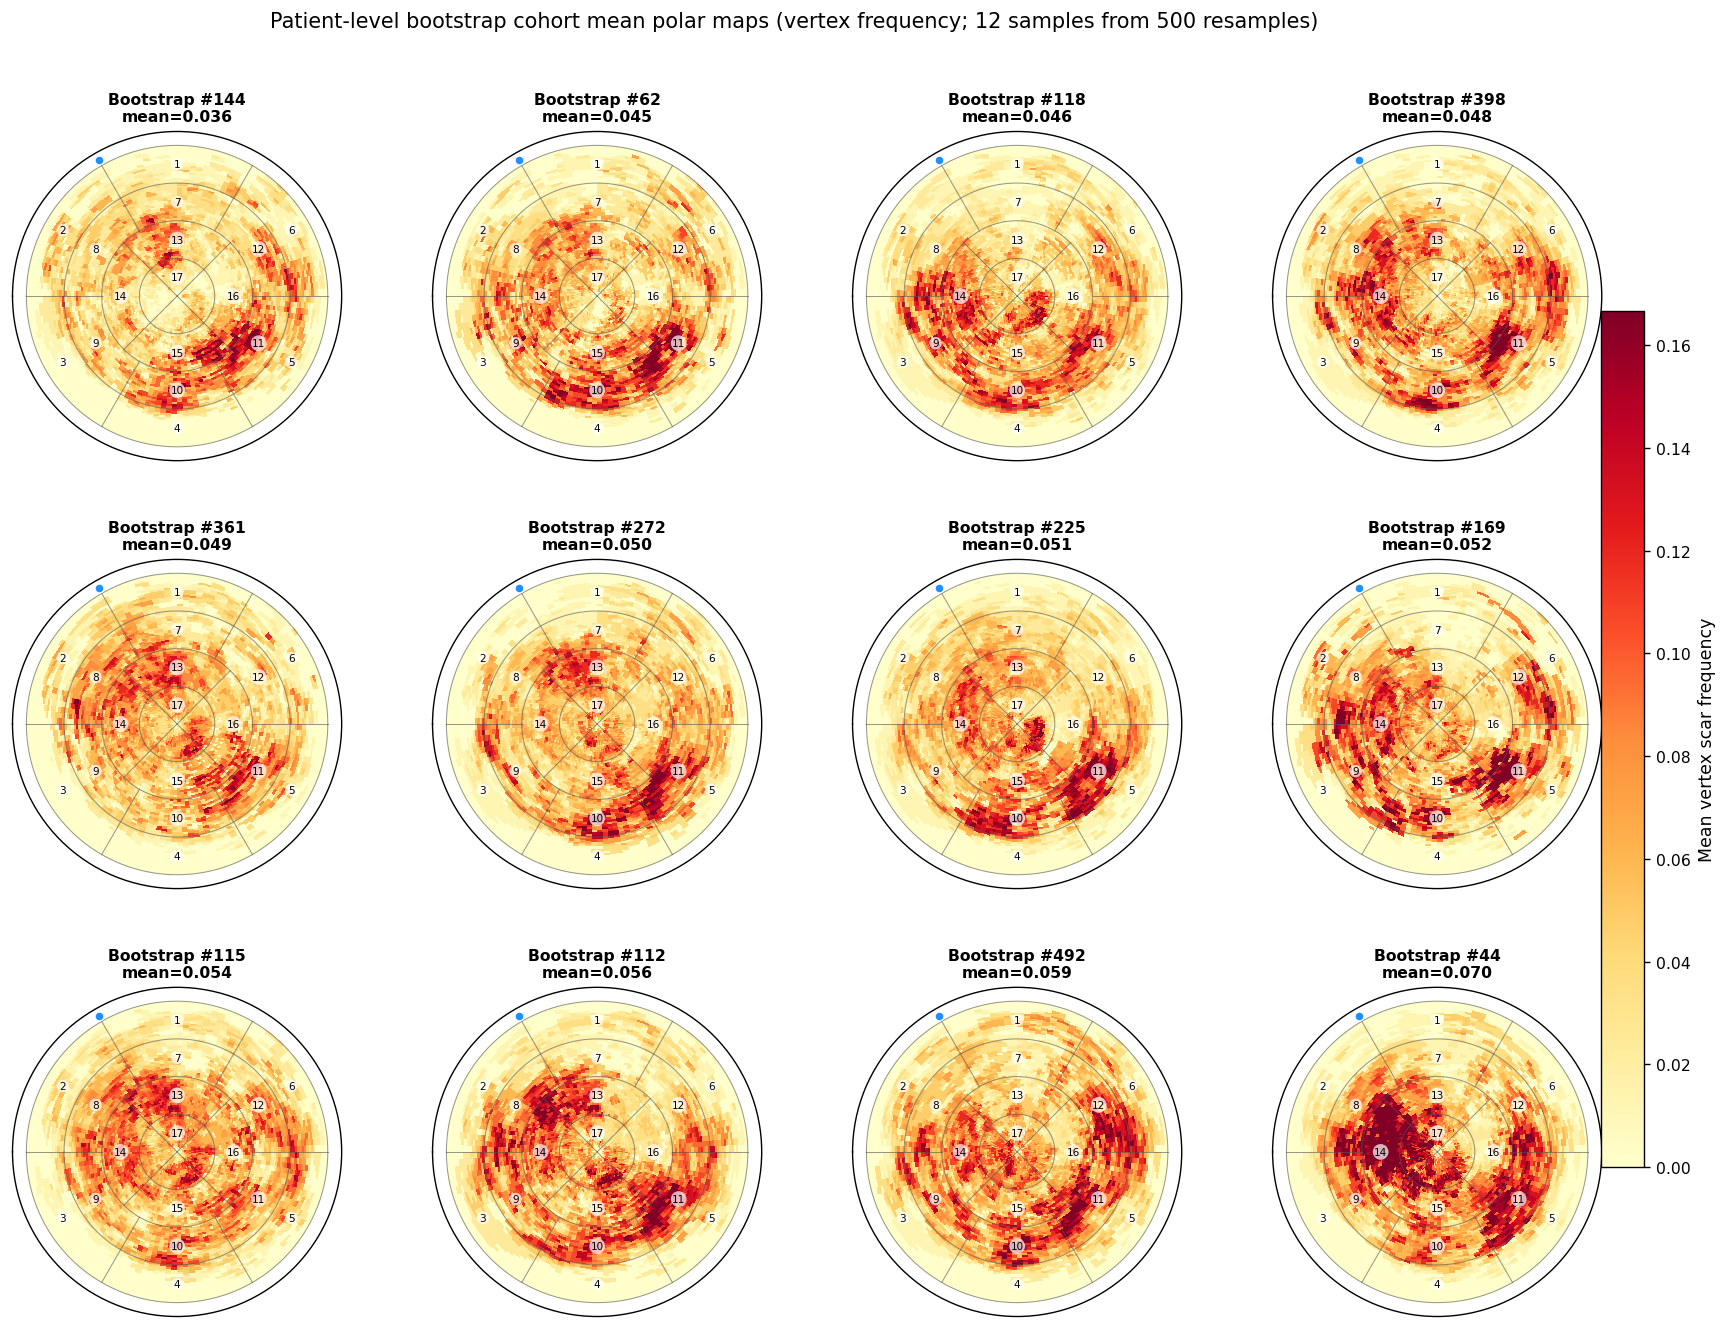

Saved aha17_bootstrap_sample_polar_maps.png


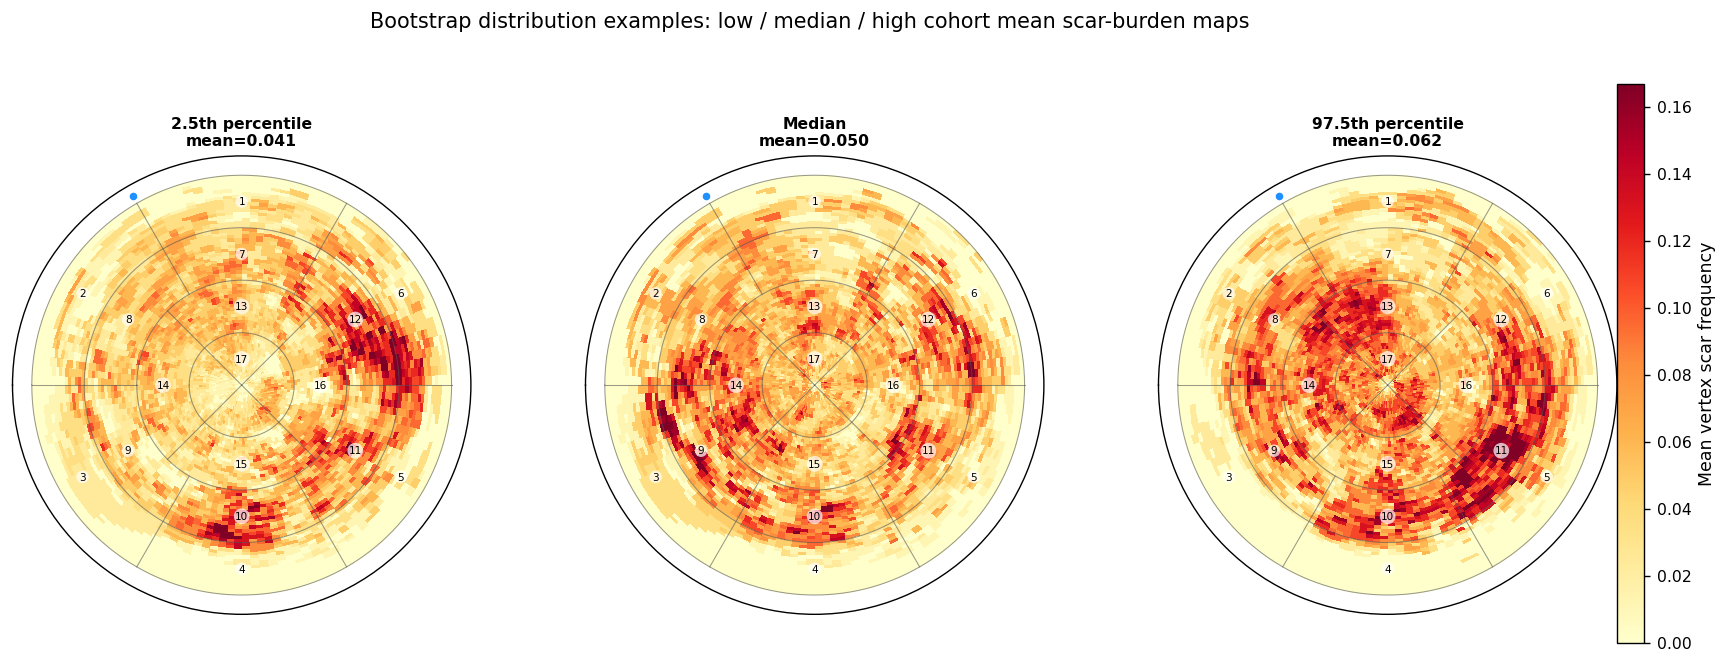

Saved aha17_bootstrap_percentile_polar_maps.png


In [20]:
bootstrap_samples = scar_analysis.bootstrap_samples
bootstrap_ci = scar_analysis.bootstrap_ci

rng_boot = np.random.default_rng(42)
seg_boot = scar_analysis.bootstrap_region_ci(
    seg_df,
    SEG_COLS,
    labels=SEGMENTS,
    value_name='mean_extent',
    n_boot=2000,
    rng=rng_boot,
).rename(columns={'region': 'segment'})
seg_boot_samples = {
    seg: bootstrap_samples(seg_df[col].to_numpy(dtype=float), np.nanmean, n_boot=2000, rng=np.random.default_rng(42 + seg))
    for seg, col in zip(SEGMENTS, SEG_COLS)
}
seg_summary = seg_summary.merge(seg_boot, on='segment', how='left')

atlas_grid = np.zeros_like(AHA_GRID, dtype=float)
ci_low_grid = np.zeros_like(AHA_GRID, dtype=float)
ci_high_grid = np.zeros_like(AHA_GRID, dtype=float)
for _, row in seg_boot.iterrows():
    mask = (AHA_GRID == int(row['segment']))
    atlas_grid[mask] = row['mean_extent']
    ci_low_grid[mask] = row['ci95_low']
    ci_high_grid[mask] = row['ci95_high']

fig_atlas, axes_atlas = plt.subplots(1, 3, figsize=(17, 5.8), subplot_kw={'projection': 'polar'})
fig_atlas.suptitle(f'AHA-17 population scar atlas with bootstrap 95% CI  (n={len(seg_df)})', fontsize=11)
vmax_atlas = max(float(np.nanmax(ci_high_grid)), 1e-9)
for ax, arr, title in zip(
    axes_atlas,
    [atlas_grid, ci_low_grid, ci_high_grid],
    ['Mean segment scar burden', 'Bootstrap CI lower', 'Bootstrap CI upper'],
):
    m = draw_bullseye_m04(arr, ax, title=title, cmap=SCAR_CMAP, vmax=vmax_atlas, label_segs=True)
plt.colorbar(m, ax=axes_atlas, fraction=0.026, pad=0.08, label='Fraction of segment bins with scar')
fig_atlas.subplots_adjust(top=0.82, right=0.88, wspace=0.25)
plt.savefig(OUT / 'aha17_population_scar_atlas_bootstrap_ci.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved aha17_population_scar_atlas_bootstrap_ci.png')

_rc_ring = (np.arange(N_R) + 0.5) / N_R
ring_atlas_rows = []
for _ring, (_lo, _hi) in RING_ZONES.items():
    _mask = np.broadcast_to(((_rc_ring >= _lo) & (_rc_ring < _hi))[:, None], (N_R, N_THETA))
    ring_atlas_rows.append({'group_type': 'ring', 'group': _ring, 'mean_scar_prevalence': float(np.nanmean(atlas_grid[_mask]))})
terr_atlas_rows = [{'group_type': 'territory', 'group': _t, 'mean_scar_prevalence': float(np.nanmean(atlas_grid[TERRITORY_GRID == _t]))} for _t in TERRITORY]
atlas_numeric_summary = pd.DataFrame(ring_atlas_rows + terr_atlas_rows + [
    {'group_type': 'overall', 'group': 'all_bins', 'mean_scar_prevalence': float(np.nanmean(atlas_grid))},
    {'group_type': 'overall', 'group': 'scar_positive_bins_per_patient_mean', 'mean_scar_prevalence': float(np.mean([np.asarray(pmaps[k], dtype=bool).sum() for k in pmaps]))},
])
display(atlas_numeric_summary)
atlas_numeric_summary.to_csv(OUT / 'population_scar_atlas_numeric_summary.csv', index=False)
print('Saved population_scar_atlas_numeric_summary.csv')


boot_sample_df = pd.DataFrame({f'seg_{seg:02d}': vals for seg, vals in seg_boot_samples.items()})
fig_boot, ax_boot = plt.subplots(figsize=(13.5, 5.2), constrained_layout=True)
_box_data = [np.asarray(seg_boot_samples[seg], dtype=float) for seg in SEGMENTS]
bp = ax_boot.boxplot(_box_data, positions=SEGMENTS, widths=0.55, patch_artist=True,
                     showfliers=False, medianprops=dict(color='black', lw=1.6),
                     boxprops=dict(linewidth=1.0), whiskerprops=dict(linewidth=1.0),
                     capprops=dict(linewidth=1.0))
for patch in bp['boxes']:
    patch.set_facecolor(NOTEBOOK_PALETTE['primary'])
    patch.set_alpha(0.32)
    patch.set_edgecolor(NOTEBOOK_PALETTE['primary'])

# Observed mean and 95% bootstrap CI are overlaid on top of the boxplots.
ax_boot.errorbar(seg_boot['segment'], seg_boot['mean_extent'],
                 yerr=[seg_boot['mean_extent'] - seg_boot['ci95_low'],
                       seg_boot['ci95_high'] - seg_boot['mean_extent']],
                 fmt='o', color=NOTEBOOK_PALETTE['accent'],
                 ecolor=NOTEBOOK_PALETTE['neutral'], elinewidth=1.2,
                 capsize=3, markersize=4.5, label='Observed mean + 95% CI')
ax_boot.set_xticks(SEGMENTS)
ax_boot.set_xlabel('AHA segment')
ax_boot.set_ylabel('Bootstrap sample mean scar burden')
ax_boot.set_title('Bootstrap resampled patient-level mean boxplots per AHA segment')
ax_boot.grid(axis='y', alpha=0.25)
ax_boot.legend(frameon=False)
plt.savefig(OUT / 'aha17_bootstrap_sample_distributions.png', bbox_inches='tight', dpi=300)
plt.show()
boot_sample_df.to_csv(OUT / 'aha17_bootstrap_sample_means.csv', index=False)
print('Saved aha17_bootstrap_sample_distributions.png and aha17_bootstrap_sample_means.csv')

# Patient-level bootstrap polar-map samples: each panel is one resampled cohort mean scar-burden map.
_boot_map_rng = np.random.default_rng(123)
_boot_map_n = 500
_pmap_keys_boot = list(pmaps.keys()) if 'pmaps' in globals() else []
if _pmap_keys_boot:
    _pmap_stack_boot = np.stack([np.asarray(pmaps[k], dtype=float) for k in _pmap_keys_boot], axis=0)
    _boot_idx = _boot_map_rng.integers(0, _pmap_stack_boot.shape[0],
                                       size=(_boot_map_n, _pmap_stack_boot.shape[0]))
    _boot_mean_maps = np.stack([_pmap_stack_boot[_idx].mean(axis=0) for _idx in _boot_idx], axis=0)
    _boot_total_mean = _boot_mean_maps.mean(axis=(1, 2))

    _sample_order = np.argsort(_boot_total_mean)
    _sample_positions = np.linspace(0, _boot_map_n - 1, 12).astype(int)
    _sample_ids = _sample_order[_sample_positions]
    _boot_maps = [(_bi, _boot_mean_maps[_bi], _boot_total_mean[_bi]) for _bi in _sample_ids]

    _positive_boot = _boot_mean_maps[np.isfinite(_boot_mean_maps) & (_boot_mean_maps > 0)]
    _vmax_boot_maps = float(np.nanpercentile(_positive_boot, 99)) if len(_positive_boot) else 1.0
    _vmax_boot_maps = max(_vmax_boot_maps, 0.05)

    fig_boot_maps, axes_boot_maps = plt.subplots(3, 4, figsize=(17, 12), subplot_kw={'projection': 'polar'})
    fig_boot_maps.suptitle(
        f'Patient-level bootstrap cohort mean polar maps (vertex frequency; 12 samples from {_boot_map_n} resamples)',
        fontsize=12,
    )
    for _ax, (_bi, _g, _tm) in zip(axes_boot_maps.ravel(), _boot_maps):
        _m = draw_bullseye_m04(_g, _ax,
                               title=f'Bootstrap #{_bi}\nmean={_tm:.3f}',
                               cmap=SCAR_CMAP, vmax=_vmax_boot_maps, label_segs=True)
    plt.colorbar(_m, ax=axes_boot_maps.ravel().tolist(), fraction=0.026, pad=0.08,
                 label='Mean vertex scar frequency')
    fig_boot_maps.subplots_adjust(top=0.90, right=0.88, wspace=0.22, hspace=0.30)
    plt.savefig(OUT / 'aha17_bootstrap_sample_polar_maps.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved aha17_bootstrap_sample_polar_maps.png')

    _summary_ids = [_sample_order[int(0.025 * (_boot_map_n - 1))],
                    _sample_order[int(0.500 * (_boot_map_n - 1))],
                    _sample_order[int(0.975 * (_boot_map_n - 1))]]
    fig_boot_q, axes_boot_q = plt.subplots(1, 3, figsize=(17, 5.8), subplot_kw={'projection': 'polar'})
    fig_boot_q.suptitle('Bootstrap distribution examples: low / median / high cohort mean scar-burden maps', fontsize=12)
    for _ax, _label, _bi in zip(axes_boot_q, ['2.5th percentile', 'Median', '97.5th percentile'], _summary_ids):
        _m = draw_bullseye_m04(_boot_mean_maps[_bi], _ax,
                               title=f'{_label}\nmean={_boot_total_mean[_bi]:.3f}',
                               cmap=SCAR_CMAP, vmax=_vmax_boot_maps, label_segs=True)
    plt.colorbar(_m, ax=axes_boot_q, fraction=0.026, pad=0.08,
                 label='Mean vertex scar frequency')
    fig_boot_q.subplots_adjust(top=0.82, right=0.88, wspace=0.25)
    plt.savefig(OUT / 'aha17_bootstrap_percentile_polar_maps.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved aha17_bootstrap_percentile_polar_maps.png')
else:
    print('No vertex polar maps available for bootstrap polar-map samples.')


### 4.2 Vertex-Based Population Mean Polar Map with Territory Overlay


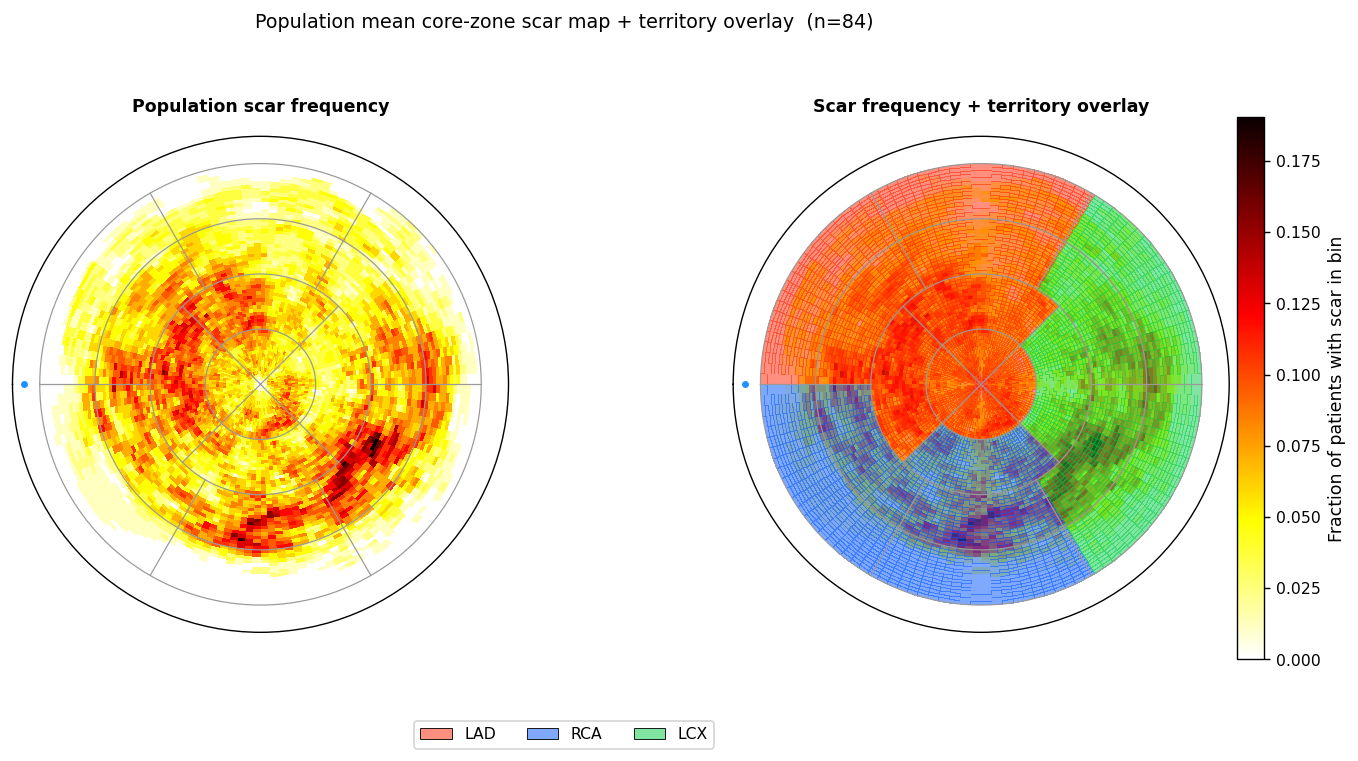

Saved population_scar_territory.png


In [21]:
if pmaps:
    pop_mean = np.stack(list(pmaps.values())).mean(axis=0)
    vmax_pm  = max(float(np.nanmax(pop_mean)), 1e-9)

    # Vivid, clearly distinct territory overlay colors
    OVERLAY_COLORS = {'LAD': '#ff2200', 'RCA': '#0055ff', 'LCX': '#00cc44'}
    OVERLAY_ALPHA  = 0.50

    fig, axes_pm = plt.subplots(1, 2, figsize=(14, 6.2),
                                subplot_kw={'projection': 'polar'})
    fig.suptitle(f'Population mean core-zone scar map + territory overlay  (n={len(pmaps)})',
                 fontsize=11)

    T_m, R_m = np.meshgrid(
        np.linspace(0, 2 * np.pi, N_THETA + 1),
        np.linspace(0, 1.0,       N_R + 1),
    )

    for ax_pm in axes_pm:
        mesh = ax_pm.pcolormesh(T_m, R_m, pop_mean, cmap='hot_r',
                                vmin=0, vmax=vmax_pm, shading='flat')
        t_full = np.linspace(0, 2 * np.pi, 361)
        for r_b in (0.25, 0.50, 0.75, 1.0):
            ax_pm.plot(t_full, np.full_like(t_full, r_b), color='#999', lw=0.7)
        for deg in (0, 60, 120, 180, 240, 300):
            ax_pm.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#999', lw=0.7)
        for deg in (45, 135, 225, 315):
            ax_pm.plot([np.deg2rad(deg)] * 2, [0.0, 0.5], color='#999', lw=0.7)
        ax_pm.set_theta_zero_location('W')
        ax_pm.set_theta_direction(-1)
        ax_pm.set_rticks([])
        ax_pm.set_xticks([])
        ax_pm.scatter([0.0], [1.07], s=22, color='dodgerblue',
                      edgecolor='white', linewidth=0.7, zorder=10, clip_on=False)
        for label, deg in [('ANT', 90), ('SEP', 0), ('INF', 270), ('LAT', 180)]:
            ax_pm.annotate(label, xy=(np.deg2rad(deg), 1.14), ha='center',
                           fontsize=8, color='#444', xycoords='data')

    axes_pm[0].set_title('Population scar frequency', fontsize=10, pad=14)

    # Territory overlay: distinct vivid colors at 50% alpha
    for terr, color in OVERLAY_COLORS.items():
        val_grid = (TERRITORY_GRID == terr).astype(float)
        cmap_t = mcolors.LinearSegmentedColormap.from_list(
            terr,
            [(1, 1, 1, 0.0),
             (*mcolors.to_rgb(color), OVERLAY_ALPHA)],
        )
        axes_pm[1].pcolormesh(T_m, R_m, val_grid, cmap=cmap_t,
                              vmin=0, vmax=1, shading='flat')
    axes_pm[1].set_title('Scar frequency + territory overlay', fontsize=10, pad=14)

    plt.colorbar(mesh, ax=axes_pm, orientation='vertical', fraction=0.02, pad=0.08,
                 label='Fraction of patients with scar in bin')

    legend_patches = [
        mpatches.Patch(facecolor=mcolors.to_rgba(OVERLAY_COLORS[t], alpha=OVERLAY_ALPHA),
                       edgecolor='black', linewidth=0.5, label=t)
        for t in TERRITORY
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.02))

    fig.subplots_adjust(top=0.82, bottom=0.18, right=0.88, wspace=0.20)
    plt.savefig(OUT / 'population_scar_territory.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved population_scar_territory.png')


### 4.3 Vertex-Based Ring-Level Scar Involvement


,ring,mean_burden,sd_burden,n
0,Apex (17),0.050921,0.111588,84
1,Apical (13-16),0.066057,0.086310,84
2,Mid (7-12),0.066732,0.059977,84
3,Basal (1-6),0.021176,0.028641,84


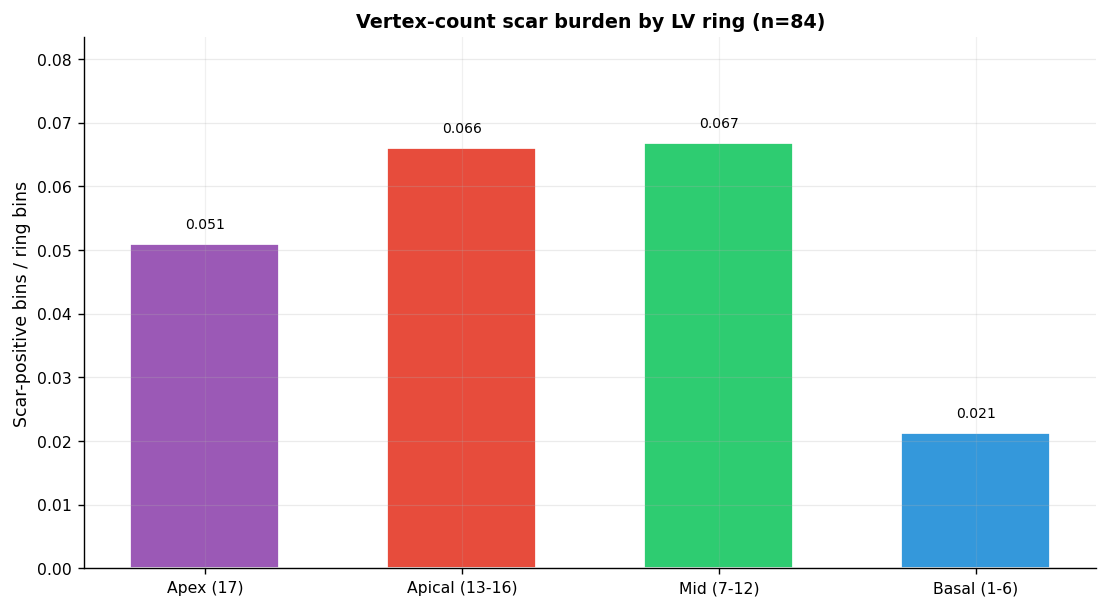

Saved vertex_ring_scar_burden.csv and vertex_ring_scar_burden.png


In [22]:
if not pmaps:
    print('No vertex polar maps available.')
else:
    _RINGS42 = [
        ('Apex (17)',       lambda r: r < 0.25,                 '#9b59b6'),
        ('Apical (13-16)',  lambda r: (r >= 0.25) & (r < 0.50), '#e74c3c'),
        ('Mid (7-12)',      lambda r: (r >= 0.50) & (r < 0.75), '#2ecc71'),
        ('Basal (1-6)',     lambda r: r >= 0.75,                '#3498db'),
    ]
    _rc42 = (np.arange(N_R) + 0.5) / N_R
    RING_GRID_VERTEX = np.full((N_R, N_THETA), '', dtype=object)
    _ring_colors = {}
    for _label, _fn, _col in _RINGS42:
        _mask_r = _fn(_rc42)
        RING_GRID_VERTEX[np.broadcast_to(_mask_r[:, None], (N_R, N_THETA))] = _label
        _ring_colors[_label] = _col

    _ring_table = scar_char.region_burden_table(
        pmaps,
        RING_GRID_VERTEX,
        [r[0] for r in _RINGS42],
        normalize_by_region_size=True,
    )
    _ring_rows = []
    for _label, _, _col in _RINGS42:
        _vals = _ring_table[_label].dropna().to_numpy(dtype=float)
        _ring_rows.append({'ring': _label, 'mean_burden': float(np.nanmean(_vals)),
                           'sd_burden': float(np.nanstd(_vals, ddof=1)), 'n': int(len(_vals)),
                           'color': _col})
    vertex_ring_summary = pd.DataFrame(_ring_rows)
    display(vertex_ring_summary.drop(columns='color'))
    vertex_ring_summary.drop(columns='color').to_csv(OUT / 'vertex_ring_scar_burden.csv', index=False)

    fig_r42, ax_r42 = plt.subplots(figsize=(9, 5))
    bars = ax_r42.bar(vertex_ring_summary['ring'], vertex_ring_summary['mean_burden'],
                      color=vertex_ring_summary['color'], edgecolor='white', width=0.58)
    _ymax = float(vertex_ring_summary['mean_burden'].max()) if len(vertex_ring_summary) else 0
    for bar, (_, row) in zip(bars, vertex_ring_summary.iterrows()):
        ax_r42.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (_ymax * 0.03 if _ymax > 0 else 0.01),
                    f"{row['mean_burden']:.3f}", ha='center', va='bottom', fontsize=8)
    ax_r42.set_title(f'Vertex-count scar burden by LV ring (n={len(_ring_table)})')
    ax_r42.set_ylabel('Scar-positive bins / ring bins')
    ax_r42.grid(axis='y', alpha=0.25)
    ax_r42.set_ylim(0, _ymax * 1.25 if _ymax > 0 else 1)
    plt.tight_layout()
    plt.savefig(OUT / 'vertex_ring_scar_burden.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved vertex_ring_scar_burden.csv and vertex_ring_scar_burden.png')


### 4.4 Bootstrap CI for Scar Burden per AHA Segment


,segment,mean_vertex_burden,ci95_low,ci95_high,label
0,1,0.019683,0.007843,0.034125,bas ant
1,2,0.020833,0.011797,0.031322,bas ant-sep
2,3,0.015873,0.006059,0.029656,bas inf-sep
3,4,0.013427,0.006494,0.022254,bas inf
4,5,0.028097,0.017997,0.039897,bas inf-lat
5,6,0.029585,0.017503,0.044118,bas ant-lat
6,7,0.044237,0.022626,0.070958,mid ant
7,8,0.067177,0.041026,0.097577,mid ant-sep
8,9,0.062571,0.041523,0.086558,mid inf-sep
9,10,0.079444,0.051811,0.110728,mid inf


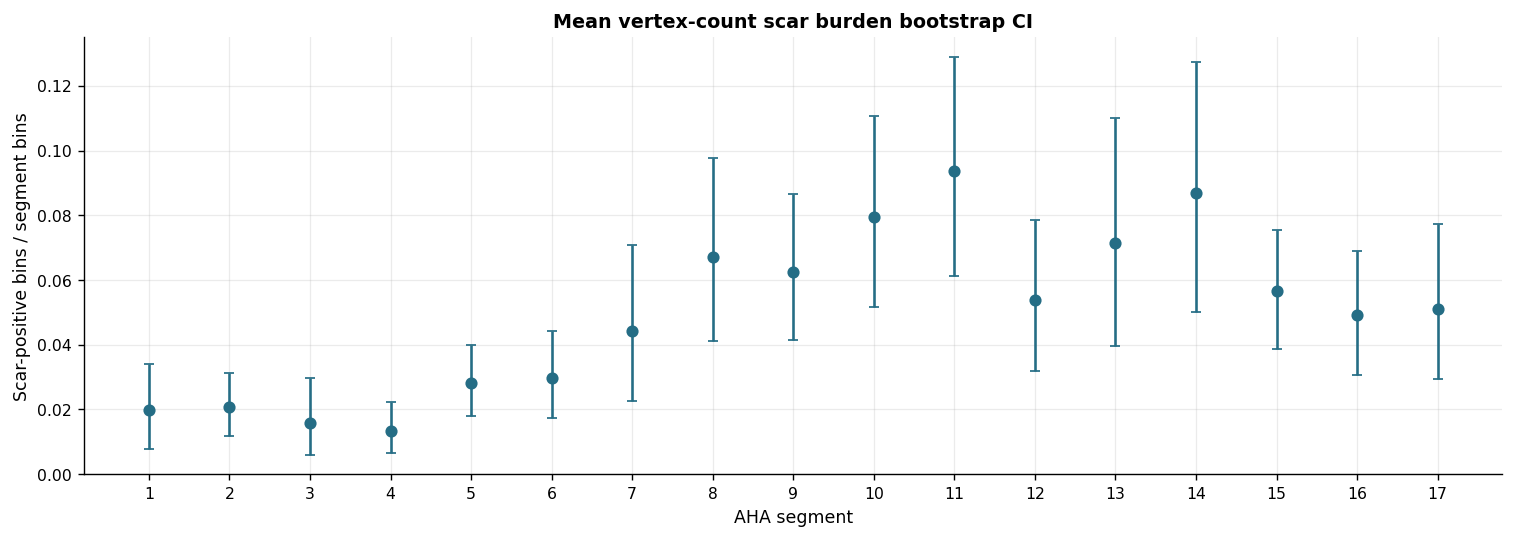

Saved vertex_bootstrap_aha17.csv and vertex_bootstrap_aha17.png


In [23]:
if 'seg_df' not in globals() or seg_df.empty:
    print('seg_df is not available. Run Section 3.2 first.')
else:
    vertex_bootstrap_aha17 = scar_analysis.bootstrap_region_ci(
        seg_df,
        SEG_COLS,
        labels=SEGMENTS,
        value_name='mean_vertex_burden',
        n_boot=2000,
        rng=np.random.default_rng(42),
    ).rename(columns={'region': 'segment'})
    vertex_bootstrap_aha17['label'] = vertex_bootstrap_aha17['segment'].map(SEG_LABELS)
    display(vertex_bootstrap_aha17)
    vertex_bootstrap_aha17.to_csv(OUT / 'vertex_bootstrap_aha17.csv', index=False)

    fig_vb, ax_vb = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
    x = np.arange(1, 18)
    ax_vb.errorbar(x, vertex_bootstrap_aha17['mean_vertex_burden'],
                   yerr=[vertex_bootstrap_aha17['mean_vertex_burden'] - vertex_bootstrap_aha17['ci95_low'],
                         vertex_bootstrap_aha17['ci95_high'] - vertex_bootstrap_aha17['mean_vertex_burden']],
                   fmt='o', color=NOTEBOOK_PALETTE['primary'], ecolor=NOTEBOOK_PALETTE['primary'], capsize=3)
    ax_vb.set_title('Mean vertex-count scar burden bootstrap CI')
    ax_vb.set_ylabel('Scar-positive bins / segment bins')
    ax_vb.set_xlabel('AHA segment')
    ax_vb.set_xticks(x)
    ax_vb.grid(alpha=0.25)
    plt.savefig(OUT / 'vertex_bootstrap_aha17.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved vertex_bootstrap_aha17.csv and vertex_bootstrap_aha17.png')


### 4.5 Vertex Count-Based Archetype Maps


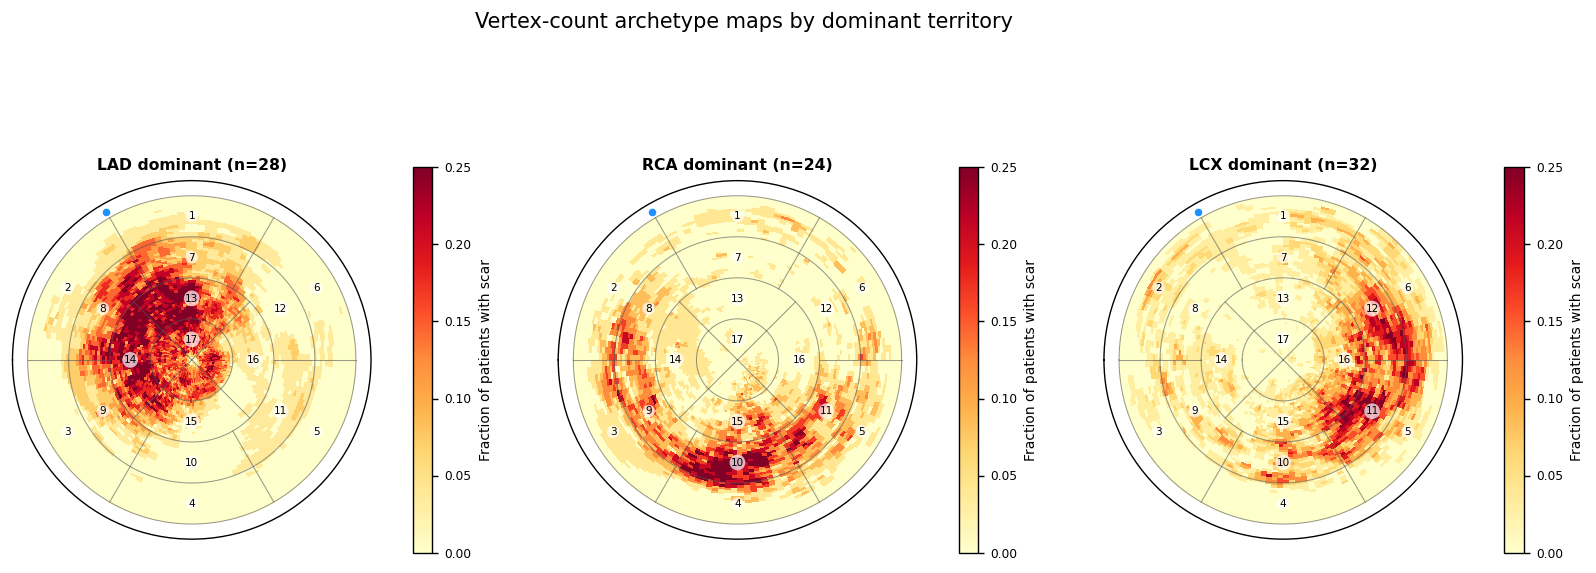

Saved vertex_archetype_maps_by_dominant_territory.png


In [24]:
if not pmaps or 'df' not in globals() or df.empty:
    print('Vertex polar maps or df are not available. Run Section 3.1 first.')
else:
    _arch_terrs = ['LAD', 'RCA', 'LCX']
    _vertex_maps, _arch_ns = {}, {}
    for _terr in _arch_terrs:
        _tkeys = df.loc[df['dominant'] == _terr, 'key'].tolist()
        _tkeys = [k for k in _tkeys if k in pmaps]
        if _tkeys:
            _vertex_maps[_terr] = np.stack([np.asarray(pmaps[k], dtype=float) for k in _tkeys]).mean(axis=0)
            _arch_ns[_terr] = len(_tkeys)
    if not _vertex_maps:
        print('No vertex archetype maps computable.')
    else:
        _avail = [t for t in _arch_terrs if t in _vertex_maps]
        _vmax_vertex = max(float(np.nanpercentile(_vertex_maps[t][_vertex_maps[t] > 0], 95)) if (_vertex_maps[t] > 0).any() else 0 for t in _avail)
        _vmax_vertex = _vmax_vertex if _vmax_vertex > 0 else 1.0
        fig_varch, axes_varch = plt.subplots(1, len(_avail), figsize=(5.2 * len(_avail), 5.4), subplot_kw={'projection': 'polar'})
        axes_varch = np.atleast_1d(axes_varch)
        fig_varch.suptitle('Vertex-count archetype maps by dominant territory', fontsize=12)
        for _ax, _terr in zip(axes_varch, _avail):
            _m = draw_bullseye_m04(_vertex_maps[_terr], _ax,
                                   title=f'{_terr} dominant (n={_arch_ns[_terr]})',
                                   cmap=SCAR_CMAP, vmax=_vmax_vertex, label_segs=True)
            add_colorbar_m04(_m, _ax, label='Fraction of patients with scar')
        fig_varch.subplots_adjust(top=0.82, wspace=0.30)
        plt.savefig(OUT / 'vertex_archetype_maps_by_dominant_territory.png', bbox_inches='tight', dpi=300)
        plt.show()
        print('Saved vertex_archetype_maps_by_dominant_territory.png')


### 4.6 PCA of Vertex-Based AHA-17 Scar Patterns

PCA is used descriptively to summarize the 17 correlated segment burdens into a small number of spatial scar-pattern axes. Inputs are standardized so high-variance segments do not dominate only because of scale.


,component,explained_variance_ratio,cumulative_variance_ratio
0,PC1,0.182674,0.182674
1,PC2,0.150630,0.333304
2,PC3,0.144430,0.477733
3,PC4,0.108988,0.586722
4,PC5,0.079413,0.666134
5,PC6,0.064736,0.730871


,segment,label,PC1,PC2,PC3,PC4,PC5,PC6
0,1,bas ant,-0.089159,0.468211,0.099657,-0.208854,0.020816,-0.218026
1,2,bas ant-sep,-0.075719,0.379180,0.175402,-0.290677,-0.248782,-0.142620
2,3,bas inf-sep,-0.076887,-0.096093,0.044284,-0.333011,0.054696,-0.279296
3,4,bas inf,-0.072125,-0.203429,0.205479,-0.307848,0.458080,0.269306
4,5,bas inf-lat,-0.251702,-0.035018,0.238649,-0.037578,0.167657,0.559702
5,6,bas ant-lat,-0.287597,0.383033,0.169446,0.004547,-0.127962,0.217425
6,7,mid ant,0.088300,0.402870,-0.135717,-0.000023,0.502178,-0.125252
7,8,mid ant-sep,0.420826,0.188219,0.155430,-0.232895,0.059866,0.093848
8,9,mid inf-sep,0.271606,0.030736,0.241480,-0.298038,-0.325270,-0.053401
9,10,mid inf,-0.078164,-0.196815,0.449088,-0.233787,0.278263,-0.192097


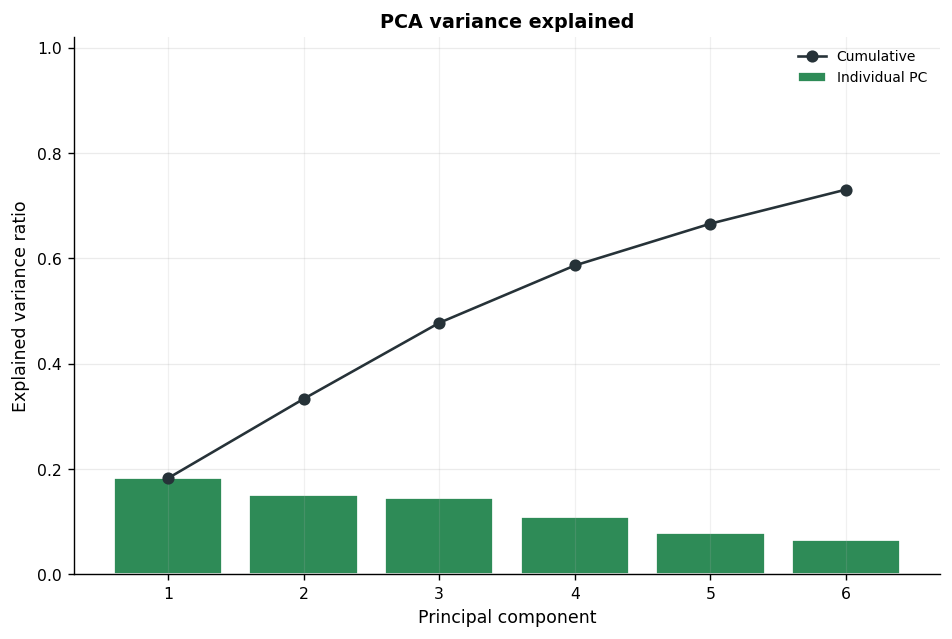

,component,sex_ttest_p,sex_mannwhitney_p,male_mean,female_mean,age_spearman_rho,age_spearman_p
0,PC1,0.686589,0.614244,0.163964,0.595368,-0.251675,0.164671
1,PC2,0.058345,0.724635,0.127169,-0.493652,-0.012116,0.947527
2,PC3,0.362535,0.417984,0.148313,-0.507089,0.151629,0.407430
3,PC4,0.641380,0.724635,-0.188484,0.027903,-0.201928,0.267735
4,PC5,0.157449,0.183130,-0.282674,-0.890442,-0.109775,0.549781
5,PC6,0.176754,0.262564,-0.103415,0.328893,0.146122,0.424869


Saved pca CSV summaries


In [25]:
pca_df, pca_var, loadings_raw, pca, pca_scaler = scar_char.pca_region_table(
    seg_df,
    SEG_COLS,
    n_components=6,
    labels=SEGMENTS,
)
if len(pca_var):
    pc_cols = pca_var['component'].tolist()
    scores = pca_df[pc_cols].to_numpy(dtype=float)
    n_components = len(pc_cols)
    loadings = loadings_raw.rename(columns={'region': 'segment'}).drop(columns=['column'])
    loadings.insert(1, 'label', loadings['segment'].map(SEG_LABELS))
    display(pca_var)
    display(loadings)
    pca_var.to_csv(OUT / 'pca_explained_variance_aha17.csv', index=False)
    loadings.to_csv(OUT / 'pca_loadings_aha17.csv', index=False)

    fig_pca, ax_pca = plt.subplots(figsize=(7.5, 5.0), constrained_layout=True)
    _x = np.arange(1, n_components + 1)
    ax_pca.bar(_x, pca.explained_variance_ratio_, color=NOTEBOOK_PALETTE['accent'], edgecolor='white', label='Individual PC')
    ax_pca.plot(_x, np.cumsum(pca.explained_variance_ratio_), color=NOTEBOOK_PALETTE['neutral'], marker='o', label='Cumulative')
    ax_pca.set_xlabel('Principal component')
    ax_pca.set_ylabel('Explained variance ratio')
    ax_pca.set_ylim(0, 1.02)
    ax_pca.set_title('PCA variance explained')
    ax_pca.set_xticks(_x)
    ax_pca.legend(fontsize=8)
    ax_pca.grid(axis='y', alpha=0.25)
    plt.savefig(OUT / 'pca_aha17_variance.png', bbox_inches='tight', dpi=300)
    plt.show()

    pca_tests = []
    sub_sex = pca_df.dropna(subset=['sex']) if 'sex' in pca_df.columns else pd.DataFrame()
    for pc in pc_cols:
        row = {'component': pc}
        if len(sub_sex):
            m = sub_sex.loc[sub_sex['sex'] == 'M', pc].dropna().to_numpy(dtype=float)
            f = sub_sex.loc[sub_sex['sex'] == 'F', pc].dropna().to_numpy(dtype=float)
            if len(m) >= 2 and len(f) >= 2:
                row['sex_ttest_p'] = ttest_ind(m, f, equal_var=False).pvalue
                row['sex_mannwhitney_p'] = mannwhitneyu(m, f, alternative='two-sided').pvalue
                row['male_mean'] = m.mean()
                row['female_mean'] = f.mean()
        age_sub = pca_df[['age', pc]].dropna()
        if len(age_sub) >= 3:
            row['age_spearman_rho'], row['age_spearman_p'] = spearmanr(age_sub['age'], age_sub[pc])
        pca_tests.append(row)
    pca_tests = pd.DataFrame(pca_tests)
    display(pca_tests)
    pca_tests.to_csv(OUT / 'pca_score_sex_age_tests.csv', index=False)
    print('Saved pca CSV summaries')
else:
    print(f'Skipping PCA: only {len(pca_df)} complete AHA vectors available.')


### 4.7 Area-Based Characterization and Analysis

This section mirrors the vertex-count workflow, but uses mesh surface area instead of binary polar-bin occupancy. In the vertex-count analysis, each polar bin contributes as 0/1 scar presence. In the area-based analysis, scar is weighted by projected LV/CZ surface area, so larger anatomical surface regions contribute proportionally.

The three area-related maps answer different questions:

- **CZ area (`cz_area`)**: absolute scar surface area in each polar bin, in mm2.
- **Scar-normalized CZ area (`cz_norm`)**: fraction of a patient's total scar area located in each bin.
- **LV surface coverage (`coverage`)**: CZ area divided by available LV shell area in that bin, correcting for larger basal bins and LV-size differences.

The goal is to repeat the same logic as the vertex-based analysis: population maps, territory/ring/AHA summaries, age associations, PCA, bootstrap uncertainty, variability, and archetype maps.

#### 4.7.0 Area, Scar-Normalized, and Surface-Coverage Map Computation


#### 4.7.1 Area-Based Projection Helpers


In [26]:

# --- Section 4.7.1 area helpers (adapted from M03 area-projection workflow) ---

_EPS_S8 = 1e-12


def _tri_areas_centers(mesh):
    """Return triangle centers and areas for a mesh surface."""
    surf = mesh.extract_surface(algorithm='dataset_surface').clean()
    if surf.n_cells == 0:
        raise ValueError('mesh has no surface cells')
    pts   = np.asarray(surf.points, dtype=float)
    faces = np.asarray(surf.faces)
    centers_list, areas_list = [], []
    i = 0
    while i < len(faces):
        n   = int(faces[i])
        idx = faces[i + 1 : i + 1 + n]
        i  += 1 + n
        tris = [(0, 1, 2)] if n == 3 else [(0, 1, 2), (0, 2, 3)]
        for a, b, c in tris:
            A, B, C = pts[idx[a]], pts[idx[b]], pts[idx[c]]
            area = 0.5 * np.linalg.norm(np.cross(B - A, C - A))
            if area > 0:
                centers_list.append((A + B + C) / 3.0)
                areas_list.append(area)
    if not centers_list:
        raise ValueError('no valid triangles')
    return np.array(centers_list), np.array(areas_list)


def _accum_areas(mesh, geom, n_r=N_R, n_theta=N_THETA):
    """Accumulate triangle surface area (mm2) into the polar grid."""
    centers, areas = _tri_areas_centers(mesh)
    theta, s = project_points_to_polar(centers, geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    ri = np.clip((s * n_r).astype(int),                      0, n_r - 1)
    ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    grid = np.zeros((n_r, n_theta), dtype=float)
    np.add.at(grid, (ri, ti), areas)
    return grid[:, ::-1]


def polar_area_maps(case, n_r=N_R, n_theta=N_THETA):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    rv    = best_rv_mesh(case)
    if shell is None:
        raise ValueError('no LV shell')
    if cz is None:
        raise ValueError('no CZ mesh')
    if rv is not None:
        ref_fn = lambda m, ax, ap, _rv=rv: rv_reference_from_rv_mesh(m, _rv, ax, ap)
        geom   = prepare_polar_geometry(shell, ref_fn=ref_fn, rv_mesh=rv)
        ref_method = 'rv'
    else:
        geom   = prepare_polar_geometry(shell, rv_mesh=None)
        ref_method = 'pca'

    _t, _s = project_points_to_polar(np.asarray(cz.points), geom)
    _t_cw  = (2.0 * np.pi - _t) % (2.0 * np.pi)
    vertex   = polar_mask(_t_cw, _s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG).astype(float)
    cz_area  = _accum_areas(cz, geom, n_r, n_theta)
    lv_area  = _accum_areas(shell, geom, n_r, n_theta)
    cz_total = float(cz_area.sum())
    lv_total = float(lv_area.sum())
    cz_norm  = np.divide(cz_area, cz_total,
                         out=np.zeros_like(cz_area), where=cz_total > _EPS_S8)
    coverage = np.divide(cz_area, lv_area,
                         out=np.zeros_like(cz_area), where=lv_area > _EPS_S8)
    return dict(vertex=vertex, cz_area=cz_area, lv_area=lv_area,
                cz_norm=cz_norm, coverage=coverage,
                cz_total=cz_total, lv_total=lv_total, ref_method=ref_method)


print('Section 4.7.1 area helpers ready: vertex, CZ area, scar-normalized area, and LV surface coverage.')


Section 4.7.1 area helpers ready: vertex, CZ area, scar-normalized area, and LV surface coverage.


In [ ]:

s8_results, s8_failures = {}, []

for _case in tqdm(known, desc='Sec 8 area maps'):
    _key = f'{_case.year}/{_case.patient_id}'
    try:
        s8_results[_key] = polar_area_maps(_case)
    except Exception as _exc:
        s8_failures.append({'key': _key, 'error': repr(_exc)})

print(f'OK: {len(s8_results)}   Failures: {len(s8_failures)}')
for r in s8_failures[:3]:
    print(f'  {r["key"]}: {r["error"]}')


Sec 8 area maps:  39%|███▉      | 33/84 [10:45<17:15, 20.30s/it]

#### 4.7.2 Area-Based Population Projection Comparison

Mirrors the M03 area-projection comparison: vertex frequency, raw CZ area, scar-normalized CZ area, and LV surface coverage are shown side by side.


In [ ]:
# Population superposition: vertex / CZ area / scar-normalized CZ area / LV surface coverage.
if not s8_results:
    print('No results.')
else:
    _s8_keys = list(s8_results.keys())
    _vert_s8 = np.stack([s8_results[k]['vertex']   for k in _s8_keys]).mean(axis=0)
    _area_s8 = np.stack([s8_results[k]['cz_area']  for k in _s8_keys]).mean(axis=0)
    _norm_s8 = np.stack([s8_results[k]['cz_norm']  for k in _s8_keys]).mean(axis=0)
    _cov_s8  = np.stack([s8_results[k]['coverage'] for k in _s8_keys]).mean(axis=0)

    fig_s8p, axes_s8p = plt.subplots(1, 4, figsize=(22, 6.0), subplot_kw={'projection': 'polar'})
    fig_s8p.suptitle(f'Area projection comparison  |  n={len(_s8_keys)}', fontsize=11)

    def _pct_vmax(arr, pct=95, default=1.0):
        vals = np.asarray(arr)[np.isfinite(arr) & (np.asarray(arr) > 0)]
        return float(np.nanpercentile(vals, pct)) if len(vals) else default

    _vmax_area = _pct_vmax(_area_s8, 95)
    _vmax_norm = _pct_vmax(_norm_s8, 95)
    _vmax_cov  = _pct_vmax(_cov_s8,  95)

    maps = [
        draw_bullseye_m04(_vert_s8, axes_s8p[0], 'Vertex scar frequency', cmap='YlOrRd', vmax=1, label_segs=True),
        draw_bullseye_m04(_area_s8, axes_s8p[1], 'Mean CZ area (mm2)', cmap=AREA_CMAP, vmax=_vmax_area, label_segs=True),
        draw_bullseye_m04(_norm_s8, axes_s8p[2], 'Scar-normalized CZ area', cmap=AREA_CMAP, vmax=_vmax_norm, label_segs=True),
        draw_bullseye_m04(_cov_s8,  axes_s8p[3], 'LV surface coverage', cmap=COVERAGE_CMAP, vmax=_vmax_cov, label_segs=True),
    ]
    labels = ['Fraction of patients', 'Mean CZ area (mm2)', 'Fraction of patient scar', 'CZ area / LV area']
    for _m, _ax, _lab in zip(maps, axes_s8p, labels):
        add_colorbar_m04(_m, _ax, label=_lab)
    fig_s8p.subplots_adjust(top=0.82, wspace=0.28)
    plt.savefig(OUT / 's8_population_projection_comparison.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved s8_population_projection_comparison.png')


#### 4.7.3 Area-Based Population-Level Coronary Territory Distributions

This repeats the territory comparison using area-weighted metrics: raw CZ area, scar-normalized area, and LV surface coverage. The plots show mean values without SD error bars; the Friedman/Kendall annotations test whether the paired territory distributions differ within patients.


In [ ]:
# Territory-level area burden, scar-normalized burden, and LV surface coverage.
if s8_results:
    cz_area_maps = {k: v['cz_area'] for k, v in s8_results.items()}
    cz_norm_maps = {k: v['cz_norm'] for k, v in s8_results.items()}
    lv_area_maps = {k: v['lv_area'] for k, v in s8_results.items()}

    area_terr = scar_char.region_burden_table(
        cz_area_maps,
        TERRITORY_GRID,
        TERRITORY,
        prefix='',
        normalize_by_region_size=False,
    ).rename(columns={t: f'{t}_area_mm2' for t in TERRITORY})
    norm_terr = scar_char.region_burden_table(
        cz_norm_maps,
        TERRITORY_GRID,
        TERRITORY,
        prefix='',
        normalize_by_region_size=False,
    ).rename(columns={t: f'{t}_norm' for t in TERRITORY})
    coverage_terr = scar_char.region_burden_table(
        cz_area_maps,
        TERRITORY_GRID,
        TERRITORY,
        prefix='',
        denominator_maps=lv_area_maps,
        normalize_by_region_size=True,
    ).rename(columns={t: f'{t}_coverage' for t in TERRITORY})

    df_s8 = area_terr[['key', 'pid']].copy()
    df_s8['sex'] = df_s8['pid'].map(sex_map)
    df_s8['age'] = df_s8['pid'].map(age_map).astype(float)
    for t in TERRITORY:
        df_s8[f'{t}_area_mm2'] = area_terr[f'{t}_area_mm2']
        df_s8[f'{t}_norm'] = norm_terr[f'{t}_norm']
        df_s8[f'{t}_coverage'] = coverage_terr[f'{t}_coverage']
    df_s8['cz_total_mm2'] = df_s8['key'].map(lambda k: float(s8_results[k]['cz_total']))
    df_s8['lv_total_mm2'] = df_s8['key'].map(lambda k: float(s8_results[k]['lv_total']))
    df_s8['global_coverage'] = df_s8['cz_total_mm2'] / df_s8['lv_total_mm2'].replace(0, np.nan)

    df_s8['dominant_area_mm2'] = df_s8[[f'{t}_area_mm2' for t in TERRITORY]].idxmax(axis=1).str.replace('_area_mm2', '', regex=False)
    df_s8['dominant_area_norm'] = df_s8[[f'{t}_norm' for t in TERRITORY]].idxmax(axis=1).str.replace('_norm', '', regex=False)
    df_s8['dominant_coverage'] = df_s8[[f'{t}_coverage' for t in TERRITORY]].idxmax(axis=1).str.replace('_coverage', '', regex=False)
    df_s8.to_csv(OUT / 'area_territory_summary_per_patient.csv', index=False)

    print('Territory CZ area (mm2) mean +/- SD:')
    for t in TERRITORY:
        col = f'{t}_area_mm2'
        print(f'  {t}: {df_s8[col].mean():.2f} +/- {df_s8[col].std():.2f}')

    fig_s8t, axes_s8t = plt.subplots(1, 3, figsize=(17, 5.2), constrained_layout=True)
    fig_s8t.suptitle(f'Territory-level area burden and coverage  (n={len(df_s8)})', fontsize=12)

    for ax, col_suffix, ylabel, title in [
        (axes_s8t[0], 'area_mm2', 'CZ area (mm2)', 'Raw CZ area'),
        (axes_s8t[1], 'norm', 'Fraction of patient scar', 'Scar-normalized area'),
        (axes_s8t[2], 'coverage', 'CZ area / LV area', 'LV surface coverage'),
    ]:
        cols_for_test = [f'{t}_{col_suffix}' for t in TERRITORY]
        means = [df_s8[c].mean() for c in cols_for_test]
        cols  = [TERR_COLORS[t] for t in TERRITORY]
        bars  = ax.bar(list(TERRITORY), means, color=cols, alpha=0.80, edgecolor='white', width=0.55)
        _ymax = max(means) if len(means) else 0
        for bar, m_v in zip(bars, means):
            _offset = _ymax * 0.04 if _ymax > 0 else 0.01
            ax.text(bar.get_x() + bar.get_width() / 2,
                    m_v + _offset,
                    f'{m_v:.3f}', ha='center', va='bottom', fontsize=8)
        fr = scar_analysis.friedman_regions(df_s8, cols_for_test)
        if np.isfinite(fr['p_value']):
            kendall_w = fr['statistic'] / (fr['n'] * 3 * (3 - 1))
            ax.text(0.97, 0.97,
                    f'Friedman chi2={fr["statistic"]:.2f}\np={fr["p_value"]:.3f}\nKendall W={kendall_w:.3f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, _ymax * 1.24 if _ymax > 0 else 1)

    plt.savefig(OUT / 's8_territory_area_coverage_burden.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved area_territory_summary_per_patient.csv and s8_territory_area_coverage_burden.png')
else:
    print('No area results available.')


#### 4.7.4 Area-Based AHA-17 Segment Characterization


In [ ]:
# AHA-17 segment comparison: vertex / CZ area / scar-normalized area / LV surface coverage.
if s8_results:
    _s8_keys2 = list(s8_results.keys())
    _segs_s8  = list(range(1, 18))
    _AHA_G8 = AHA_GRID
    cz_area_maps = {k: v['cz_area'] for k, v in s8_results.items()}
    cz_norm_maps = {k: v['cz_norm'] for k, v in s8_results.items()}
    lv_area_maps = {k: v['lv_area'] for k, v in s8_results.items()}
    vertex_maps_s8 = {k: v['vertex'] for k, v in s8_results.items()}

    area_part = scar_char.region_burden_table(
        cz_area_maps, _AHA_G8, _segs_s8, prefix='area_seg_', normalize_by_region_size=False
    )
    norm_part = scar_char.region_burden_table(
        cz_norm_maps, _AHA_G8, _segs_s8, prefix='norm_seg_', normalize_by_region_size=False
    )
    coverage_part = scar_char.region_burden_table(
        cz_area_maps, _AHA_G8, _segs_s8, prefix='coverage_seg_', denominator_maps=lv_area_maps, normalize_by_region_size=True
    )

    area_seg_df = area_part[['key', 'pid']].copy()
    area_seg_df['age'] = area_seg_df['pid'].map(age_map).astype(float)
    AREA_SEG_COLS = [f'area_seg_{i:02d}' for i in range(1, 18)]
    NORM_SEG_COLS = [f'norm_seg_{i:02d}' for i in range(1, 18)]
    COVERAGE_SEG_COLS = [f'coverage_seg_{i:02d}' for i in range(1, 18)]
    for col in AREA_SEG_COLS:
        area_seg_df[col] = area_part[col]
    for col in NORM_SEG_COLS:
        area_seg_df[col] = norm_part[col]
    for col in COVERAGE_SEG_COLS:
        area_seg_df[col] = coverage_part[col]
    area_seg_df.to_csv(OUT / 'area_aha17_per_patient.csv', index=False)

    area_summary = scar_char.region_summary(
        area_seg_df, AREA_SEG_COLS, labels=_segs_s8, label_names=SEG_LABELS, value_name='area_mm2'
    ).rename(columns={'region': 'segment'})
    norm_summary = scar_char.region_summary(
        area_seg_df, NORM_SEG_COLS, labels=_segs_s8, label_names=SEG_LABELS, value_name='norm'
    ).rename(columns={'region': 'segment'})
    coverage_summary = scar_char.region_summary(
        area_seg_df, COVERAGE_SEG_COLS, labels=_segs_s8, label_names=SEG_LABELS, value_name='coverage'
    ).rename(columns={'region': 'segment'})

    vertex_presence = scar_char.region_burden_table(
        {k: np.asarray(v, dtype=bool).astype(float) for k, v in vertex_maps_s8.items()},
        _AHA_G8,
        _segs_s8,
        prefix='vertex_seg_',
        normalize_by_region_size=False,
    )
    _aha_rows = []
    for _seg in _segs_s8:
        _col_v = f'vertex_seg_{_seg:02d}'
        _aha_rows.append({
            'segment': _seg,
            'label': SEG_LABELS[_seg],
            'vertex_frequency': float((vertex_presence[_col_v] > 0).mean()),
            'mean_area_mm2': float(area_summary.loc[area_summary['segment'] == _seg, 'mean_area_mm2_all'].iloc[0]),
            'sd_area_mm2': float(area_summary.loc[area_summary['segment'] == _seg, 'sd_area_mm2_all'].iloc[0]),
            'mean_norm': float(norm_summary.loc[norm_summary['segment'] == _seg, 'mean_norm_all'].iloc[0]),
            'mean_coverage': float(coverage_summary.loc[coverage_summary['segment'] == _seg, 'mean_coverage_all'].iloc[0]),
            'sd_coverage': float(coverage_summary.loc[coverage_summary['segment'] == _seg, 'sd_coverage_all'].iloc[0]),
        })
    area_aha_summary = pd.DataFrame(_aha_rows)
    display(area_aha_summary)
    area_aha_summary.to_csv(OUT / 'area_aha17_summary.csv', index=False)

    x_s8 = np.arange(1, 18)
    fig_s8a, axes_s8a = plt.subplots(1, 4, figsize=(20, 4.3), constrained_layout=True)
    fig_s8a.suptitle(f'AHA-17 area comparison  |  n={len(_s8_keys2)}', fontsize=11)
    plot_specs = [
        ('vertex_frequency', 'Vertex scar frequency', 'Fraction of patients', '#c0392b'),
        ('mean_area_mm2', 'Mean CZ area', 'mm2', '#8e44ad'),
        ('mean_norm', 'Scar-normalized CZ area', 'Fraction of total scar', '#16a085'),
        ('mean_coverage', 'LV surface coverage', 'CZ area / LV area', '#2c3e50'),
    ]
    for _ax, (_col, _title, _ylabel, _color) in zip(axes_s8a, plot_specs):
        _ax.bar(x_s8, area_aha_summary[_col], color=_color, edgecolor='white')
        _ax.set_title(_title)
        _ax.set_ylabel(_ylabel)
        _ax.set_xlabel('AHA segment')
        _ax.set_xticks(x_s8)
        _ax.set_xticklabels(x_s8, fontsize=7)
        _ax.grid(axis='y', alpha=0.25)
        _ax.set_xlim(0.3, 17.7)
    plt.savefig(OUT / 's8_aha_segments_area_coverage.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved area_aha17_per_patient.csv, area_aha17_summary.csv, and s8_aha_segments_area_coverage.png')
else:
    print('No area results available.')


#### 4.7.5 Area-Based Age Effects Across AHA-17 Segments

This mirrors Section 3.5, using CZ area per AHA segment instead of the fraction of scar-positive bins.


In [ ]:
if 'area_seg_df' not in globals() or area_seg_df.empty:
    print('area_seg_df is not available. Run Section 4.7.4 first.')
else:
    AREA_SEG_COLS = [f'area_seg_{i:02d}' for i in range(1, 18)]
    age_spearman_area_aha17 = scar_analysis.spearman_by_region(
        area_seg_df,
        AREA_SEG_COLS,
        'age',
        labels=list(range(1, 18)),
        bonferroni=True,
    ).rename(columns={'region': 'segment'})
    age_spearman_area_aha17['label'] = age_spearman_area_aha17['segment'].map(SEG_LABELS)
    age_spearman_area_aha17 = age_spearman_area_aha17[['segment', 'label', 'n', 'spearman_rho', 'p_uncorrected', 'p_bonferroni', 'significant_bonf_0_05']]
    display(age_spearman_area_aha17)
    age_spearman_area_aha17.to_csv(OUT / 'age_spearman_area_aha17.csv', index=False)

    fig_area_age, ax_area_age = plt.subplots(figsize=(12, 4.2))
    ax_area_age.bar(age_spearman_area_aha17['segment'], age_spearman_area_aha17['spearman_rho'],
                    color='#8e44ad', edgecolor='white')
    ax_area_age.axhline(0, color='black', lw=0.8)
    ax_area_age.set_xticks(range(1, 18))
    ax_area_age.set_xlabel('AHA segment')
    ax_area_age.set_ylabel('Spearman rho with age')
    ax_area_age.set_title('Area-based age correlation by AHA segment')
    ax_area_age.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'age_spearman_area_aha17.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved age_spearman_area_aha17.csv and age_spearman_area_aha17.png')


INSIHGT: NON SIGNIFICANT


#### 4.7.6 Area-Based PCA of AHA-17 CZ Area Vectors

This mirrors Section 4.6, using the 17-segment CZ area vector for each patient.


In [ ]:
if 'area_seg_df' not in globals() or area_seg_df.empty:
    print('area_seg_df is not available. Run Section 4.7.4 first.')
else:
    AREA_SEG_COLS = [f'area_seg_{i:02d}' for i in range(1, 18)]
    area_scores, area_pca_var, area_loadings_raw, pca_area, area_scaler = scar_char.pca_region_table(
        area_seg_df,
        AREA_SEG_COLS,
        n_components=6,
        labels=list(range(1, 18)),
    )
    if area_pca_var.empty:
        print('Not enough complete area rows for PCA.')
    else:
        area_pc_cols = area_pca_var['component'].tolist()
        area_scores_df = area_scores.copy()
        area_scores = area_scores_df[area_pc_cols].to_numpy(dtype=float)
        area_loadings = area_loadings_raw.rename(columns={'region': 'segment'}).drop(columns=['column'])
        area_loadings.insert(1, 'label', area_loadings['segment'].map(SEG_LABELS))
        display(area_pca_var)
        area_pca_var.to_csv(OUT / 'pca_explained_variance_area_aha17.csv', index=False)
        display(area_loadings)
        area_loadings.to_csv(OUT / 'pca_loadings_area_aha17.csv', index=False)
        fig_area_pca, ax_area_pca = plt.subplots(figsize=(7.5, 5.0), constrained_layout=True)
        _x = np.arange(1, len(area_pca_var) + 1)
        ax_area_pca.bar(_x, area_pca_var['explained_variance_ratio'], color=NOTEBOOK_PALETTE['accent'], edgecolor='white', label='Individual PC')
        ax_area_pca.plot(_x, area_pca_var['cumulative_variance_ratio'], marker='o', color=NOTEBOOK_PALETTE['neutral'], label='Cumulative')
        ax_area_pca.set_xlabel('Principal component')
        ax_area_pca.set_ylabel('Explained variance ratio')
        ax_area_pca.set_ylim(0, 1.02)
        ax_area_pca.set_title('Area-based PCA variance explained')
        ax_area_pca.set_xticks(_x)
        ax_area_pca.legend(fontsize=8)
        ax_area_pca.grid(axis='y', alpha=0.25)
        plt.savefig(OUT / 'pca_variance_area_aha17.png', bbox_inches='tight', dpi=300)
        plt.show()
        print('Saved area PCA outputs')


#### 4.7.7 Ring-Level Surface Coverage

Adapted from the M03 ring-level surface-coverage workflow. Each bar is pooled CZ area divided by pooled LV shell area inside that apex-to-base ring.


In [ ]:
if not s8_results:
    print('No area results available.')
else:
    _s8_keys = list(s8_results.keys())
    _RINGS43 = [
        ('Apex (17)',       lambda r: r < 0.25,                 '#9b59b6'),
        ('Apical (13-16)',  lambda r: (r >= 0.25) & (r < 0.50), '#e74c3c'),
        ('Mid (7-12)',      lambda r: (r >= 0.50) & (r < 0.75), '#2ecc71'),
        ('Basal (1-6)',     lambda r: r >= 0.75,                '#3498db'),
    ]
    _rc43 = (np.arange(N_R) + 0.5) / N_R
    RING_GRID_AREA = np.full((N_R, N_THETA), '', dtype=object)
    _ring_colors = {}
    for _label, _fn, _col in _RINGS43:
        _mask_r = _fn(_rc43)
        RING_GRID_AREA[np.broadcast_to(_mask_r[:, None], (N_R, N_THETA))] = _label
        _ring_colors[_label] = _col

    cz_area_maps = {k: v['cz_area'] for k, v in s8_results.items()}
    lv_area_maps = {k: v['lv_area'] for k, v in s8_results.items()}
    ring_area = scar_char.region_burden_table(
        cz_area_maps,
        RING_GRID_AREA,
        [r[0] for r in _RINGS43],
        denominator_maps=lv_area_maps,
        normalize_by_region_size=True,
        include_raw=True,
    )
    _ring_rows = []
    for _label, _, _col in _RINGS43:
        _cz_pool = sum(float(cz_area_maps[k][RING_GRID_AREA == _label].sum()) for k in _s8_keys)
        _lv_pool = sum(float(lv_area_maps[k][RING_GRID_AREA == _label].sum()) for k in _s8_keys)
        _ring_rows.append({'ring': _label, 'cz_area_mm2': _cz_pool, 'lv_area_mm2': _lv_pool,
                           'coverage': _cz_pool / _lv_pool if _lv_pool > _EPS_S8 else np.nan,
                           'color': _col})
    area_ring_coverage = pd.DataFrame(_ring_rows)
    display(area_ring_coverage.drop(columns='color'))
    area_ring_coverage.drop(columns='color').to_csv(OUT / 'area_ring_coverage.csv', index=False)

    fig_r43, ax_r43 = plt.subplots(figsize=(9, 5))
    bars = ax_r43.bar(area_ring_coverage['ring'], area_ring_coverage['coverage'],
                      color=area_ring_coverage['color'], edgecolor='white', width=0.58)
    for bar, (_, row) in zip(bars, area_ring_coverage.iterrows()):
        ax_r43.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(area_ring_coverage['coverage']) * 0.03,
                    f"{row['coverage']:.3f}\n({row['cz_area_mm2']/1e3:.1f}k / {row['lv_area_mm2']/1e3:.1f}k mm2)",
                    ha='center', va='bottom', fontsize=8)
    ax_r43.set_title(f'CZ area by LV ring (n={len(_s8_keys)})')
    ax_r43.set_ylabel('CZ area / LV area')
    ax_r43.grid(axis='y', alpha=0.25)
    ax_r43.set_ylim(0, max(area_ring_coverage['coverage']) * 1.25)
    plt.tight_layout()
    plt.savefig(OUT / 'area_ring_coverage.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved area_ring_coverage.csv and area_ring_coverage.png')


#### 4.7.8 Bootstrap CI for Area and Coverage per AHA Segment

Patient-level bootstrap confidence intervals for mean CZ area and mean LV surface coverage in each AHA segment.


In [ ]:
if 'area_seg_df' not in globals() or area_seg_df.empty:
    print('area_seg_df is not available. Run Section 4.7.4 first.')
else:
    AREA_SEG_COLS = [f'area_seg_{i:02d}' for i in range(1, 18)]
    COVERAGE_SEG_COLS = [f'coverage_seg_{i:02d}' for i in range(1, 18)]
    area_boot = scar_analysis.bootstrap_region_ci(
        area_seg_df, AREA_SEG_COLS, labels=list(range(1, 18)), value_name='mean_area_mm2', n_boot=2000, rng=np.random.default_rng(42)
    ).rename(columns={'region': 'segment', 'ci95_low': 'area_ci95_low', 'ci95_high': 'area_ci95_high'})
    coverage_boot = scar_analysis.bootstrap_region_ci(
        area_seg_df, COVERAGE_SEG_COLS, labels=list(range(1, 18)), value_name='mean_coverage', n_boot=2000, rng=np.random.default_rng(420)
    ).rename(columns={'region': 'segment', 'ci95_low': 'coverage_ci95_low', 'ci95_high': 'coverage_ci95_high'})
    area_bootstrap_aha17 = area_boot.merge(coverage_boot, on='segment', how='left')
    area_bootstrap_aha17['label'] = area_bootstrap_aha17['segment'].map(SEG_LABELS)
    area_bootstrap_aha17 = area_bootstrap_aha17[['segment', 'label', 'mean_area_mm2', 'area_ci95_low', 'area_ci95_high',
                                                 'mean_coverage', 'coverage_ci95_low', 'coverage_ci95_high']]
    display(area_bootstrap_aha17)
    area_bootstrap_aha17.to_csv(OUT / 'area_bootstrap_aha17.csv', index=False)

    fig_ab, axes_ab = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
    x = np.arange(1, 18)
    axes_ab[0].errorbar(x, area_bootstrap_aha17['mean_area_mm2'],
                        yerr=[area_bootstrap_aha17['mean_area_mm2'] - area_bootstrap_aha17['area_ci95_low'],
                              area_bootstrap_aha17['area_ci95_high'] - area_bootstrap_aha17['mean_area_mm2']],
                        fmt='o', color=NOTEBOOK_PALETTE['secondary'], ecolor=NOTEBOOK_PALETTE['secondary'], capsize=3)
    axes_ab[0].set_title('Mean CZ area bootstrap CI')
    axes_ab[0].set_ylabel('CZ area (mm2)')
    axes_ab[1].errorbar(x, area_bootstrap_aha17['mean_coverage'],
                        yerr=[area_bootstrap_aha17['mean_coverage'] - area_bootstrap_aha17['coverage_ci95_low'],
                              area_bootstrap_aha17['coverage_ci95_high'] - area_bootstrap_aha17['mean_coverage']],
                        fmt='o', color=NOTEBOOK_PALETTE['neutral'], ecolor=NOTEBOOK_PALETTE['neutral'], capsize=3)
    axes_ab[1].set_title('Mean LV surface coverage bootstrap CI')
    axes_ab[1].set_ylabel('CZ area / LV area')
    for _ax in axes_ab:
        _ax.set_xlabel('AHA segment')
        _ax.set_xticks(x)
        _ax.grid(alpha=0.25)
    plt.savefig(OUT / 'area_bootstrap_aha17.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved area_bootstrap_aha17.csv and area_bootstrap_aha17.png')


#### 4.7.9 Area Archetype Maps by Dominant Coronary Territory

For patients assigned to each dominant area territory, this shows the mean CZ area and mean LV surface coverage polar maps.


In [ ]:
if not s8_results or 'df_s8' not in globals() or df_s8.empty:
    print('Area results or df_s8 are not available. Run Sections 4.8.1-4.8.3 first.')
else:
    _arch_terrs = ['LAD', 'RCA', 'LCX']
    _area_maps, _coverage_maps, _arch_ns = {}, {}, {}
    for _terr in _arch_terrs:
        _tkeys = df_s8.loc[df_s8['dominant_area_mm2'] == _terr, 'key'].tolist()
        _tkeys = [k for k in _tkeys if k in s8_results]
        if _tkeys:
            _area_maps[_terr] = np.stack([s8_results[k]['cz_area'] for k in _tkeys]).mean(axis=0)
            _coverage_maps[_terr] = np.stack([s8_results[k]['coverage'] for k in _tkeys]).mean(axis=0)
            _arch_ns[_terr] = len(_tkeys)
    if not _area_maps:
        print('No area archetype maps computable.')
    else:
        _avail = [t for t in _arch_terrs if t in _area_maps]
        _vmax_area = max(float(np.nanpercentile(_area_maps[t][_area_maps[t] > 0], 95)) if (_area_maps[t] > 0).any() else 0 for t in _avail)
        _vmax_cov = max(float(np.nanpercentile(_coverage_maps[t][_coverage_maps[t] > 0], 95)) if (_coverage_maps[t] > 0).any() else 0 for t in _avail)
        _vmax_area = _vmax_area if _vmax_area > 0 else 1.0
        _vmax_cov = _vmax_cov if _vmax_cov > 0 else 1.0
        fig_arch, axes_arch = plt.subplots(2, len(_avail), figsize=(5.2 * len(_avail), 9.8), subplot_kw={'projection': 'polar'})
        axes_arch = np.atleast_2d(axes_arch)
        fig_arch.suptitle('Area archetype maps by dominant raw-area territory', fontsize=12)
        for _j, _terr in enumerate(_avail):
            _m1 = draw_bullseye_m04(_area_maps[_terr], axes_arch[0, _j],
                                    title=f'{_terr} dominant (n={_arch_ns[_terr]})\nMean CZ area',
                                    cmap=AREA_CMAP, vmax=_vmax_area, label_segs=True)
            add_colorbar_m04(_m1, axes_arch[0, _j], label='CZ area (mm2)')
            _m2 = draw_bullseye_m04(_coverage_maps[_terr], axes_arch[1, _j],
                                    title=f'{_terr} dominant (n={_arch_ns[_terr]})\nMean LV surface coverage',
                                    cmap=COVERAGE_CMAP, vmax=_vmax_cov, label_segs=True)
            add_colorbar_m04(_m2, axes_arch[1, _j], label='CZ area / LV area')
        fig_arch.subplots_adjust(top=0.90, wspace=0.30, hspace=0.32)
        plt.savefig(OUT / 'area_archetype_maps_by_dominant_territory.png', bbox_inches='tight', dpi=300)
        plt.show()
        print('Saved area_archetype_maps_by_dominant_territory.png')


#### 4.7.10 Area-Based Age Correlations

This mirrors Section 3.7 using area-based territory metrics, global CZ area, and global LV surface coverage. Spearman rho is the primary statistic; Pearson r is reported as a secondary linear summary.


In [ ]:
if 'df_s8' not in globals() or df_s8.empty:
    print('df_s8 is not available. Run Section 7.3 first.')
else:
    df_s8_age = df_s8.dropna(subset=['age']).copy()
    _area_age_specs = [
        ('cz_total_mm2', 'Total CZ area (mm2)', NOTEBOOK_PALETTE['secondary']),
        ('global_coverage', 'Global LV surface coverage', NOTEBOOK_PALETTE['neutral']),
    ]
    for _terr in ('LAD', 'RCA', 'LCX'):
        _area_age_specs.append((f'{_terr}_area_mm2', f'{_terr} CZ area (mm2)', TERR_COLORS[_terr]))
    _area_age_cols = [c for c, _, _ in _area_age_specs]
    _area_age_labels = {c: label for c, label, _ in _area_age_specs}
    age_area_territory_summary = scar_analysis.scalar_associations(
        df_s8_age,
        _area_age_cols,
        'age',
        labels=_area_age_labels,
    )

    fig_area_age_terr, axes_area_age_terr = plt.subplots(1, len(_area_age_specs), figsize=(5.4 * len(_area_age_specs), 5.0), constrained_layout=True)
    axes_area_age_terr = np.atleast_1d(axes_area_age_terr)
    for _ax, (_col, _label, _color) in zip(axes_area_age_terr, _area_age_specs):
        _sub = df_s8_age[['age', _col]].dropna()
        _stats = age_area_territory_summary.loc[age_area_territory_summary['variable'] == _col].iloc[0]
        _rho, _p_s = _stats['spearman_rho'], _stats['spearman_p']
        _r, _p_p = _stats['pearson_r'], _stats['pearson_p']
        _ax.scatter(_sub['age'], _sub[_col], color=_color, alpha=0.65, s=28, edgecolors='white', linewidth=0.5)
        if len(_sub) >= 2:
            _m, _b = np.polyfit(_sub['age'], _sub[_col], 1)
            _x = np.linspace(_sub['age'].min(), _sub['age'].max(), 100)
            _ax.plot(_x, _m * _x + _b, color=_color, ls='--', lw=1.6)
        _ax.set_title(_label)
        _ax.set_xlabel('Age (years)')
        _ax.set_ylabel(_label)
        _ax.text(0.97, 0.97, f'Spearman rho={_rho:+.3f} p={_p_s:.3f}\nPearson r={_r:+.3f} p={_p_p:.3f}\nn={len(_sub)}',
                 transform=_ax.transAxes, ha='right', va='top', fontsize=8,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        _ax.grid(alpha=0.25)
    fig_area_age_terr.suptitle(f'Age vs area-based scar burden and coverage (n={len(df_s8_age)})', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT / 'age_area_territory_correlation.png', bbox_inches='tight', dpi=300)
    plt.show()
    display(age_area_territory_summary)
    age_area_territory_summary.to_csv(OUT / 'age_area_territory_correlation.csv', index=False)
    print('Saved age_area_territory_correlation.csv and age_area_territory_correlation.png')


INISHFT: NON SIGNIFICANT


### 4.8 Vertex-Based vs Area-Based Method Comparison

Both the vertex-count and area-based analyses characterize the same scar through different lenses. This section checks whether their conclusions agree at segment, ring, patient, and territory level before moving to the separate transmurality question.

| | Vertex-based | Area-based |
|---|---|---|
| **Unit** | fraction of polar bins with >=1 scar vertex | mm2 CZ surface / total LV mm2 |
| **Sensitivity** | uniform bin weighting | proportional to local LV surface area |
| **Best use** | location frequency and simple burden summaries | anatomical surface-weighted burden and coverage |


In [ ]:
# -----------------------------------------------------------------------
# Section 4.8 - Vertex vs Area method comparison
# -----------------------------------------------------------------------
import os as _os6
from scipy.stats import spearmanr as _sp6
from sklearn.metrics import cohen_kappa_score as _kappa6

_OUT6 = OUT  # reuse existing OUT path

# Load segment-level summaries from saved CSVs
_v_seg = pd.read_csv(_OUT6 / 'aha17_segment_summary.csv')          # vertex
_a_seg = pd.read_csv(_OUT6 / 'area_aha17_summary.csv')              # area
_v_age = pd.read_csv(_OUT6 / 'age_spearman_aha17.csv')              # vertex age rho
_a_age = pd.read_csv(_OUT6 / 'age_spearman_area_aha17.csv')         # area age rho
_v_ring = pd.read_csv(_OUT6 / 'vertex_ring_scar_burden.csv')        # vertex rings
_a_ring = pd.read_csv(_OUT6 / 'area_ring_coverage.csv')             # area rings
_a_terr = pd.read_csv(_OUT6 / 'area_territory_summary_per_patient.csv')


# Segment ring colours used by all 4.9 scatter plots.
_ring_colors = {
    'bas': '#3498db', 'mid': '#2ecc71', 'api': '#e74c3c', 'ape': '#9b59b6'
}
def _seg_ring_color(seg):
    if seg <= 6: return _ring_colors['bas']
    if seg <= 12: return _ring_colors['mid']
    if seg <= 16: return _ring_colors['api']
    return _ring_colors['ape']

# Merge segment tables on segment id
_seg_cmp = _v_seg[['segment', 'label', 'mean_extent_all']].merge(
    _a_seg[['segment', 'mean_norm', 'mean_coverage']],
    on='segment'
)


_seg_cmp = _seg_cmp.rename(columns={
    'mean_extent_all': 'vertex_burden',
    'mean_norm': 'area_normalized_burden',
    'mean_coverage': 'lv_surface_coverage',
})
_seg_cmp_display = _seg_cmp[['segment', 'label', 'vertex_burden', 'area_normalized_burden', 'lv_surface_coverage']].copy()
display(_seg_cmp_display)
_seg_cmp_display.to_csv(_OUT6 / 'method_comparison_segment_three_metric_table.csv', index=False)
print('Saved method_comparison_segment_three_metric_table.csv')

# Pairwise segment-level comparison across the three quantification approaches.
_metric_specs = [
    ('vertex_burden', 'Vertex burden'),
    ('area_normalized_burden', 'Area-normalized CZ burden'),
    ('lv_surface_coverage', 'LV surface coverage'),
]
fig6_pair, axes6_pair = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
_pair_defs = [(0, 1), (0, 2), (1, 2)]
_colors_pair = [_seg_ring_color(s) for s in _seg_cmp['segment']]
for ax, (_i, _j) in zip(axes6_pair, _pair_defs):
    _xcol, _xlabel = _metric_specs[_i]
    _ycol, _ylabel = _metric_specs[_j]
    _rho, _p = _sp6(_seg_cmp[_xcol], _seg_cmp[_ycol])
    ax.scatter(_seg_cmp[_xcol] * 100, _seg_cmp[_ycol] * 100, c=_colors_pair, s=70,
               edgecolors='k', linewidths=0.5, alpha=0.85)
    for _, _row in _seg_cmp.iterrows():
        ax.annotate(int(_row['segment']), (_row[_xcol] * 100, _row[_ycol] * 100),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')
    ax.set_xlabel(f'{_xlabel} (%)')
    ax.set_ylabel(f'{_ylabel} (%)')
    ax.set_title(f'{_xlabel} vs {_ylabel}\nSpearman rho={_rho:.3f}, p={_p:.4f}', fontsize=9)
    ax.grid(alpha=0.25)
plt.savefig(_OUT6 / 'method_comparison_three_metric_scatterplots.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved method_comparison_three_metric_scatterplots.png')

# Spearman rank correlation between methods across 17 segments
_rho_seg, _p_seg = _sp6(_seg_cmp['vertex_burden'], _seg_cmp['area_normalized_burden'])
print(f'AHA-17 segment ranking agreement: Spearman rho={_rho_seg:.3f}, p={_p_seg:.4f}')

# Ring labels in consistent order
_ring_order = ['Basal (1-6)', 'Mid (7-12)', 'Apical (13-16)', 'Apex (17)']
_v_ring = _v_ring.set_index('ring').reindex(_ring_order)
_a_ring = _a_ring.set_index('ring').reindex(_ring_order)

# Per-patient total scar (vertex = seg_df total_scar, area = global_coverage from a_terr)
_pat_v = seg_df[['key', 'total_scar']].copy() if 'seg_df' in dir() and 'total_scar' in seg_df.columns else None
_pat_a = _a_terr[['key', 'global_coverage', 'dominant_area_mm2']].copy()

# Territory dominant agreement: vertex df vs area df_s8
_terr_cmp = None
if 'df' in dir() and 'dominant' in df.columns:
    _v_dom = df[['key', 'dominant']].rename(columns={'dominant': 'dom_vertex'})
    _a_dom = _a_terr[['key', 'dominant_area_mm2']].rename(columns={'dominant_area_mm2': 'dom_area'})
    _terr_cmp = _v_dom.merge(_a_dom, on='key')
    _match_pct = (_terr_cmp['dom_vertex'] == _terr_cmp['dom_area']).mean() * 100
    try:
        _kap = _kappa6(_terr_cmp['dom_vertex'], _terr_cmp['dom_area'])
    except Exception:
        _kap = float('nan')
    print(f'Dominant territory agreement: {_match_pct:.1f}% match, Cohen kappa={_kap:.3f}  (n={len(_terr_cmp)})')

# ---- Figure 1: AHA-17 segment ranking --------------------------------
fig6, axes6 = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)
fig6.suptitle('Section 4.8 - Vertex vs Area Method Comparison', fontsize=13, fontweight='bold')

ax = axes6[0, 0]
_colors = [_seg_ring_color(s) for s in _seg_cmp['segment']]
ax.scatter(_seg_cmp['vertex_burden'] * 100, _seg_cmp['area_normalized_burden'] * 100,
           c=_colors, s=70, zorder=3, edgecolors='k', linewidths=0.5)
for _, row in _seg_cmp.iterrows():
    ax.annotate(int(row['segment']),
                (row['vertex_burden'] * 100, row['area_normalized_burden'] * 100),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Vertex: mean segment extent (%)', fontsize=9)
ax.set_ylabel('Area: mean normalised CZ (%)', fontsize=9)
ax.set_title(f'AHA-17 segment ranking\nSpearman rho={_rho_seg:.3f}, p={_p_seg:.4f}', fontsize=9)
from matplotlib.patches import Patch as _Patch
ax.legend(handles=[_Patch(color=_ring_colors['bas'], label='Basal'),
                   _Patch(color=_ring_colors['mid'], label='Mid'),
                   _Patch(color=_ring_colors['api'], label='Apical'),
                   _Patch(color=_ring_colors['ape'], label='Apex')],
          fontsize=8, loc='upper left')
ax.grid(alpha=0.25)

# ---- Figure 2: ring-level burden comparison --------------------------
ax = axes6[0, 1]
_x = np.arange(len(_ring_order))
_w = 0.35
_vb = _v_ring['mean_burden'].values * 100
_ab = _a_ring['coverage'].values * 100
b1 = ax.bar(_x - _w/2, _vb, _w, label='Vertex (% polar bins)', color='#4878cf', alpha=0.85)
b2 = ax.bar(_x + _w/2, _ab, _w, label='Area (% LV surface)', color='#d95f02', alpha=0.85)
ax.set_xticks(_x)
ax.set_xticklabels(_ring_order, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Scar burden (%)', fontsize=9)
ax.set_title('Ring-level scar burden', fontsize=9)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.25)
for b, val in zip(list(b1) + list(b2), list(_vb) + list(_ab)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=7)

# ---- Figure 3: age rho comparison per segment ------------------------
ax = axes6[1, 0]
_segs_ord = list(range(1, 18))
_v_rho_arr = _v_age.set_index('segment').reindex(_segs_ord)['spearman_rho'].values
_a_rho_arr = _a_age.set_index('segment').reindex(_segs_ord)['spearman_rho'].values
_x3 = np.arange(len(_segs_ord))
ax.bar(_x3 - _w/2, _v_rho_arr, _w, label='Vertex', color='#4878cf', alpha=0.85)
ax.bar(_x3 + _w/2, _a_rho_arr, _w, label='Area', color='#d95f02', alpha=0.85)
ax.axhline(0, color='k', linewidth=0.7)
ax.set_xticks(_x3)
ax.set_xticklabels([str(s) for s in _segs_ord], fontsize=7)
ax.set_xlabel('AHA-17 segment', fontsize=9)
ax.set_ylabel('Spearman rho (vs age)', fontsize=9)
ax.set_title('Age correlation per AHA-17 segment\n(both methods)', fontsize=9)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.25)

# ---- Figure 4: per-patient total scar scatter + territory agreement ---
ax = axes6[1, 1]
if _pat_v is not None and _pat_a is not None:
    _pp = _pat_v.merge(_pat_a, on='key')
    _terr_palette = {'LAD': '#C83E4D', 'RCA': '#2F6B9A', 'LCX': '#3F8F5F'}
    _pc = [_terr_palette.get(t, '#888') for t in _pp['dominant_area_mm2']]
    _rho_pp, _p_pp = _sp6(_pp['total_scar'], _pp['global_coverage'])
    ax.scatter(_pp['total_scar'] * 100, _pp['global_coverage'] * 100,
               c=_pc, s=40, alpha=0.75, edgecolors='k', linewidths=0.4)
    ax.set_xlabel('Vertex: total scar (% polar bins)', fontsize=9)
    ax.set_ylabel('Area: global LV coverage (%)', fontsize=9)
    ax.set_title(f'Per-patient total scar\nSpearman rho={_rho_pp:.3f}, p={_p_pp:.4f}', fontsize=9)
    from matplotlib.patches import Patch as _P2
    ax.legend(handles=[_P2(color=v, label=k) for k, v in _terr_palette.items()],
              title='Dominant (area)', fontsize=8, title_fontsize=8)
    ax.grid(alpha=0.25)
else:
    ax.text(0.5, 0.5, 'seg_df not available', ha='center', va='center',
            transform=ax.transAxes)

plt.savefig(_OUT6 / 'vertex_vs_area_coverage_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved vertex_vs_area_coverage_comparison.png')

# ---- Territory dominant agreement table ------------------------------
if _terr_cmp is not None:
    _conf = pd.crosstab(_terr_cmp['dom_vertex'], _terr_cmp['dom_area'],
                        rownames=['Vertex dominant'], colnames=['Area dominant'])
    print(f'\nDominant territory confusion matrix (n={len(_terr_cmp)}, '
          f'agreement={_match_pct:.1f}%, kappa={_kap:.3f}):')
    display(_conf)


### 4.9 Transmurality and Scar Fragments

This section computes transmurality at the scar-fragment level. Each connected CZ fragment is projected to the polar grid, assigned to a ring by the centroid of its polar footprint, and assigned to a coronary territory by plurality vote across `TERRITORY_GRID` bins.

Fragment transmurality is the wall-depth span of scar within that fragment: `(outermost scar layer - innermost scar layer) / total wall thickness`. Onset is the innermost scar depth as a fraction of wall thickness, and elongation is the same continuous wall-depth span used for transmurality.


In [ ]:
import re
from scipy.spatial import cKDTree

RING_ZONES = {
    'Apex':   (0.00, 0.25),
    'Apical': (0.25, 0.50),
    'Mid':    (0.50, 0.75),
    'Basal':  (0.75, 1.00),
}
_RING_ORDER = ['Apex', 'Apical', 'Mid', 'Basal']
_TERR_ORDER = ['LAD', 'RCA', 'LCX']
_MIN_FRAGMENT_VERTS = 50


def _layer_percent(path):
    match = re.search(r'Layer[_\s-]*(\d+)', Path(path).stem, flags=re.IGNORECASE)
    return float(match.group(1)) if match else np.nan


def _ring_from_row_centroid(mean_row, n_r=N_R):
    s = (float(mean_row) + 0.5) / n_r
    for ring, (lo, hi) in RING_ZONES.items():
        if lo <= s < hi or (ring == 'Basal' and np.isclose(s, hi)):
            return ring
    return np.nan


def _case_geometry(case):
    shell = best_shell(case)
    if shell is None:
        raise ValueError('no LV shell')
    rv = best_rv_mesh(case)
    if rv is not None:
        ref_fn = lambda m, ax, ap, _rv=rv: rv_reference_from_rv_mesh(m, _rv, ax, ap)
        return prepare_polar_geometry(shell, ref_fn=ref_fn, rv_mesh=rv), 'rv'
    return prepare_polar_geometry(shell, rv_mesh=None), 'pca'


def _polar_vertex_mask_for_mesh(mesh, geom, n_r=N_R, n_theta=N_THETA):
    theta, s = project_points_to_polar(np.asarray(mesh.points), geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    return polar_mask(theta, s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG).astype(bool)


def _points_to_mask(points, geom, n_r=N_R, n_theta=N_THETA):
    theta, s = project_points_to_polar(np.asarray(points), geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    return polar_mask(theta, s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG).astype(bool), s


def _connected_fragments(mesh, min_verts=_MIN_FRAGMENT_VERTS):
    labeled = mesh.connectivity(largest=False)
    if 'RegionId' in labeled.cell_data:
        ids = np.unique(labeled.cell_data['RegionId'].astype(int))
    elif 'RegionId' in labeled.point_data:
        ids = np.unique(labeled.point_data['RegionId'].astype(int))
    else:
        ids = []
    frags = []
    for rid in ids:
        piece = labeled.threshold((rid - 0.5, rid + 0.5), scalars='RegionId').extract_surface().clean()
        if piece.n_points >= min_verts:
            frags.append(piece)
    if not frags and mesh.n_points >= min_verts:
        frags = [mesh.extract_surface().clean()]
    return sorted(frags, key=lambda m: m.n_points, reverse=True)


def _case_vertex_depth_grids(case, geom, cz_mesh, n_r=N_R, n_theta=N_THETA):
    """Per-bin onset/outer depth grids via cKDTree on endo/epi surfaces.

    Uses case.lv_dir (resolved by data_loading._find_lv_dir, handles DE-MRI /
    DE-MRI 3D / DE-MRI 2D variants automatically).
    depth_frac = d_endo / (d_endo + d_epi): 0=at endo wall, 1=at epi wall.
    """
    if case.lv_dir is None:
        raise ValueError(f'case.lv_dir is None for {case.year}/{case.patient_id}')

    endo_path = case.lv_dir / 'Endo Layer.vtk'
    epi_path  = case.lv_dir / 'Epi Layer.vtk'

    if not endo_path.exists() or not epi_path.exists():
        raise FileNotFoundError(
            f'{case.year}/{case.patient_id}: endo={endo_path.exists()} '
            f'epi={epi_path.exists()} in {case.lv_dir}'
        )

    endo_tree = cKDTree(pv.read(str(endo_path)).points)
    epi_tree  = cKDTree(pv.read(str(epi_path)).points)

    cz_pts    = cz_mesh.points
    d_endo, _ = endo_tree.query(cz_pts)
    d_epi,  _ = epi_tree.query(cz_pts)
    total      = d_endo + d_epi
    depth_frac = np.where(total > 1e-9, d_endo / total, 0.5)  # 0=endo, 1=epi

    # Project to polar bins matching polar_mask (X-flip + AHA_DISPLAY_DEG roll)
    theta, s = project_points_to_polar(cz_pts, geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    ri = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti = np.clip((theta / (2.0 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    ti = n_theta - 1 - ti                                    # X-flip matches polar_mask[:, ::-1]
    roll_k = int(round(AHA_DISPLAY_DEG / 360.0 * n_theta))
    ti = (ti + roll_k) % n_theta

    flat_idx = ri * n_theta + ti
    n_bins   = n_r * n_theta
    min_flat = np.full(n_bins, np.inf)
    max_flat = np.full(n_bins, -np.inf)
    np.minimum.at(min_flat, flat_idx, depth_frac)
    np.maximum.at(max_flat, flat_idx, depth_frac)
    min_depth = min_flat.reshape(n_r, n_theta)
    max_depth = max_flat.reshape(n_r, n_theta)
    min_depth[min_depth == np.inf]  = np.nan
    max_depth[max_depth == -np.inf] = np.nan
    return min_depth, max_depth


def _transmurality_map_for_case(case, scar_map=None, n_r=N_R, n_theta=N_THETA):
    """Per-bin onset/outer/span grids using continuous cKDTree depth fractions.

    onset_grid[r,t] = min d_endo/(d_endo+d_epi) across CZ vertices in bin (0=endo)
    outer_grid[r,t] = max d_endo/(d_endo+d_epi) across CZ vertices in bin (1=epi)
    span_grid[r,t]  = outer - onset (transmurality fraction per bin)
    """
    key = f'{case.year}/{case.patient_id}'
    geom, ref_method = _case_geometry(case)

    if scar_map is None:
        scar_map = pmaps.get(key)
    if scar_map is None:
        raise ValueError('no scar polar map')
    scar_mask = np.asarray(scar_map, dtype=float) > 0

    cz = get_cz_mesh(case)
    if cz is None:
        raise ValueError('no CZ mesh')

    min_depth, max_depth = _case_vertex_depth_grids(case, geom, cz, n_r, n_theta)

    valid      = scar_mask & np.isfinite(min_depth) & np.isfinite(max_depth)
    onset_grid = np.where(valid, min_depth, np.nan)
    outer_grid = np.where(valid, max_depth, np.nan)
    span_grid  = np.where(valid, np.maximum(outer_grid - onset_grid, 0.0), np.nan)

    return {
        'trans_grid':       span_grid,
        'min_trans_grid':   onset_grid,
        'outer_trans_grid': outer_grid,
        'elongation_grid':  span_grid,
        'scar_mask':        scar_mask,
        'valid_trans_mask': valid,
        'ref_method':       ref_method,
    }


def _fragment_rows_for_case(case, trans_res, min_verts=_MIN_FRAGMENT_VERTS):
    key = f'{case.year}/{case.patient_id}'
    pid = str(case.patient_id)
    geom, _ = _case_geometry(case)
    cz = get_cz_mesh(case)
    if cz is None:
        return []

    valid = np.asarray(trans_res['valid_trans_mask'], dtype=bool)
    onset = np.asarray(trans_res['min_trans_grid'],   dtype=float)
    outer = np.asarray(trans_res['outer_trans_grid'], dtype=float)
    span  = np.asarray(trans_res['trans_grid'],       dtype=float)

    rows = []
    for frag_id, frag in enumerate(_connected_fragments(cz, min_verts=min_verts), start=1):
        fmask, _ = _points_to_mask(frag.points, geom, N_R, N_THETA)
        fmask = fmask & valid
        if not fmask.any():
            continue

        rr, _ = np.where(fmask)
        territories, counts = np.unique(TERRITORY_GRID[fmask], return_counts=True)
        territory = territories[np.argmax(counts)] if len(territories) else np.nan

        # Mean over scar-positive bins in the fragment's polar footprint.
        # nanmin/nanmax onset/outer collapses all variability: any fragment with
        # even one Layer_10 bin and one Layer_90 bin would show span=0.8 always.
        onset_f = float(np.nanmean(onset[fmask]))
        outer_f = float(np.nanmean(outer[fmask]))
        span_f  = float(np.nanmean(span[fmask]))

        rows.append({
            'key':               key,
            'pid':               pid,
            'fragment_id':       frag_id,
            'fragment_bins':     int(fmask.sum()),
            'fragment_vertices': int(frag.n_points),
            'ring':              _ring_from_row_centroid(float(np.mean(rr))),
            'territory':         territory,
            'onset':             onset_f,
            'outermost_depth':   outer_f,
            'transmurality':     span_f,
        })
    return rows


trans_results, trans_failures, _fragment_rows = {}, [], []
for case in tqdm(known, desc='Fragment-level transmurality'):
    key = f'{case.year}/{case.patient_id}'
    if key not in pmaps:
        continue
    try:
        trans_results[key] = _transmurality_map_for_case(case, scar_map=pmaps[key])
        _fragment_rows.extend(_fragment_rows_for_case(case, trans_results[key], min_verts=_MIN_FRAGMENT_VERTS))
    except Exception as exc:
        trans_failures.append((key, str(exc)))

_fragment_cols = ['key', 'pid', 'fragment_id', 'fragment_bins', 'fragment_vertices', 'ring', 'territory', 'onset', 'outermost_depth', 'transmurality']
fragment_trans_df = pd.DataFrame(_fragment_rows, columns=_fragment_cols)
display(fragment_trans_df.head())
print(f'Transmurality cases computed: {len(trans_results)}')
print(f'Fragments analysed: {len(fragment_trans_df)}')
print(f'Transmurality failures: {len(trans_failures)}')
if trans_failures[:8]:
    display(pd.DataFrame(trans_failures[:8], columns=['key', 'reason']))
fragment_trans_df.to_csv(OUT / 'fragment_level_transmurality.csv', index=False)
print('Saved fragment_level_transmurality.csv')


In [ ]:
if fragment_trans_df.empty:
    print('No fragment-level transmurality rows available.')
else:
    fig_frag, axes_frag = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
    _ring_data = [fragment_trans_df.loc[fragment_trans_df['ring'] == r, 'transmurality'].dropna().to_numpy(float) for r in _RING_ORDER]
    _ring_counts = [len(fragment_trans_df.loc[fragment_trans_df['ring'] == r, 'transmurality'].dropna()) for r in _RING_ORDER]
    _ring_labels = [f'{r}\n(n={c})' for r, c in zip(_RING_ORDER, _ring_counts)]
    axes_frag[0].boxplot(_ring_data, labels=_ring_labels, showfliers=False, patch_artist=True,
                         medianprops=dict(color='black', lw=1.4),
                         boxprops=dict(facecolor=NOTEBOOK_PALETTE['primary'], alpha=0.35))
    axes_frag[0].set_ylabel('Fragment transmurality (wall-thickness fraction)')
    axes_frag[0].set_title('Fragment transmurality by ring')
    axes_frag[0].grid(axis='y', alpha=0.25)

    _terr_data = [fragment_trans_df.loc[fragment_trans_df['territory'] == t, 'transmurality'].dropna().to_numpy(float) for t in _TERR_ORDER]
    _terr_counts = [len(fragment_trans_df.loc[fragment_trans_df['territory'] == t, 'transmurality'].dropna()) for t in _TERR_ORDER]
    _terr_labels = [f'{t}\n(n={c})' for t, c in zip(_TERR_ORDER, _terr_counts)]
    axes_frag[1].boxplot(_terr_data, labels=_terr_labels, showfliers=False, patch_artist=True,
                         medianprops=dict(color='black', lw=1.4),
                         boxprops=dict(facecolor=NOTEBOOK_PALETTE['secondary'], alpha=0.35))
    axes_frag[1].set_ylabel('Fragment transmurality (wall-thickness fraction)')
    axes_frag[1].set_title('Fragment transmurality by coronary territory')
    axes_frag[1].grid(axis='y', alpha=0.25)
    plt.savefig(OUT / 'fragment_transmurality_ring_territory_boxplots.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved fragment_transmurality_ring_territory_boxplots.png')
    print(f'Ring data counts: {dict(zip(_RING_ORDER, _ring_counts))}')
    print(f'Territory data counts: {dict(zip(_TERR_ORDER, _terr_counts))}')    
    axes_frag[1].grid(axis='y', alpha=0.25)
    plt.savefig(OUT / 'fragment_transmurality_ring_territory_boxplots.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved fragment_transmurality_ring_territory_boxplots.png')
    print(f'Ring data counts: {dict(zip(_RING_ORDER, _ring_counts))}')
    print(f'Territory data counts: {dict(zip(_TERR_ORDER, _terr_counts))}')


#### 4.9.1 Scar Onset and Transmurality Characterization

Onset and transmurality are now continuous fragment-level measures. Onset is the fractional wall depth of the innermost scar point in a fragment. Transmurality is the fractional wall-depth span of that fragment (outermost depth - onset).

In [ ]:
if fragment_trans_df.empty:
    print('No fragment-level onset/transmurality rows available.')
else:
    fig_oe, axes_oe = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
    
    # Onset histogram
    onset_data = fragment_trans_df['onset'].dropna()
    print(f"Onset data: count={len(onset_data)}, min={onset_data.min():.4f}, max={onset_data.max():.4f}, mean={onset_data.mean():.4f}")
    axes_oe[0].hist(onset_data, bins=np.linspace(0, 1, 21), color=NOTEBOOK_PALETTE['primary'], edgecolor='white')
    axes_oe[0].set_xlabel('Onset (fractional wall depth)')
    axes_oe[0].set_ylabel('Fragments')
    axes_oe[0].set_title('Fragment onset distribution')
    axes_oe[0].grid(axis='y', alpha=0.25)
    
    # Transmurality histogram
    trans_data = fragment_trans_df['transmurality'].dropna()
    print(f"Transmurality data: count={len(trans_data)}, min={trans_data.min():.4f}, max={trans_data.max():.4f}, mean={trans_data.mean():.4f}")
    axes_oe[1].hist(trans_data, bins=np.linspace(0, 1, 21), color=NOTEBOOK_PALETTE['accent'], edgecolor='white')
    axes_oe[1].set_xlabel('Transmurality (wall-thickness fraction)')
    axes_oe[1].set_ylabel('Fragments')
    axes_oe[1].set_title('Fragment transmurality distribution')
    axes_oe[1].grid(axis='y', alpha=0.25)
    plt.savefig(OUT / 'fragment_onset_transmurality_distributions.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved fragment_onset_transmurality_distributions.png')

#### 4.9.2 Ring-Specific Onset and Transmurality

Fragments are grouped by the ring containing the centroid of their polar-map footprint.

In [ ]:
if fragment_trans_df.empty:
    print('No fragment-level onset rows available.')
else:
    fig_ro, axes_ro = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
    for ax, metric, title in zip(axes_ro, ['onset', 'transmurality'], ['Onset by ring', 'Transmurality by ring']):
        _data = [fragment_trans_df.loc[fragment_trans_df['ring'] == r, metric].dropna().to_numpy(float) for r in _RING_ORDER]
        _counts = [len(fragment_trans_df.loc[fragment_trans_df['ring'] == r, metric].dropna()) for r in _RING_ORDER]
        _labels = [f'{r}\n(n={c})' for r, c in zip(_RING_ORDER, _counts)]
        ax.boxplot(_data, labels=_labels, showfliers=False, patch_artist=True,
                   medianprops=dict(color='black', lw=1.4),
                   boxprops=dict(facecolor=NOTEBOOK_PALETTE['primary'], alpha=0.35))
        ax.set_ylabel('Fraction of wall thickness')
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.25)
        print(f'{metric} ring counts: {dict(zip(_RING_ORDER, _counts))}')
    plt.savefig(OUT / 'fragment_onset_transmurality_by_ring.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved fragment_onset_transmurality_by_ring.png')

#### 4.9.3 Territory-Specific Onset and Transmurality

Fragments are grouped by the coronary territory containing the plurality of their polar-map bins.

In [ ]:
if fragment_trans_df.empty:
    print('No fragment-level onset rows available.')
else:
    fig_to, axes_to = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
    for ax, metric, title in zip(axes_to, ['onset', 'transmurality'], ['Onset by territory', 'Transmurality by territory']):
        _data = [fragment_trans_df.loc[fragment_trans_df['territory'] == t, metric].dropna().to_numpy(float) for t in _TERR_ORDER]
        _counts = [len(fragment_trans_df.loc[fragment_trans_df['territory'] == t, metric].dropna()) for t in _TERR_ORDER]
        _labels = [f'{t}\n(n={c})' for t, c in zip(_TERR_ORDER, _counts)]
        ax.boxplot(_data, labels=_labels, showfliers=False, patch_artist=True,
                   medianprops=dict(color='black', lw=1.4),
                   boxprops=dict(facecolor=NOTEBOOK_PALETTE['secondary'], alpha=0.35))
        ax.set_ylabel('Fraction of wall thickness')
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.25)
        print(f'{metric} territory counts: {dict(zip(_TERR_ORDER, _counts))}')
    plt.savefig(OUT / 'fragment_onset_transmurality_by_territory.png', bbox_inches='tight', dpi=300)
    plt.show()
    print('Saved fragment_onset_transmurality_by_territory.png')

#### 4.9.4 Per-Case Scar Fragment Characterization and Population-Level Age Correlations

This is the population fragment summary used by later sections. It keeps per-patient fragment counts, total scar bins, mean continuous transmurality, mean onset, and top-fragment descriptors.


In [ ]:

_pop_rows = []
for _key in df['key']:
    _pid = str(_key).split('/')[-1]
    _fr = fragment_trans_df.loc[fragment_trans_df['key'] == _key].sort_values('fragment_bins', ascending=False) if not fragment_trans_df.empty else pd.DataFrame()
    _scar_bins = int(np.asarray(pmaps[_key], dtype=bool).sum()) if _key in pmaps else np.nan
    _row = {
        'key': _key,
        'pid': _pid,
        'age': float(age_map[_pid]) if _pid in age_map else np.nan,
        'total_scar_bins': _scar_bins,
        'n_fragments': int(len(_fr)),
        'mean_trans_pct': float(_fr['transmurality'].mean() * 100.0) if len(_fr) else np.nan,
        'mean_onset_pct': float(_fr['onset'].mean() * 100.0) if len(_fr) else np.nan,
        'mean_span_pct': float(_fr['transmurality'].mean() * 100.0) if len(_fr) else np.nan,
    }
    for _i in range(1, 5):
        if len(_fr) >= _i:
            _f = _fr.iloc[_i - 1]
            _row[f'f{_i}_span_pct'] = float(_f['transmurality'] * 100.0)
            _row[f'f{_i}_trans_pct'] = float(_f['transmurality'] * 100.0)
            _row[f'f{_i}_size_frac'] = float(_f['fragment_bins'] / max(_scar_bins, 1)) if np.isfinite(_scar_bins) else np.nan
        else:
            _row[f'f{_i}_span_pct'] = np.nan
            _row[f'f{_i}_trans_pct'] = np.nan
            _row[f'f{_i}_size_frac'] = np.nan
    _pop_rows.append(_row)

pop56_df = pd.DataFrame(_pop_rows)
display(pop56_df.head())
pop56_df.to_csv(OUT / 'fragment_population_characterization.csv', index=False)
print('Saved fragment_population_characterization.csv')

_frag_corr_rows = []
for _col in [c for c in pop56_df.columns if c not in ('key', 'pid', 'age')]:
    _sub = pop56_df[['age', _col]].dropna().copy()
    _x = pd.to_numeric(_sub['age'], errors='coerce')
    _y = pd.to_numeric(_sub[_col], errors='coerce')
    _valid = _x.notna() & _y.notna()
    _x, _y = _x[_valid], _y[_valid]
    if len(_y) >= 3 and _y.nunique() > 1:
        _rho, _p = spearmanr(_x, _y)
        _frag_corr_rows.append({'feature': _col, 'n': int(len(_y)), 'spearman_rho_age': float(_rho), 'p_value': float(_p)})
fragment_age_corr_df = pd.DataFrame(_frag_corr_rows)
display(fragment_age_corr_df)
fragment_age_corr_df.to_csv(OUT / 'fragment_age_correlations.csv', index=False)
print('Saved fragment_age_correlations.csv')


### 4.10 Within-Patient Consistency Between Extent and Transmurality

For each patient the 17-element segment-level extent vector is correlated (Spearman) with the 17-element per-segment mean transmurality vector (mean of `trans_grid` over scar-positive bins). If the two are strongly correlated within patients, transmurality is partially redundant with extent for retrieval; if weakly correlated both carry independent scar phenotype information.


In [ ]:
from scipy.stats import spearmanr as _spearmanr_fn

_et_rows = []

for _key, _tres in trans_results.items():
    _trans_grid = np.asarray(_tres['trans_grid'], dtype=float)
    _scar_mask  = np.asarray(_tres['scar_mask'],  dtype=bool)

    # per-segment mean transmurality (scar-positive bins only)
    _trans_vec = []
    for _seg_num in SEGMENTS:
        _seg_mask = (AHA_GRID == _seg_num) & _scar_mask
        _trans_vec.append(
            float(np.nanmean(_trans_grid[_seg_mask])) if _seg_mask.any() else np.nan
        )

    # extent vector from seg_df
    _seg_row = seg_df.loc[seg_df['key'] == _key]
    if _seg_row.empty:
        continue
    _ext_vec = [float(_seg_row.iloc[0][f'seg_{s:02d}']) for s in SEGMENTS]

    _valid = np.array([
        np.isfinite(_trans_vec[i]) and np.isfinite(_ext_vec[i]) and _ext_vec[i] > 0
        for i in range(len(SEGMENTS))
    ])

    if _valid.sum() >= 3:
        _rho, _p = _spearmanr_fn(
            np.array(_trans_vec)[_valid], np.array(_ext_vec)[_valid]
        )
        _et_rows.append({'key': _key, 'spearman_rho': float(_rho),
                         'p_value': float(_p), 'n_segs': int(_valid.sum())})
    else:
        _et_rows.append({'key': _key, 'spearman_rho': np.nan,
                         'p_value': np.nan, 'n_segs': int(_valid.sum())})

_et_df  = pd.DataFrame(_et_rows)
_et_val = _et_df['spearman_rho'].dropna()

print(f'n patients with computable correlation: {len(_et_val)}')
print(f'Mean rho:   {_et_val.mean():.3f}')
print(f'Median rho: {_et_val.median():.3f}')
_q1, _q3 = _et_val.quantile([0.25, 0.75])
print(f'IQR:        [{_q1:.3f}, {_q3:.3f}]')

# Population-level correlation
_pop_ext = np.array([seg_df[f'seg_{s:02d}'].mean() for s in SEGMENTS])
_pop_trans_list = []
for _seg_num in SEGMENTS:
    _seg_mask = AHA_GRID == _seg_num
    _vals = []
    for _k2, _t2 in trans_results.items():
        _tg  = np.asarray(_t2['trans_grid'], dtype=float)
        _sm  = np.asarray(_t2['scar_mask'],  dtype=bool)
        _m   = _seg_mask & _sm
        if _m.any():
            _vals.append(float(np.nanmean(_tg[_m])))
    _pop_trans_list.append(float(np.nanmean(_vals)) if _vals else np.nan)
_pop_trans = np.array(_pop_trans_list)

_vp = np.isfinite(_pop_ext) & np.isfinite(_pop_trans)
if _vp.sum() >= 3:
    _rho_pop, _p_pop = _spearmanr_fn(_pop_ext[_vp], _pop_trans[_vp])
    print(f'Population-level Spearman rho: {_rho_pop:.3f}  p={_p_pop:.4f}')

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.hist(_et_val, bins=15, color=NOTEBOOK_PALETTE['primary'], edgecolor='white')
ax.axvline(_et_val.mean(), color=NOTEBOOK_PALETTE['accent'], linestyle='--',
           label=f'mean = {_et_val.mean():.2f}')
ax.set_xlabel('Per-patient Spearman ρ (extent vs transmurality)')
ax.set_ylabel('Count')
ax.set_title('Within-patient correlation: scar extent vs transmurality')
ax.legend()
plt.savefig(OUT / 'extent_transmurality_histogram.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved extent_transmurality_histogram.png')

_et_df.to_csv(OUT / 'extent_transmurality_patient_correlations.csv', index=False)
print('Saved extent_transmurality_patient_correlations.csv')

_median_rho = float(_et_df['spearman_rho'].median()) if '_et_df' in globals() and len(_et_df) else np.nan
if np.isfinite(_median_rho):
    if abs(_median_rho) < 0.30:
        _interp = 'extent and transmurality are largely independent, so both features are useful for retrieval.'
    elif _median_rho > 0.70:
        _interp = 'extent and transmurality are strongly redundant in this cohort.'
    else:
        _interp = 'extent and transmurality show partial association but are not fully redundant.'
    print(f'Observed median per-patient rho={_median_rho:.2f}: {_interp}')


The histogram summarises the per-patient Spearman correlation between segmental scar extent and segmental transmurality. Values near 0 indicate that extent and transmurality carry independent information and both are needed for retrieval. Values near +1 indicate redundancy, where one measure largely substitutes for the other.


### 4.11 Fragment Count vs Total Burden

Uses `pop56_df` (section 4.9.4). Determines whether fragment count adds independent information beyond total scar burden, or whether more scar always means more/fewer fragments. A weak correlation would support fragment count as an independent retrieval dimension.


In [ ]:
from scipy.stats import spearmanr as _spearmanr_fn

_frag_m = pop56_df.merge(df[['key', 'total_scar']], on='key', how='inner')

# Histogram of n_fragments
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.hist(_frag_m['n_fragments'], bins=15, color=NOTEBOOK_PALETTE['primary'], edgecolor='white')
ax.set_xlabel('n_fragments'); ax.set_ylabel('Count')
ax.set_title('Distribution of fragment count (n=84)')
plt.savefig(OUT / 'fragment_count_histogram.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved fragment_count_histogram.png')

# Scatter: total_scar vs n_fragments
_s1 = _frag_m[['total_scar', 'n_fragments']].dropna()
_rho1, _p1 = _spearmanr_fn(_s1['total_scar'], _s1['n_fragments'])
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(_s1['total_scar'], _s1['n_fragments'],
           color=NOTEBOOK_PALETTE['primary'], alpha=0.7, s=40)
ax.set_xlabel('Total scar burden'); ax.set_ylabel('n_fragments')
ax.set_title(f'Total scar vs fragment count\nSpearman ρ={_rho1:.2f}, p={_p1:.3f}')
plt.savefig(OUT / 'fragment_count_vs_total_scar.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved fragment_count_vs_total_scar.png')

# Scatter: total_scar vs f1_size_frac
_s2 = _frag_m[['total_scar', 'f1_size_frac']].dropna()
_rho2, _p2 = _spearmanr_fn(_s2['total_scar'], _s2['f1_size_frac'])
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(_s2['total_scar'], _s2['f1_size_frac'],
           color=NOTEBOOK_PALETTE['primary'], alpha=0.7, s=40)
ax.set_xlabel('Total scar burden'); ax.set_ylabel('f1_size_frac (largest fragment fraction)')
ax.set_title(f'Total scar vs largest fragment fraction\nSpearman ρ={_rho2:.2f}, p={_p2:.3f}')
plt.savefig(OUT / 'largest_fragment_vs_total_scar.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved largest_fragment_vs_total_scar.png')

print(f'\nn_fragments — mean: {_frag_m["n_fragments"].mean():.1f}  '
      f'median: {_frag_m["n_fragments"].median():.1f}')


INSIGHTS: A result can be strong and significant (rho = 0.78, p < 0.001), weak and significant (rho = −0.22, p = 0.042), strong and non-significant (rho = −0.43, p = 0.013 with Bonferroni correction making it non-significant — like your apex segment), or weak and non-significant (rho = 0.04, p = 0.83 — like many of your basal segments).


### 4.12 Territory Burden Correlation Matrix

Computes the 3×3 Spearman correlation matrix between LAD, RCA, and LCX scar burden. Determines whether territory burdens are independent retrieval dimensions or co-vary (e.g. large LAD infarcts may also show RCA involvement). Weak correlations support treating territories as orthogonal features.


In [ ]:
import seaborn as sns
from scipy.stats import spearmanr as _spearmanr_fn

_terr_corr = df[['LAD', 'RCA', 'LCX']].corr(method='spearman')
_terr_corr.to_csv(OUT / 'territory_correlation_matrix.csv')
print('Saved territory_correlation_matrix.csv')
display(_terr_corr.round(3))

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
sns.heatmap(_terr_corr, ax=ax, cmap='RdBu_r', vmin=-1, vmax=1,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            annot_kws={'fontsize': 10})
ax.set_title('Territory Burden Spearman Correlations')
plt.savefig(OUT / 'territory_correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved territory_correlation_heatmap.png')

# Scatter matrix
_pairs = [('LAD', 'RCA'), ('LAD', 'LCX'), ('RCA', 'LCX')]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for _ax, (_t1, _t2) in zip(axes, _pairs):
    _sub = df[[_t1, _t2]].dropna()
    _rho, _p = _spearmanr_fn(_sub[_t1], _sub[_t2])
    _ax.scatter(_sub[_t1], _sub[_t2],
                color=NOTEBOOK_PALETTE['primary'], alpha=0.7, s=30)
    _ax.set_xlabel(_t1); _ax.set_ylabel(_t2)
    _ax.set_title(f'{_t1} vs {_t2}\nρ={_rho:.2f}, p={_p:.3f}')
plt.savefig(OUT / 'territory_scatter_matrix.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved territory_scatter_matrix.png')


### 4.13 Transmurality Gradient Within Fragments

For each 2D polar-map fragment (>=20 bins), bins are classified as **core** (>=3 scar-positive 4-connected neighbours) or **edge** (<3). Fragment gradient = mean core transmurality - mean edge transmurality. A positive population mean gradient means scar has a dense-core / thin-edge structure in transmurality, relevant for arrhythmogenesis as the gradient zone is where conduction slows.


In [ ]:
from scipy.ndimage import label as _ndlabel55
from scipy.stats import wilcoxon as _wilcoxon55

_trans_results = globals().get('trans_results', globals().get('transmurality_results', {}))

_grad_rows = []

if not _trans_results:
    print('No transmurality results available.')
    _grad_df = pd.DataFrame(columns=[
        'key', 'frag_id', 'n_bins', 'mean_core_trans',
        'mean_edge_trans', 'gradient'
    ])
else:
    for _key, _tres in _trans_results.items():
        _scar_mask  = np.asarray(_tres['scar_mask'], dtype=bool)
        _trans_grid = np.asarray(_tres['trans_grid'], dtype=float)
        _valid_trans = np.asarray(
            _tres.get('valid_trans_mask', np.isfinite(_trans_grid)),
            dtype=bool
        )

        _struct4 = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])
        _labeled, _n_frags = _ndlabel55(_scar_mask, structure=_struct4)

        for _fid in range(1, _n_frags + 1):
            _fmask = (_labeled == _fid) & _valid_trans
            if _fmask.sum() < 20:
                continue

            _fi = _fmask.astype(int)
            _n_nbrs = np.zeros_like(_fi)
            _n_nbrs[:-1, :] += _fi[1:, :]
            _n_nbrs[1:,  :] += _fi[:-1, :]
            _n_nbrs[:, :-1] += _fi[:, 1:]
            _n_nbrs[:, 1:]  += _fi[:, :-1]
            _n_nbrs[:, 0]   += _fi[:, -1]
            _n_nbrs[:, -1]  += _fi[:, 0]

            _core = _fmask & (_n_nbrs >= 3)
            _edge = _fmask & ~_core

            _ct = _trans_grid[_core]
            _et = _trans_grid[_edge]
            _ct = _ct[np.isfinite(_ct)]
            _et = _et[np.isfinite(_et)]
            if not len(_ct) or not len(_et):
                continue

            _grad_rows.append({
                'key': _key,
                'frag_id': _fid,
                'n_bins': int(_fmask.sum()),
                'mean_core_trans': float(np.nanmean(_ct)),
                'mean_edge_trans': float(np.nanmean(_et)),
                'gradient': float(np.nanmean(_ct) - np.nanmean(_et)),
            })

    _grad_df = pd.DataFrame(_grad_rows)
    print(f'Fragments analysed: {len(_grad_df)}')

    if len(_grad_df):
        _grads = _grad_df['gradient'].dropna()
        print(f'Mean gradient:   {_grads.mean():.2f}')
        print(f'Median gradient: {_grads.median():.2f}')
        _gq1, _gq3 = _grads.quantile([0.25, 0.75])
        print(f'IQR:             [{_gq1:.2f}, {_gq3:.2f}]')

        _grad_test = None
        if len(_grads) >= 10:
            _grad_test = _wilcoxon55(_grads, alternative='greater')
            print(f'Wilcoxon signed-rank (gradient > 0): stat={_grad_test.statistic:.1f}, p={_grad_test.pvalue:.4f}')

        fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
        ax.hist(_grads, bins=20, color=NOTEBOOK_PALETTE['primary'], edgecolor='white')
        ax.axvline(0, color='black', linestyle='--', linewidth=1, label='zero')
        ax.axvline(_grads.mean(), color=NOTEBOOK_PALETTE['accent'], linestyle='--',
                   label=f'mean = {_grads.mean():.2f}')
        ax.set_xlabel('Core − Edge transmurality (%)')
        ax.set_ylabel('Count')
        ax.set_title('Transmurality gradient: core vs edge (per fragment, ≥20 bins)')
        ax.legend()
        plt.savefig(OUT / 'transmurality_gradient_histogram.png', bbox_inches='tight', dpi=300)
        plt.show()
        print('Saved transmurality_gradient_histogram.png')

    _grad_df.to_csv(OUT / 'transmurality_gradient_fragments.csv', index=False)
    print('Saved transmurality_gradient_fragments.csv')

    if len(_grad_df):
        _med_grad = float(_grad_df['gradient'].median())
        _p_grad = float(_grad_test.pvalue) if _grad_test is not None else np.nan
        _sig = np.isfinite(_p_grad) and _p_grad < 0.05
        _meaning = (
            'significant dense-core/thin-edge pattern typical of ischaemic scar structure'
            if (_sig and _med_grad > 0)
            else 'no clear evidence for a denser transmural scar core than edge'
        )
        print(f'Median core-edge transmurality gradient={_med_grad:.3f} percentage points; p={_p_grad:.4g}. Interpretation: {_meaning}.')


### 4.14 Circumferential Extent Per Ring

For each patient and each radial ring (apex/apical/mid/basal) the fraction of the 128 angular columns that contain at least one scar-positive bin is computed. This separates circumferential spread from radial depth and complements the AHA segment burdens.


In [ ]:
_ring_data = {name: [] for name in RING_ZONES}

for _key in df['key']:
    _pmap = np.asarray(pmaps[_key])   # (64, 128)

    for _rname, (_lo, _hi) in RING_ZONES.items():
        _row_sel = (np.arange(N_R) + 0.5) / N_R
        _row_sel = (_row_sel >= _lo) & (_row_sel < _hi)

        _ring_rows = _pmap[_row_sel, :]           # (n_rows_in_ring, 128)
        _any_scar  = (_ring_rows > 0).any(axis=0) # (128,)
        _ring_data[_rname].append(float(_any_scar.mean()))

_circ_cols = []
_ring_order = ['Apex', 'Apical', 'Mid', 'Basal']

for _rname in _ring_order:
    _col = f'circ_extent_{_rname.lower()}'
    char_df[_col] = _ring_data[_rname]
    _circ_cols.append(_col)

display(char_df[_circ_cols].describe().round(3))

char_df[['key', 'pid'] + _circ_cols].to_csv(
    OUT / 'circ_extent_per_ring.csv',
    index=False,
)
print('Saved circ_extent_per_ring.csv')

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

_bp_data = [char_df[c].dropna().values for c in _circ_cols]
_bp = ax.boxplot(
    _bp_data,
    tick_labels=['Apex', 'Apical', 'Mid', 'Basal'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
)

for _patch in _bp['boxes']:
    _patch.set_facecolor(NOTEBOOK_PALETTE['primary'])
    _patch.set_alpha(0.6)

ax.set_ylabel('Circumferential extent (fraction of 128 columns)')
ax.set_title(f'Circumferential scar extent per ring (n={len(char_df)})')

plt.savefig(OUT / 'circ_extent_boxplot.png', bbox_inches='tight', dpi=300)
plt.show()

print('Saved circ_extent_boxplot.png')

if 'compact_df' in globals() and len(compact_df):
    _mean_comp = float(compact_df['compact_largest'].mean())
    _mean_ar = float(compact_df['aspect_ratio_largest'].mean())
    print(f'Mean compactness={_mean_comp:.3f}: values close to 1 indicate round scars; values close to 0 indicate irregular or elongated scars.')
    print(f'Mean aspect ratio={_mean_ar:.3f}: values >1 indicate apex-to-base elongation; values <1 indicate circumferential spread around the wall.')


### 4.15 Scar Contiguity / Compactness

For each patient the largest 2D connected component in the polar map is characterised by compactness (4π·area/perimeter²; circle → 1, elongated → lower) and aspect ratio (radial span / angular span, with angular wrap-around handling). `n_fragments_2d` counts components with ≥ 5 bins. These shape descriptors are independent of total burden.


In [ ]:
import math as _math62
from scipy.ndimage import label as _ndlabel62

_struct4 = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])
_compact_rows = []

for _key in df['key']:
    _pmap = pmaps[_key].astype(bool)
    _labeled, _n_comp = _ndlabel62(_pmap, structure=_struct4)

    _n_frags_2d = 0
    _largest_area = 0
    _largest_id   = -1
    for _cid in range(1, _n_comp + 1):
        _area = int((_labeled == _cid).sum())
        if _area >= 5:
            _n_frags_2d += 1
        if _area > _largest_area:
            _largest_area = _area
            _largest_id   = _cid

    if _largest_id == -1:
        _compact_rows.append({'key': _key, 'compact_largest': np.nan,
                               'aspect_ratio_largest': np.nan, 'n_fragments_2d': 0})
        continue

    _lmask = _labeled == _largest_id
    _r_idx, _c_idx = np.where(_lmask)

    # Vectorised perimeter (4-connected, theta wraps)
    _has_up   = _r_idx > 0
    _has_down = _r_idx < N_R - 1
    _up_bound   = (~_has_up)  | ~_lmask[np.maximum(_r_idx - 1, 0), _c_idx]
    _down_bound = (~_has_down)| ~_lmask[np.minimum(_r_idx + 1, N_R - 1), _c_idx]
    _left_bound = ~_lmask[_r_idx, (_c_idx - 1) % N_THETA]
    _right_bound= ~_lmask[_r_idx, (_c_idx + 1) % N_THETA]
    _perim = int((_up_bound | _down_bound | _left_bound | _right_bound).sum())

    _compact = (4 * _math62.pi * _largest_area / _perim ** 2) if _perim > 0 else np.nan

    # Aspect ratio with angular wrap handling
    _r_span = int(_r_idx.max() - _r_idx.min() + 1)
    _c_min, _c_max = int(_c_idx.min()), int(_c_idx.max())
    _span_normal = _c_max - _c_min + 1
    _span_wrap   = N_THETA - _span_normal
    _c_span = min(_span_normal, _span_wrap)
    _aspect = _r_span / _c_span if _c_span > 0 else np.nan

    _compact_rows.append({'key': _key, 'compact_largest': float(_compact),
                           'aspect_ratio_largest': float(_aspect),
                           'n_fragments_2d': _n_frags_2d})

_compact_df = pd.DataFrame(_compact_rows)
char_df = char_df.merge(_compact_df, on='key', how='left')

display(char_df[['compact_largest', 'aspect_ratio_largest', 'n_fragments_2d']].describe().round(3))
char_df[['key', 'pid', 'compact_largest', 'aspect_ratio_largest', 'n_fragments_2d']].to_csv(
    OUT / 'scar_compactness.csv', index=False)
print('Saved scar_compactness.csv')

_sc_df62 = char_df.merge(df[['key', 'total_scar']], on='key', how='left')
_sc_sub62 = _sc_df62[['compact_largest', 'aspect_ratio_largest', 'total_scar']].dropna()
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
sc = ax.scatter(_sc_sub62['compact_largest'], _sc_sub62['aspect_ratio_largest'],
                c=_sc_sub62['total_scar'], cmap=SCAR_CMAP, alpha=0.8, s=50)
plt.colorbar(sc, ax=ax, label='Total scar burden')
ax.set_xlabel('Compactness (4π·area/perimeter²)')
ax.set_ylabel('Aspect ratio (radial / angular span)')
ax.set_title('Largest scar fragment: compactness vs aspect ratio')
plt.savefig(OUT / 'compactness_vs_aspect_ratio.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved compactness_vs_aspect_ratio.png')


### 4.16 Endocardial vs Epicardial Dominance

For each patient the onset grid (`min_trans_grid`) classifies scar-positive bins as endocardial (onset ≤ 30 % wall thickness), midwall (30–60 %), or epicardial (> 60 %). The resulting fractions characterise where scar begins transmurally, which is diagnostically distinct from depth (transmurality) and relevant for differentiating ischaemic from non-ischaemic patterns.


In [ ]:
_endo_rows = []

for _key in df['key']:
    if _key not in trans_results:
        _endo_rows.append({'key': _key, 'frac_endo': np.nan,
                           'frac_midwall': np.nan, 'frac_epi': np.nan})
        continue

    _onset = np.asarray(trans_results[_key]['min_trans_grid'], dtype=float)
    _sm    = np.asarray(trans_results[_key]['scar_mask'],       dtype=bool)
    _valid = _sm & np.isfinite(_onset)
    _ov    = _onset[_valid]

    if not len(_ov):
        _endo_rows.append({'key': _key, 'frac_endo': np.nan,
                           'frac_midwall': np.nan, 'frac_epi': np.nan})
        continue

    _n = len(_ov)
    _endo_rows.append({
        'key':         _key,
        'frac_endo':    float((_ov <= 0.30).sum() / _n),
        'frac_midwall': float(((_ov > 0.30) & (_ov <= 0.60)).sum() / _n),
        'frac_epi':     float((_ov > 0.60).sum() / _n),
    })

_endo_df = pd.DataFrame(_endo_rows)
char_df = char_df.merge(_endo_df, on='key', how='left')

display(char_df[['frac_endo', 'frac_midwall', 'frac_epi']].describe().round(3))
char_df[['key', 'pid', 'frac_endo', 'frac_midwall', 'frac_epi']].to_csv(
    OUT / 'endo_epi_dominance.csv', index=False)
print('Saved endo_epi_dominance.csv')

# Stacked horizontal bar — mean fractions
_means63 = char_df[['frac_endo', 'frac_midwall', 'frac_epi']].mean()
_colors63 = [NOTEBOOK_PALETTE.get('lad', '#e15759'),
             NOTEBOOK_PALETTE.get('neutral', '#9c755f'),
             NOTEBOOK_PALETTE.get('lcx', '#76b7b2')]
fig, ax = plt.subplots(figsize=(9, 2), constrained_layout=True)
_left63 = 0.0
for _lbl, _col, _clr in zip(
    ['Endocardial (≤30%)', 'Midwall (30–60%)', 'Epicardial (>60%)'],
    ['frac_endo', 'frac_midwall', 'frac_epi'],
    _colors63,
):
    _v = _means63[_col]
    ax.barh(0, _v, left=_left63, color=_clr, label=f'{_lbl} ({_v:.1%})')
    _left63 += _v
ax.set_xlim(0, 1); ax.set_yticks([])
ax.set_xlabel('Mean fraction')
ax.set_title('Endocardial / Midwall / Epicardial scar onset proportions')
ax.legend(loc='lower right', fontsize=8)
plt.savefig(OUT / 'endo_epi_stacked_bar.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved endo_epi_stacked_bar.png')

# Scatter frac_endo vs frac_epi, size ∝ total_scar
_sc63 = char_df.merge(df[['key', 'total_scar']], on='key', how='left')
_sc63s = _sc63[['frac_endo', 'frac_epi', 'total_scar']].dropna()
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(_sc63s['frac_endo'], _sc63s['frac_epi'],
           s=_sc63s['total_scar'] * 2000 + 20,
           color=NOTEBOOK_PALETTE['primary'], alpha=0.6)
ax.set_xlabel('Fraction endocardial onset (≤30%)')
ax.set_ylabel('Fraction epicardial onset (>60%)')
ax.set_title('Endocardial vs Epicardial onset fractions\n(point size ∝ total scar burden)')
plt.savefig(OUT / 'endo_vs_epi_scatter.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved endo_vs_epi_scatter.png')


### 4.17 Apex-to-Base Gradient

Computes a per-patient linear gradient of scar burden from apex to base across polar-map rows. Positive values indicate increasing scar burden toward the base; negative values indicate stronger apical involvement.


In [ ]:

_grad64_rows = []
_x64 = (np.arange(N_R) + 0.5) / N_R
for _key in df['key']:
    _p = np.asarray(pmaps[_key], dtype=float) if _key in pmaps else None
    if _p is None:
        _grad64_rows.append({'key': _key, 'apex_to_base_slope': np.nan, 'apex_to_base_spearman': np.nan})
        continue
    _row_burden = np.nanmean(_p, axis=1)
    _valid = np.isfinite(_row_burden)
    if _valid.sum() >= 3:
        _slope = float(np.polyfit(_x64[_valid], _row_burden[_valid], 1)[0])
        _rho, _ = spearmanr(_x64[_valid], _row_burden[_valid])
    else:
        _slope, _rho = np.nan, np.nan
    _grad64_rows.append({'key': _key, 'apex_to_base_slope': _slope, 'apex_to_base_spearman': float(_rho) if np.isfinite(_rho) else np.nan})

_grad64_df = pd.DataFrame(_grad64_rows)
char_df = char_df.merge(_grad64_df, on='key', how='left')
display(char_df[['apex_to_base_slope', 'apex_to_base_spearman']].describe())
_grad64_df.to_csv(OUT / 'apex_to_base_gradient_features.csv', index=False)
print('Saved apex_to_base_gradient_features.csv')


### 4.18 Available Characterisation Feature Inventory


In [ ]:
_feature_sources = []
for _name, _obj in [
    ('clinical_and_territory_df', df if 'df' in globals() else None),
    ('aha17_segment_burden', seg_df if 'seg_df' in globals() else None),
    ('fragment_transmurality_population', pop56_df if 'pop56_df' in globals() else None),
    ('section_6_characterisation_features', char_df if 'char_df' in globals() else None),
]:
    if _obj is None:
        continue
    for _col in _obj.columns:
        if _col in ('key', 'pid', 'sex', 'age'):
            continue
        _feature_sources.append({
            'source_table': _name,
            'feature': _col,
            'n_non_nan': int(_obj[_col].notna().sum()),
            'dtype': str(_obj[_col].dtype),
        })
feature_inventory_df = pd.DataFrame(_feature_sources).sort_values(['source_table', 'feature'])
print(f'Available feature inventory for M05 retrieval assembly: {len(feature_inventory_df)} features')
display(feature_inventory_df)
feature_inventory_df.to_csv(OUT / 'M04_available_feature_inventory.csv', index=False)
print('Saved M04_available_feature_inventory.csv')
